In [1]:
import pandas as pd
import numpy as np 

sales_data = pd.read_csv("/Users/pelinataman/Desktop/restaurant_sales_data.csv")
sales_data

,date,restaurant_id,restaurant_type,menu_item_name,meal_type,key_ingredients_tags,typical_ingredient_cost,observed_market_price,actual_selling_price,quantity_sold,has_promotion,special_event,weather_condition
0,1/1/2024,11,Food Stall,Laksa,Lunch,"rice noodles, fish broth, tamarind, shrimp pas...",4.5,10.59,12.48,361,False,False,Sunny
1,1/1/2024,7,Casual Dining,Spaghetti Carbonara,Dinner,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,26.64,60.46,105,False,False,Sunny
2,1/1/2024,23,Fine Dining,Beef Rendang,Dinner,"beef, coconut milk, galangal, lemongrass, spic...",9.0,49.42,80.15,36,False,False,Rainy
3,1/1/2024,22,Food Stall,Roti Canai,Dinner,"flour, ghee, egg, water, curry",0.8,2.04,2.48,503,False,False,Sunny
4,1/1/2024,32,Fine Dining,Spaghetti Carbonara,Lunch,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,40.30,55.54,262,False,False,Rainy
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1/1/2025,45,Food Stall,Cendol,Dinner,"rice flour jelly, coconut milk, palm sugar, re...",2.0,4.41,4.47,588,True,False,Sunny
9996,1/1/2025,44,Food Stall,Teh Tarik,Lunch,"black tea, condensed milk, evaporated milk",0.9,2.44,2.61,511,False,False,Rainy
9997,1/1/2025,38,Fine Dining,Iced Lemon Tea,Dinner,"black tea, lemon, sugar syrup",1.2,6.04,6.91,442,False,False,Sunny
9998,1/1/2025,3,Cafe,Cendol,Lunch,"rice flour jelly, coconut milk, palm sugar, re...",2.0,6.60,8.56,242,False,False,Sunny


In [2]:
# Veri setinin boyutu
print("Gözlem sayısı:", sales_data.shape[0])
print("Değişken sayısı:", sales_data.shape[1])

Gözlem sayısı: 10000
Değişken sayısı: 13


In [3]:
# Veri tipleri
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     10000 non-null  object 
 1   restaurant_id            10000 non-null  int64  
 2   restaurant_type          10000 non-null  object 
 3   menu_item_name           10000 non-null  object 
 4   meal_type                10000 non-null  object 
 5   key_ingredients_tags     10000 non-null  object 
 6   typical_ingredient_cost  10000 non-null  float64
 7   observed_market_price    10000 non-null  float64
 8   actual_selling_price     10000 non-null  float64
 9   quantity_sold            10000 non-null  int64  
 10  has_promotion            10000 non-null  bool   
 11  special_event            10000 non-null  bool   
 12  weather_condition        10000 non-null  object 
dtypes: bool(2), float64(3), int64(2), object(6)
memory usage: 879.0+ KB


In [4]:
# Eksik veri kontrolü
sales_data.isna().sum()

date                       0
restaurant_id              0
restaurant_type            0
menu_item_name             0
meal_type                  0
key_ingredients_tags       0
typical_ingredient_cost    0
observed_market_price      0
actual_selling_price       0
quantity_sold              0
has_promotion              0
special_event              0
weather_condition          0
dtype: int64

In [5]:
# Tekrar eden satırlar
sales_data.duplicated().sum()

0

In [11]:
# Benzersiz değer sayıları
sales_data.nunique()

date                        367
restaurant_id                50
restaurant_type               5
menu_item_name               14
meal_type                     3
key_ingredients_tags         14
typical_ingredient_cost      13
observed_market_price      3104
actual_selling_price       4069
quantity_sold               965
has_promotion                 2
special_event                 2
weather_condition             3
dtype: int64

In [13]:
# Sayısal değişkenler
sales_data.describe().T

,count,mean,std,min,25%,50%,75%,max
restaurant_id,10000.0,25.409300,14.449306,1.00,13.0000,25.00,38.0000,50.00
typical_ingredient_cost,10000.0,3.903450,2.874441,0.80,1.2000,2.80,7.0000,9.00
observed_market_price,10000.0,12.646275,11.857813,1.46,4.4875,8.23,16.3500,56.29
actual_selling_price,10000.0,18.858990,18.187180,1.36,6.1100,11.31,26.4325,83.09
quantity_sold,10000.0,286.000400,217.284450,0.00,128.0000,245.00,392.2500,1668.00


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_columns = [
    "typical_ingredient_cost",
    "observed_market_price",
    "actual_selling_price",
    "quantity_sold"
]

sales_data[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
typical_ingredient_cost,10000.0,3.903450,2.874441,0.80,1.2000,2.80,7.0000,9.00
observed_market_price,10000.0,12.646275,11.857813,1.46,4.4875,8.23,16.3500,56.29
actual_selling_price,10000.0,18.858990,18.187180,1.36,6.1100,11.31,26.4325,83.09
quantity_sold,10000.0,286.000400,217.284450,0.00,128.0000,245.00,392.2500,1668.00


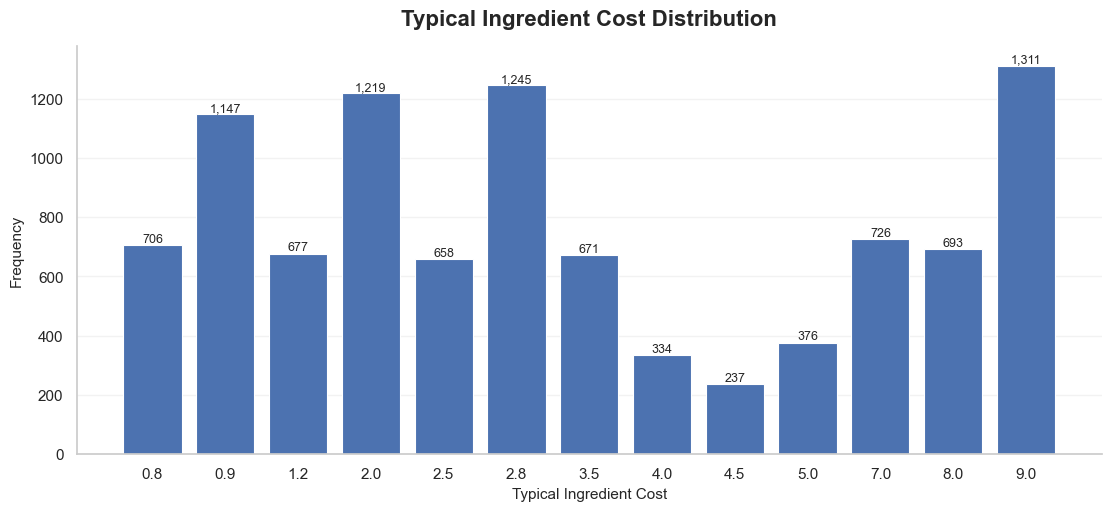

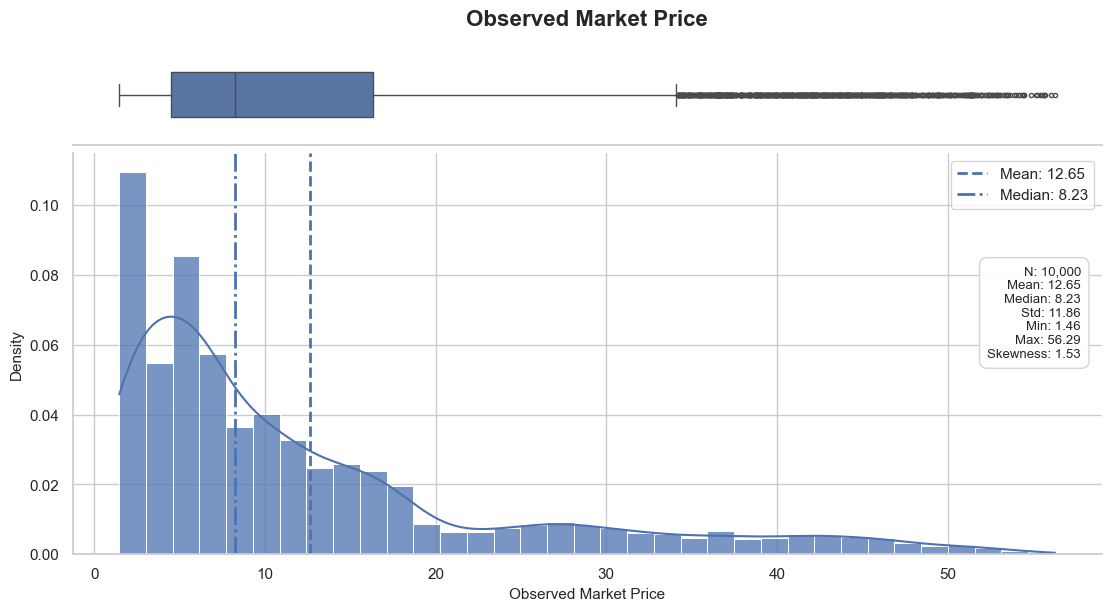

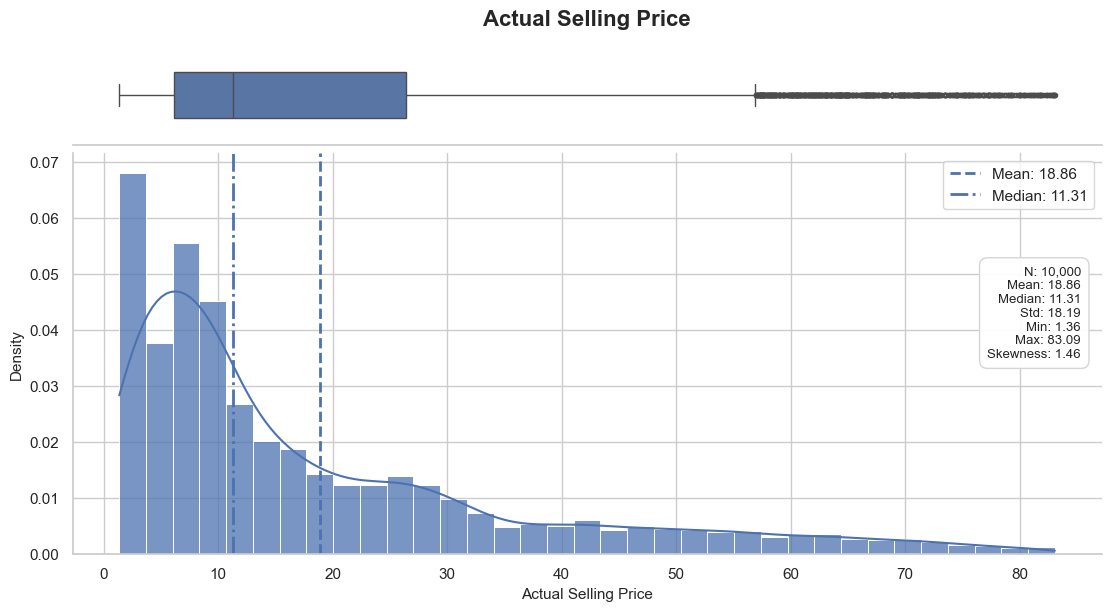

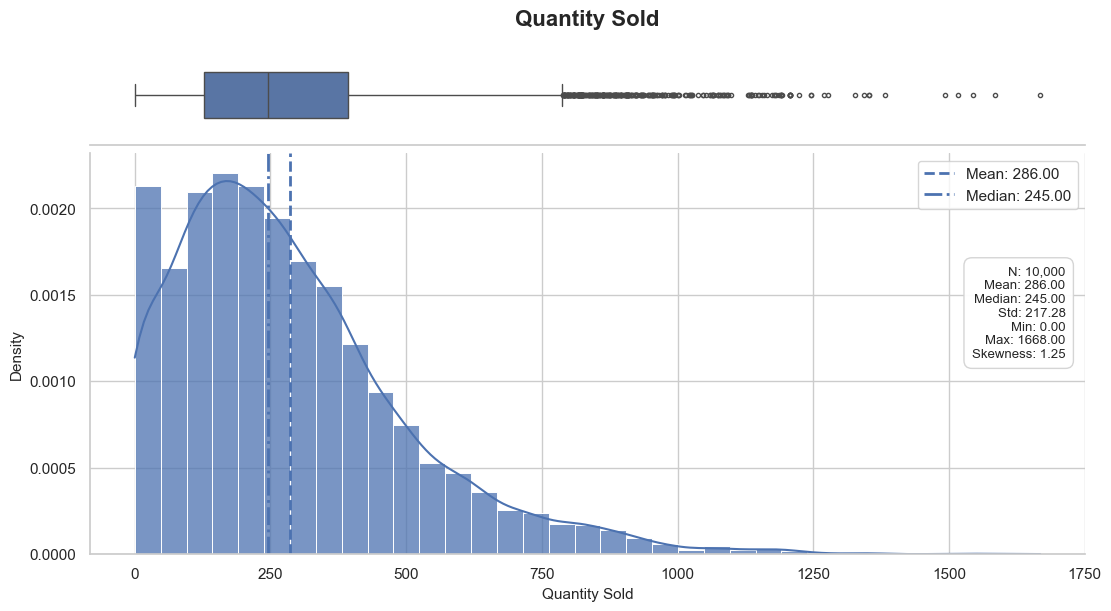

,count,mean,median,std,min,max,skew
typical_ingredient_cost,10000.0,3.90,2.80,2.87,0.80,9.00,0.70
observed_market_price,10000.0,12.65,8.23,11.86,1.46,56.29,1.53
actual_selling_price,10000.0,18.86,11.31,18.19,1.36,83.09,1.46
quantity_sold,10000.0,286.00,245.00,217.28,0.00,1668.00,1.25


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ---------------------------------------------------------
# GRAFİK AYARLARI
# ---------------------------------------------------------

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# Grafiklerde kullanılacak değişken başlıkları
column_titles = {
    "typical_ingredient_cost": "Typical Ingredient Cost",
    "observed_market_price": "Observed Market Price",
    "actual_selling_price": "Actual Selling Price",
    "quantity_sold": "Quantity Sold"
}


# ---------------------------------------------------------
# 1. TYPICAL INGREDIENT COST
# Ayrık değerlerden oluştuğu için KDE yerine frekans grafiği
# ---------------------------------------------------------

ingredient_cost_counts = (
    sales_data["typical_ingredient_cost"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(
    figsize=(11, 5),
    constrained_layout=True
)

bars = ax.bar(
    ingredient_cost_counts.index.astype(str),
    ingredient_cost_counts.values,
    edgecolor="white",
    linewidth=0.8
)

ax.set_title(
    "Typical Ingredient Cost Distribution",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Typical Ingredient Cost",
    fontsize=11
)

ax.set_ylabel(
    "Frequency",
    fontsize=11
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

# Sütunların üzerine frekans değerlerini yazdırma
for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

sns.despine(
    ax=ax
)

plt.show()


# ---------------------------------------------------------
# 2. DİĞER SAYISAL DEĞİŞKENLER
# Üstte boxplot, altta histogram + KDE
# ---------------------------------------------------------

continuous_columns = [
    "observed_market_price",
    "actual_selling_price",
    "quantity_sold"
]

for column in continuous_columns:

    data = sales_data[column].dropna()

    # Temel istatistikler
    mean_value = data.mean()
    median_value = data.median()
    std_value = data.std()
    minimum_value = data.min()
    maximum_value = data.max()
    skewness_value = data.skew()

    # Grafik
    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(11, 6),
        sharex=True,
        constrained_layout=True,
        gridspec_kw={
            "height_ratios": [1, 4]
        }
    )

    # -----------------------------------------------------
    # ÜST PANEL: BOXPLOT
    # -----------------------------------------------------

    sns.boxplot(
        x=data,
        ax=axes[0],
        width=0.45,
        showfliers=True,
        fliersize=3
    )

    axes[0].set_title(
        column_titles[column],
        fontsize=16,
        fontweight="bold",
        pad=14
    )

    axes[0].set_xlabel("")
    axes[0].set_ylabel("")
    axes[0].grid(False)

    sns.despine(
        ax=axes[0],
        left=True
    )

    # -----------------------------------------------------
    # ALT PANEL: HISTOGRAM + KDE
    # -----------------------------------------------------

    sns.histplot(
        data=data,
        bins=35,
        kde=True,
        stat="density",
        edgecolor="white",
        linewidth=0.7,
        alpha=0.75,
        ax=axes[1]
    )

    # Ortalama çizgisi
    axes[1].axvline(
        mean_value,
        linestyle="--",
        linewidth=2,
        label=f"Mean: {mean_value:.2f}"
    )

    # Medyan çizgisi
    axes[1].axvline(
        median_value,
        linestyle="-.",
        linewidth=2,
        label=f"Median: {median_value:.2f}"
    )

    axes[1].set_xlabel(
        column_titles[column],
        fontsize=11
    )

    axes[1].set_ylabel(
        "Density",
        fontsize=11
    )

    axes[1].legend(
        loc="upper right",
        frameon=True
    )

    # İstatistik kutusu
    statistics_text = (
        f"N: {data.shape[0]:,}\n"
        f"Mean: {mean_value:.2f}\n"
        f"Median: {median_value:.2f}\n"
        f"Std: {std_value:.2f}\n"
        f"Min: {minimum_value:.2f}\n"
        f"Max: {maximum_value:.2f}\n"
        f"Skewness: {skewness_value:.2f}"
    )

    axes[1].text(
        0.98,
        0.72,
        statistics_text,
        transform=axes[1].transAxes,
        ha="right",
        va="top",
        fontsize=9.5,
        bbox={
            "boxstyle": "round,pad=0.6",
            "facecolor": "white",
            "edgecolor": "lightgray",
            "alpha": 0.95
        }
    )

    sns.despine(
        ax=axes[1]
    )

    plt.show()


# ---------------------------------------------------------
# 3. SAYISAL DEĞİŞKENLER İÇİN ÖZET TABLO
# ---------------------------------------------------------

numeric_columns = [
    "typical_ingredient_cost",
    "observed_market_price",
    "actual_selling_price",
    "quantity_sold"
]

numeric_summary = (
    sales_data[numeric_columns]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max",
        "skew"
    ])
    .T
    .round(2)
)

numeric_summary

*Bulgular*: Sayısal değişkenler incelendiğinde observed market price, actual selling price ve quantity sold değişkenlerinin pozitif çarpıklık gösterdiği görülmektedir. Bu değişkenlerde ortalama değerlerin medyanlardan yüksek olması, dağılımların sağ kuyruğa sahip olduğunu desteklemektedir. Boxplotlarda çok sayıda yüksek değer görülmesine rağmen bu gözlemler doğrudan veri hatası olarak değerlendirilmemiştir. Farklı restoran türleri ve menü ürünleri arasında doğal fiyat ve satış hacmi farklılıkları bulunabileceğinden, aykırı görünen değerler sonraki aşamada grup bazında incelenecektir.

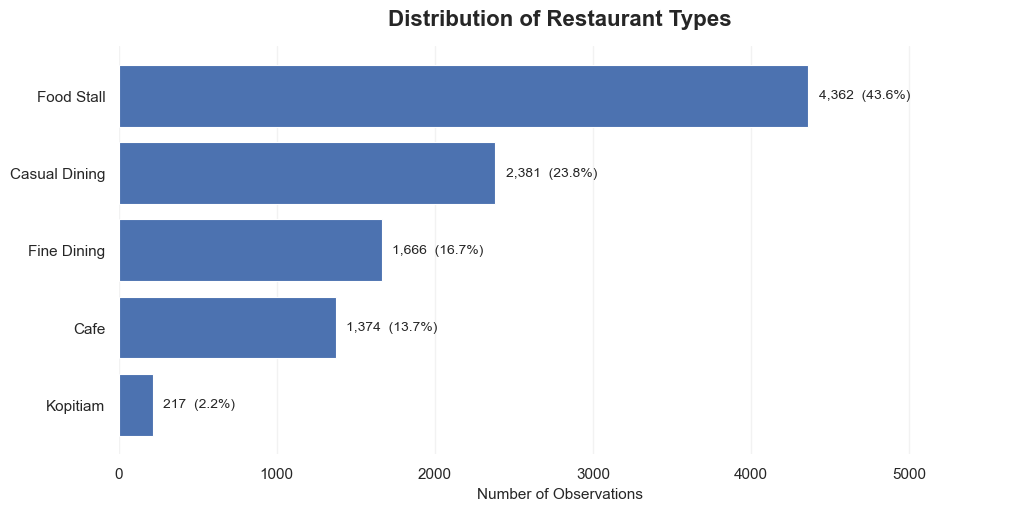

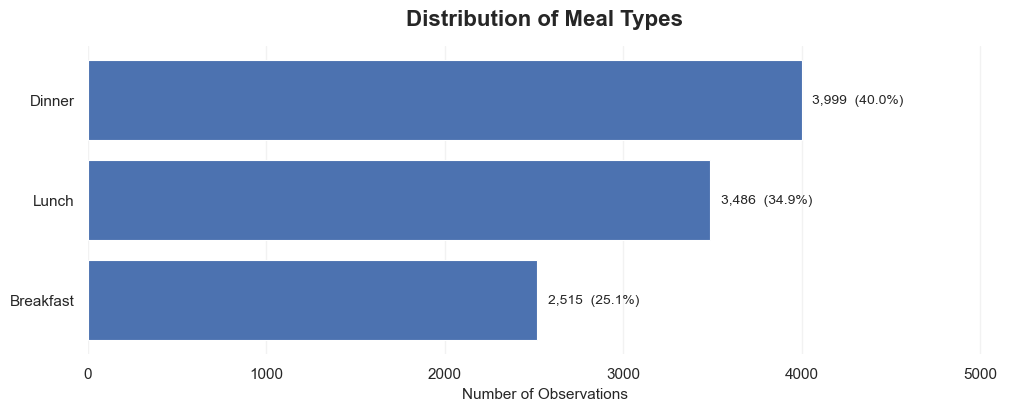

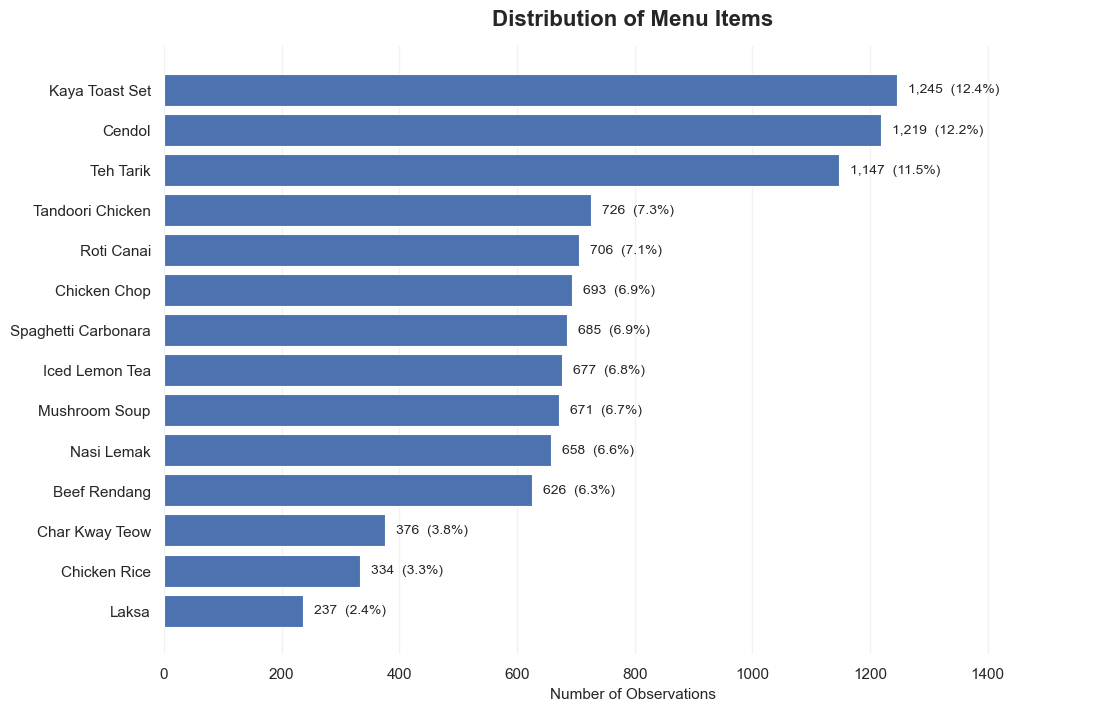

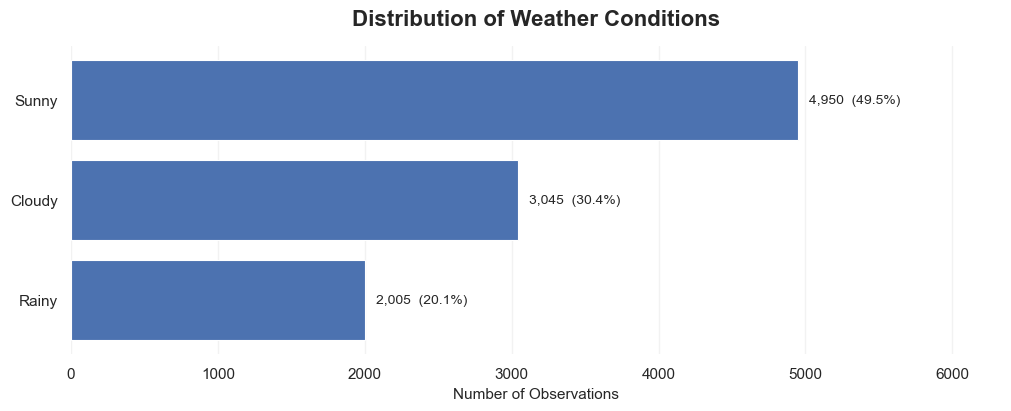

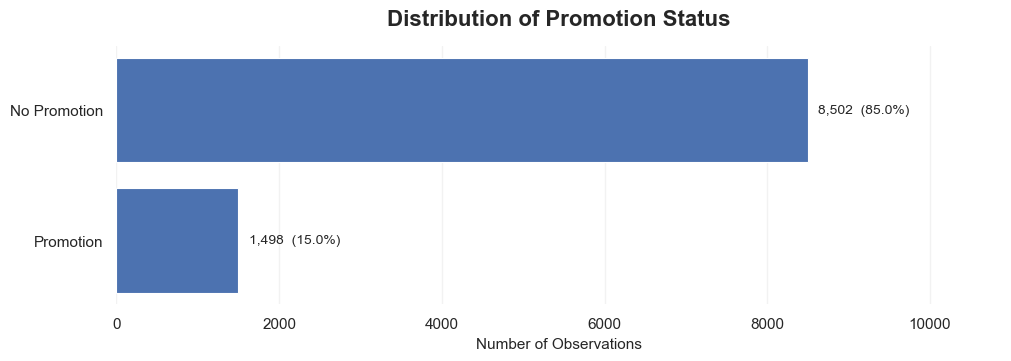

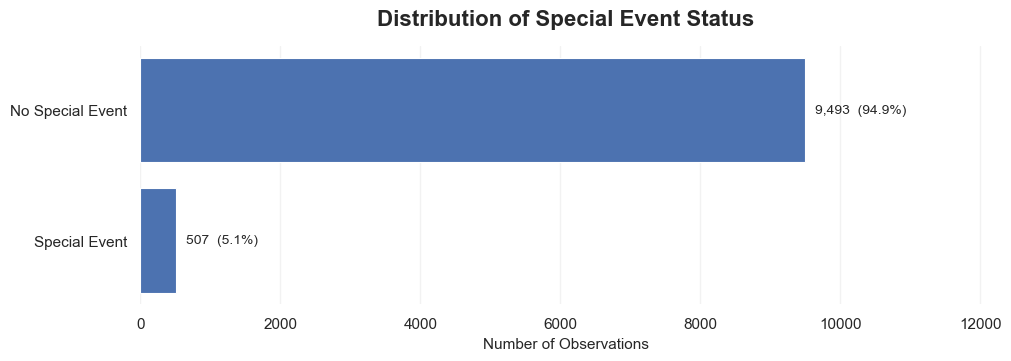

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# ---------------------------------------------------------
# KATEGORİK DEĞİŞKENLER İÇİN GRAFİK FONKSİYONU
# ---------------------------------------------------------

def plot_categorical_distribution(
    data,
    column,
    title,
    label_mapping=None,
    figsize=(10, 5)
):
    """
    Kategorik bir değişkenin frekans ve yüzde dağılımını
    yatay bar grafik ile gösterir.
    """

    counts = data[column].value_counts(dropna=False)

    plot_data = (
        counts
        .rename_axis("category")
        .reset_index(name="count")
    )

    plot_data["percentage"] = (
        plot_data["count"] / plot_data["count"].sum() * 100
    )

    # True / False gibi değerleri daha okunabilir etiketlere dönüştürme
    if label_mapping is not None:
        plot_data["category"] = (
            plot_data["category"]
            .map(label_mapping)
            .fillna(plot_data["category"].astype(str))
        )
    else:
        plot_data["category"] = plot_data["category"].astype(str)

    # En düşük kategori altta, en yüksek kategori üstte görünsün
    plot_data = plot_data.sort_values(
        by="count",
        ascending=True
    )

    fig, ax = plt.subplots(
        figsize=figsize,
        constrained_layout=True
    )

    bars = ax.barh(
        plot_data["category"],
        plot_data["count"],
        edgecolor="white",
        linewidth=0.8
    )

    ax.set_title(
        title,
        fontsize=16,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel(
        "Number of Observations",
        fontsize=11
    )

    ax.set_ylabel("")

    ax.grid(
        axis="x",
        alpha=0.25
    )

    ax.grid(
        axis="y",
        visible=False
    )

    # Barların sonuna sayı ve yüzde yazdırma
    maximum_count = plot_data["count"].max()

    for bar, count, percentage in zip(
        bars,
        plot_data["count"],
        plot_data["percentage"]
    ):
        ax.text(
            bar.get_width() + maximum_count * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"{count:,}  ({percentage:.1f}%)",
            va="center",
            ha="left",
            fontsize=10
        )

    # Etiketler için sağ tarafta boşluk bırakma
    ax.set_xlim(
        0,
        maximum_count * 1.28
    )

    sns.despine(
        ax=ax,
        left=True,
        bottom=True
    )

    plt.show()


# ---------------------------------------------------------
# 1. RESTAURANT TYPE
# ---------------------------------------------------------

plot_categorical_distribution(
    data=sales_data,
    column="restaurant_type",
    title="Distribution of Restaurant Types",
    figsize=(10, 5)
)


# ---------------------------------------------------------
# 2. MEAL TYPE
# ---------------------------------------------------------

plot_categorical_distribution(
    data=sales_data,
    column="meal_type",
    title="Distribution of Meal Types",
    figsize=(10, 4)
)


# ---------------------------------------------------------
# 3. MENU ITEMS
# ---------------------------------------------------------

plot_categorical_distribution(
    data=sales_data,
    column="menu_item_name",
    title="Distribution of Menu Items",
    figsize=(11, 7)
)


# ---------------------------------------------------------
# 4. WEATHER CONDITION
# ---------------------------------------------------------

plot_categorical_distribution(
    data=sales_data,
    column="weather_condition",
    title="Distribution of Weather Conditions",
    figsize=(10, 4)
)


# ---------------------------------------------------------
# 5. PROMOTION STATUS
# ---------------------------------------------------------

plot_categorical_distribution(
    data=sales_data,
    column="has_promotion",
    title="Distribution of Promotion Status",
    label_mapping={
        True: "Promotion",
        False: "No Promotion"
    },
    figsize=(10, 3.5)
)


# ---------------------------------------------------------
# 6. SPECIAL EVENT STATUS
# ---------------------------------------------------------

plot_categorical_distribution(
    data=sales_data,
    column="special_event",
    title="Distribution of Special Event Status",
    label_mapping={
        True: "Special Event",
        False: "No Special Event"
    },
    figsize=(10, 3.5)
)

## 4. Kârlılık Değişkenlerinin Oluşturulması

Veri setinde doğrudan gelir, toplam maliyet veya kâr değişkenleri bulunmamaktadır. Bu nedenle Kâr/Fiyat Agentı'nda kullanılmak üzere mevcut fiyat, birim malzeme maliyeti ve satış miktarı değişkenlerinden yeni finansal göstergeler oluşturulmuştur.

Bu çalışmada kullanılan maliyet yalnızca `typical_ingredient_cost` değişkeninde yer alan tahmini malzeme maliyetini kapsamaktadır. Personel, kira, enerji ve operasyon giderleri veri setinde bulunmadığından hesaplanan kâr değeri gerçek net kârı değil, tahmini brüt ürün kârını temsil etmektedir.

In [32]:
# ---------------------------------------------------------
# 4. FEATURE ENGINEERING
# KÂRLILIK DEĞİŞKENLERİNİN OLUŞTURULMASI
# ---------------------------------------------------------

# Tarih değişkenini tarih formatına dönüştürme
sales_data["date"] = pd.to_datetime(
    sales_data["date"],
    errors="coerce"
)

# Birim başına tahmini kâr
sales_data["unit_profit"] = (
    sales_data["actual_selling_price"]
    - sales_data["typical_ingredient_cost"]
)

# Birim kâr marjı
sales_data["unit_profit_margin"] = (
    sales_data["unit_profit"]
    / sales_data["actual_selling_price"]
)

# Toplam satış geliri
sales_data["revenue"] = (
    sales_data["actual_selling_price"]
    * sales_data["quantity_sold"]
)

# Satılan ürünler için tahmini toplam malzeme maliyeti
sales_data["estimated_total_cost"] = (
    sales_data["typical_ingredient_cost"]
    * sales_data["quantity_sold"]
)

# Tahmini brüt kâr
sales_data["estimated_profit"] = (
    sales_data["revenue"]
    - sales_data["estimated_total_cost"]
)

# Piyasa fiyatına göre fiyat farkı
sales_data["price_difference"] = (
    sales_data["actual_selling_price"]
    - sales_data["observed_market_price"]
)

# Satış fiyatının piyasa fiyatına göre yüzde farkı
sales_data["price_difference_pct"] = (
    sales_data["price_difference"]
    / sales_data["observed_market_price"]
    * 100
)

# Piyasa fiyatına göre fiyatlandırma konumu
sales_data["price_position"] = np.select(
    [
        sales_data["price_difference_pct"] < -5,
        sales_data["price_difference_pct"].between(-5, 5, inclusive="both"),
        sales_data["price_difference_pct"] > 5
    ],
    [
        "Piyasanın Altında",
        "Piyasaya Yakın",
        "Piyasanın Üzerinde"
    ],
    default="Bilinmiyor"
)

# Oluşturulan değişkenlerin ilk gözlemleri
profit_columns = [
    "date",
    "restaurant_id",
    "menu_item_name",
    "actual_selling_price",
    "typical_ingredient_cost",
    "quantity_sold",
    "unit_profit",
    "unit_profit_margin",
    "revenue",
    "estimated_total_cost",
    "estimated_profit",
    "price_difference",
    "price_difference_pct",
    "price_position"
]

sales_data[profit_columns].head()

,date,restaurant_id,menu_item_name,actual_selling_price,typical_ingredient_cost,quantity_sold,unit_profit,unit_profit_margin,revenue,estimated_total_cost,estimated_profit,price_difference,price_difference_pct,price_position
0,2024-01-01,11,Laksa,12.48,4.5,361,7.98,0.639423,4505.28,1624.5,2880.78,1.89,17.847025,Piyasanın Üzerinde
1,2024-01-01,7,Spaghetti Carbonara,60.46,9.0,105,51.46,0.851141,6348.30,945.0,5403.30,33.82,126.951952,Piyasanın Üzerinde
2,2024-01-01,23,Beef Rendang,80.15,9.0,36,71.15,0.887711,2885.40,324.0,2561.40,30.73,62.181303,Piyasanın Üzerinde
3,2024-01-01,22,Roti Canai,2.48,0.8,503,1.68,0.677419,1247.44,402.4,845.04,0.44,21.568627,Piyasanın Üzerinde
4,2024-01-01,32,Spaghetti Carbonara,55.54,9.0,262,46.54,0.837955,14551.48,2358.0,12193.48,15.24,37.816377,Piyasanın Üzerinde


In [34]:
# ---------------------------------------------------------
# 4.1 YENİ DEĞİŞKENLERİN KALİTE VE MANTIK KONTROLÜ
# ---------------------------------------------------------

new_numeric_columns = [
    "unit_profit",
    "unit_profit_margin",
    "revenue",
    "estimated_total_cost",
    "estimated_profit",
    "price_difference",
    "price_difference_pct"
]

# Eksik değer kontrolü
missing_check = (
    sales_data[new_numeric_columns]
    .isna()
    .sum()
    .to_frame(name="missing_count")
)

missing_check

,missing_count
unit_profit,0
unit_profit_margin,0
revenue,0
estimated_total_cost,0
estimated_profit,0
price_difference,0
price_difference_pct,0


In [36]:
# Sonsuz değer kontrolü
infinite_check = pd.DataFrame({
    "variable": new_numeric_columns,
    "infinite_count": [
        np.isinf(sales_data[column]).sum()
        for column in new_numeric_columns
    ]
})

infinite_check

,variable,infinite_count
0,unit_profit,0
1,unit_profit_margin,0
2,revenue,0
3,estimated_total_cost,0
4,estimated_profit,0
5,price_difference,0
6,price_difference_pct,0


In [38]:
# ---------------------------------------------------------
# MANTIK KONTROLLERİ
# ---------------------------------------------------------

print(
    "Negatif birim kâr bulunan kayıt sayısı:",
    (sales_data["unit_profit"] < 0).sum()
)

print(
    "Sıfır birim kâr bulunan kayıt sayısı:",
    (sales_data["unit_profit"] == 0).sum()
)

print(
    "Negatif tahmini kâr bulunan kayıt sayısı:",
    (sales_data["estimated_profit"] < 0).sum()
)

print(
    "Sıfır tahmini kâr bulunan kayıt sayısı:",
    (sales_data["estimated_profit"] == 0).sum()
)

print(
    "Negatif gelir bulunan kayıt sayısı:",
    (sales_data["revenue"] < 0).sum()
)

print(
    "Sıfır gelir bulunan kayıt sayısı:",
    (sales_data["revenue"] == 0).sum()
)

print(
    "Sıfır satış bulunan kayıt sayısı:",
    (sales_data["quantity_sold"] == 0).sum()
)

print(
    "Satış fiyatı malzeme maliyetinden düşük kayıt sayısı:",
    (
        sales_data["actual_selling_price"]
        < sales_data["typical_ingredient_cost"]
    ).sum()
)

Negatif birim kâr bulunan kayıt sayısı: 0
Sıfır birim kâr bulunan kayıt sayısı: 0
Negatif tahmini kâr bulunan kayıt sayısı: 0
Sıfır tahmini kâr bulunan kayıt sayısı: 502
Negatif gelir bulunan kayıt sayısı: 0
Sıfır gelir bulunan kayıt sayısı: 502
Sıfır satış bulunan kayıt sayısı: 502
Satış fiyatı malzeme maliyetinden düşük kayıt sayısı: 0


In [40]:
# ---------------------------------------------------------
# 4.2 KÂRLILIK DEĞİŞKENLERİ ÖZET İSTATİSTİKLERİ
# ---------------------------------------------------------

profit_summary = (
    sales_data[
        [
            "unit_profit",
            "unit_profit_margin",
            "revenue",
            "estimated_total_cost",
            "estimated_profit",
            "price_difference",
            "price_difference_pct"
        ]
    ]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max",
        "skew"
    ])
    .T
    .round(2)
)

profit_summary

,count,mean,median,std,min,max,skew
unit_profit,10000.0,14.96,8.51,15.67,0.56,74.09,1.65
unit_profit_margin,10000.0,0.75,0.75,0.08,0.40,0.89,-0.66
revenue,10000.0,3271.34,2497.43,2861.75,0.00,26822.28,1.92
estimated_total_cost,10000.0,782.87,616.50,621.54,0.00,4860.00,1.38
estimated_profit,10000.0,2488.47,1824.00,2348.59,0.00,22838.28,2.17
price_difference,10000.0,6.21,3.13,7.90,-15.59,46.95,1.78
price_difference_pct,10000.0,46.72,44.72,34.22,-44.85,175.83,0.32


In [42]:
# Kâr marjını yüzdeye dönüştürme
sales_data["unit_profit_margin_pct"] = (
    sales_data["unit_profit_margin"] * 100
)

margin_summary = (
    sales_data["unit_profit_margin_pct"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max",
        "skew"
    ])
    .round(2)
)

margin_summary

count     10000.00
mean         74.51
median       75.09
std           8.48
min          40.17
max          89.20
skew         -0.66
Name: unit_profit_margin_pct, dtype: float64

In [44]:
# ---------------------------------------------------------
# 4.3 FİYAT KONUMLARININ DAĞILIMI
# ---------------------------------------------------------

price_position_summary = (
    sales_data["price_position"]
    .value_counts()
    .rename_axis("price_position")
    .reset_index(name="count")
)

price_position_summary["percentage"] = (
    price_position_summary["count"]
    / len(sales_data)
    * 100
).round(2)

price_position_summary

,price_position,count,percentage
0,Piyasanın Üzerinde,8932,89.32
1,Piyasanın Altında,587,5.87
2,Piyasaya Yakın,481,4.81


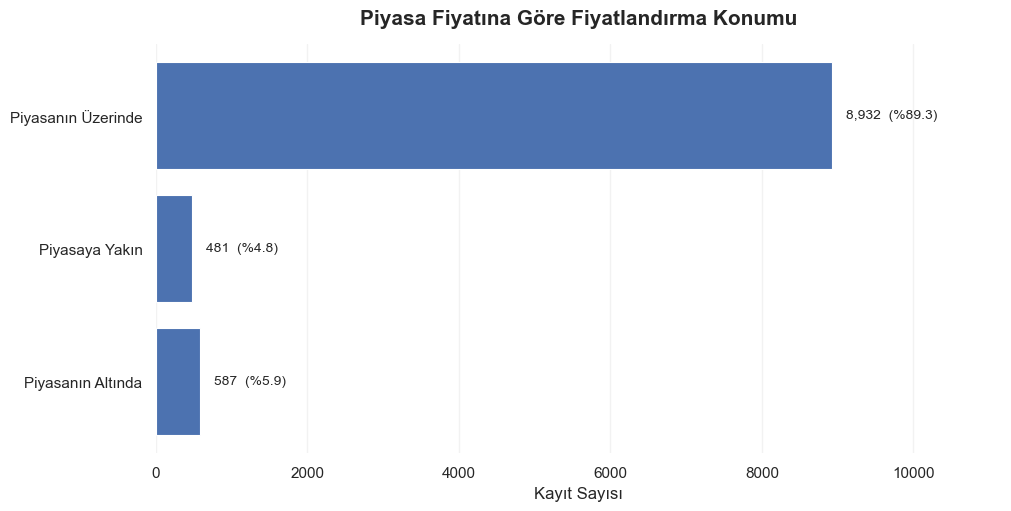

In [46]:
price_order = [
    "Piyasanın Altında",
    "Piyasaya Yakın",
    "Piyasanın Üzerinde"
]

price_plot_data = (
    sales_data["price_position"]
    .value_counts()
    .reindex(price_order)
    .fillna(0)
    .reset_index()
)

price_plot_data.columns = [
    "price_position",
    "count"
]

price_plot_data["percentage"] = (
    price_plot_data["count"]
    / price_plot_data["count"].sum()
    * 100
)

fig, ax = plt.subplots(
    figsize=(10, 5),
    constrained_layout=True
)

bars = ax.barh(
    price_plot_data["price_position"],
    price_plot_data["count"],
    edgecolor="white",
    linewidth=0.8
)

maximum_count = price_plot_data["count"].max()

for bar, count, percentage in zip(
    bars,
    price_plot_data["count"],
    price_plot_data["percentage"]
):
    ax.text(
        bar.get_width() + maximum_count * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count):,}  (%{percentage:.1f})",
        va="center",
        ha="left",
        fontsize=10
    )

ax.set_title(
    "Piyasa Fiyatına Göre Fiyatlandırma Konumu",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Kayıt Sayısı")
ax.set_ylabel("")
ax.set_xlim(0, maximum_count * 1.25)

ax.grid(
    axis="x",
    alpha=0.25
)

ax.grid(
    axis="y",
    visible=False
)

sns.despine(
    ax=ax,
    left=True,
    bottom=True
)

plt.show()

### Bulgular

Oluşturulan kârlılık değişkenlerinde eksik veya sonsuz değer bulunmamaktadır. Satış fiyatının malzeme maliyetinden düşük olduğu herhangi bir kayıt olmadığı için negatif birim kâr veya negatif tahmini kâr gözlenmemiştir.

Toplam 502 kayıtta satış miktarı sıfırdır. Bu kayıtlarda gelir ve tahmini kârın sıfır olması hesaplama hatasından değil, satış gerçekleşmemesinden kaynaklanmaktadır. Bu gözlemler kârlılık açısından doğrudan zarar olarak değerlendirilmemeli; satış fırsatının oluşmadığı kayıtlar olarak ele alınmalıdır.

Ortalama birim kâr 14,96, ortalama tahmini brüt kâr 2.488,47 ve ortalama birim kâr marjı yaklaşık %74,51 olarak hesaplanmıştır. Ancak hesaplanan kâr yalnızca ürünün malzeme maliyetini dikkate almakta; personel, kira, enerji ve diğer operasyonel giderleri kapsamamaktadır.

Fiyatlandırma konumu incelendiğinde kayıtların %89,32’sinin gözlenen piyasa fiyatının üzerinde olduğu görülmektedir. Bu belirgin fark nedeniyle `observed_market_price` ve `actual_selling_price` değişkenlerinin aynı ürün, porsiyon ve hizmet seviyesini temsil edip etmediği dikkatle değerlendirilmelidir. Bu sınıflandırma ilerleyen analizlerde fiyat konumu göstergesi olarak kullanılacak, ancak tek başına hatalı fiyatlandırma kanıtı olarak yorumlanmayacaktır.

In [49]:
# ---------------------------------------------------------
# 5. ÜRÜN BAZINDA KÂRLILIK ANALİZİ
# ---------------------------------------------------------

product_performance = (
    sales_data
    .groupby("menu_item_name", as_index=False)
    .agg(
        observation_count=("menu_item_name", "size"),
        total_quantity_sold=("quantity_sold", "sum"),
        average_selling_price=("actual_selling_price", "mean"),
        average_ingredient_cost=("typical_ingredient_cost", "mean"),
        average_unit_profit=("unit_profit", "mean"),
        total_revenue=("revenue", "sum"),
        total_estimated_cost=("estimated_total_cost", "sum"),
        total_estimated_profit=("estimated_profit", "sum")
    )
)

# Gelir ağırlıklı kâr marjı
product_performance["weighted_profit_margin_pct"] = (
    product_performance["total_estimated_profit"]
    / product_performance["total_revenue"]
    * 100
)

# Tabloyu toplam tahmini kâra göre sıralama
product_performance = (
    product_performance
    .sort_values(
        "total_estimated_profit",
        ascending=False
    )
    .reset_index(drop=True)
)

# Sayısal değerleri yuvarlama
product_performance = product_performance.round({
    "average_selling_price": 2,
    "average_ingredient_cost": 2,
    "average_unit_profit": 2,
    "total_revenue": 2,
    "total_estimated_cost": 2,
    "total_estimated_profit": 2,
    "weighted_profit_margin_pct": 2
})

product_performance

,menu_item_name,observation_count,total_quantity_sold,average_selling_price,average_ingredient_cost,average_unit_profit,total_revenue,total_estimated_cost,total_estimated_profit,weighted_profit_margin_pct
0,Chicken Chop,693,109641,47.26,8.0,39.26,4762333.00,877128.0,3885205.00,81.58
1,Kaya Toast Set,1245,544101,10.07,2.8,7.27,5240719.63,1523482.8,3717236.83,70.93
2,Spaghetti Carbonara,685,93114,53.48,9.0,44.48,4511648.25,838026.0,3673622.25,81.43
3,Beef Rendang,626,66038,48.14,9.0,39.14,2919472.66,594342.0,2325130.66,79.64
4,Nasi Lemak,658,226795,11.22,2.5,8.72,2423090.12,566987.5,1856102.62,76.60
5,Cendol,1219,304622,7.86,2.0,5.86,2213847.11,609244.0,1604603.11,72.48
6,Tandoori Chicken,726,91048,25.53,7.0,18.53,2139956.04,637336.0,1502620.04,70.22
7,Teh Tarik,1147,643076,3.16,0.9,2.26,1954969.69,578768.4,1376201.29,70.40
8,Mushroom Soup,671,70164,21.46,3.5,17.96,1392304.64,245574.0,1146730.64,82.36
9,Iced Lemon Tea,677,235325,6.28,1.2,5.08,1400942.30,282390.0,1118552.30,79.84


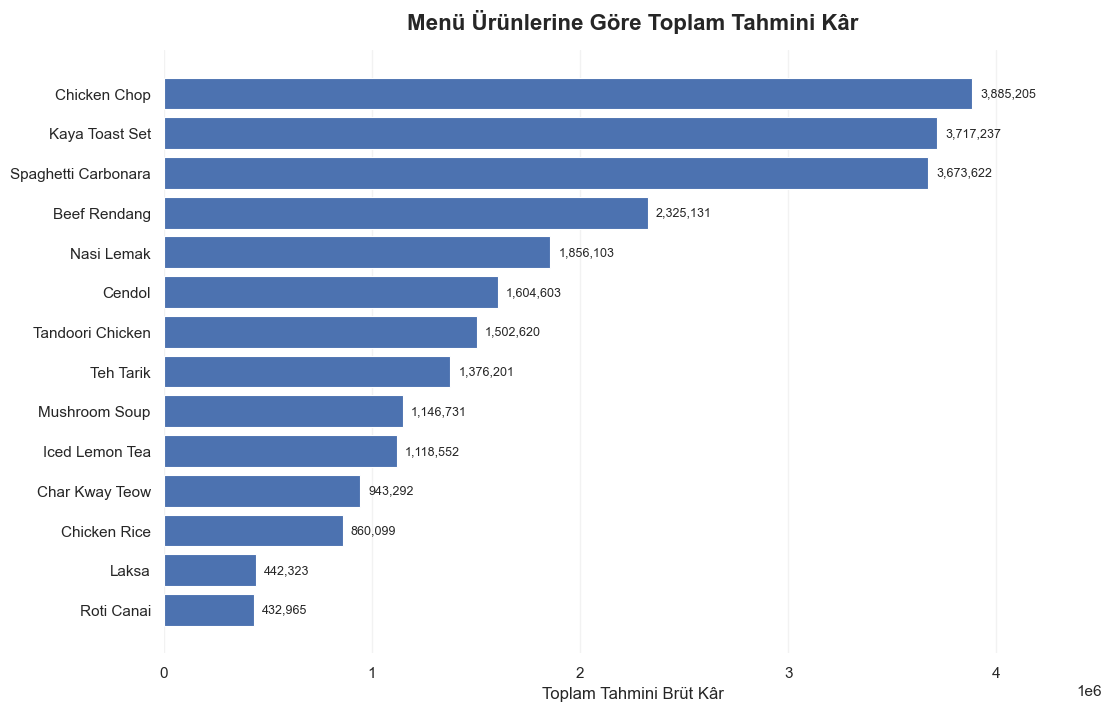

In [51]:
# ---------------------------------------------------------
# TOPLAM TAHMİNİ KÂRA GÖRE ÜRÜNLER
# ---------------------------------------------------------

profit_plot_data = (
    product_performance
    .sort_values(
        "total_estimated_profit",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(11, 7),
    constrained_layout=True
)

bars = ax.barh(
    profit_plot_data["menu_item_name"],
    profit_plot_data["total_estimated_profit"],
    edgecolor="white",
    linewidth=0.8
)

maximum_profit = profit_plot_data["total_estimated_profit"].max()

for bar, value in zip(
    bars,
    profit_plot_data["total_estimated_profit"]
):
    ax.text(
        bar.get_width() + maximum_profit * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        ha="left",
        fontsize=9
    )

ax.set_title(
    "Menü Ürünlerine Göre Toplam Tahmini Kâr",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Toplam Tahmini Brüt Kâr")
ax.set_ylabel("")
ax.set_xlim(0, maximum_profit * 1.16)

ax.grid(
    axis="x",
    alpha=0.25
)

ax.grid(
    axis="y",
    visible=False
)

sns.despine(
    ax=ax,
    left=True,
    bottom=True
)

plt.show()

### Ürün Bazında Toplam Tahmini Kâr Bulguları

Ürünlerin toplam tahmini brüt kârları karşılaştırıldığında Chicken Chop en yüksek toplam kârı sağlayan ürün olarak öne çıkmaktadır. Kaya Toast Set ve Spaghetti Carbonara da toplam kârlılık açısından üst sıralarda yer almaktadır.

Kaya Toast Set'in ortalama birim kârı yüksek fiyatlı ürünlere kıyasla daha düşük olmasına rağmen, yüksek satış hacmi sayesinde toplam tahmini kârı oldukça yüksektir. Bu bulgu, toplam kârlılığın yalnızca ürün başına kâr miktarına değil, aynı zamanda satış hacmine de bağlı olduğunu göstermektedir.

Laksa ve Roti Canai toplam tahmini kâr açısından alt sıralarda yer almaktadır. Bununla birlikte bu ürünlerin düşük toplam kârı doğrudan verimsiz oldukları anlamına gelmemektedir; ürünlerin gözlem sayısı, toplam satış hacmi, birim kârı ve kâr marjı birlikte değerlendirilmelidir.

Bu nedenle ürün performansını daha kapsamlı değerlendirebilmek için sonraki aşamada ağırlıklı kâr marjı, birim kâr ve toplam satış miktarı birlikte incelenecektir.

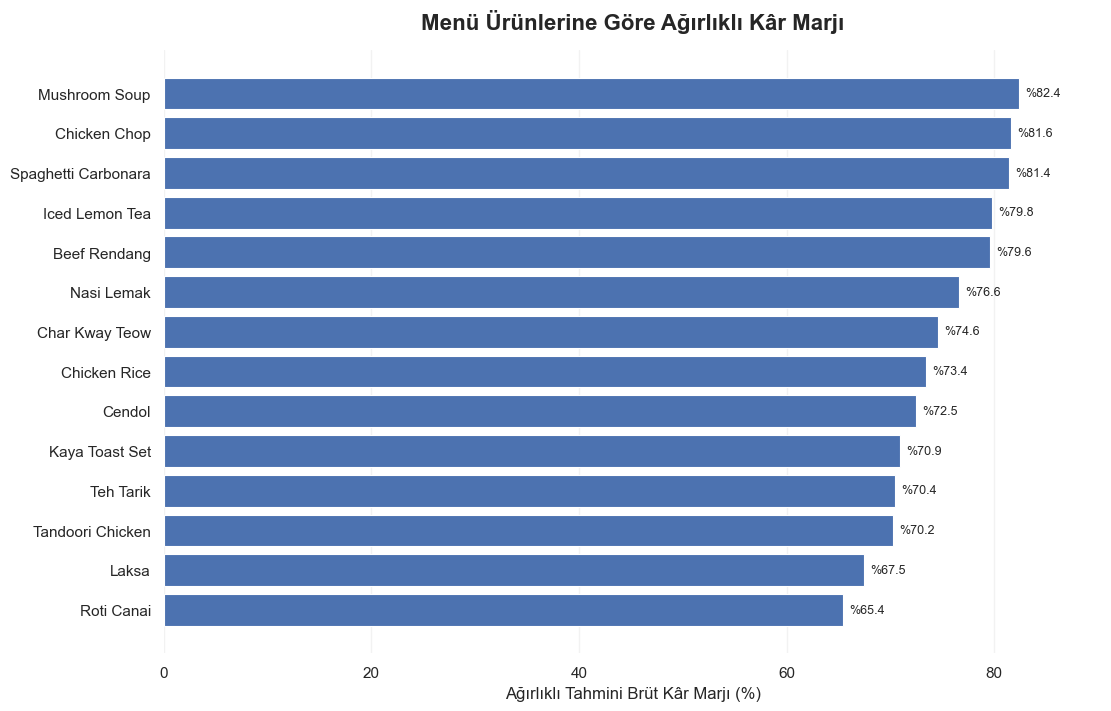

In [54]:
# ---------------------------------------------------------
# 5.1 ÜRÜNLERE GÖRE AĞIRLIKLI KÂR MARJI
# ---------------------------------------------------------

margin_plot_data = (
    product_performance
    .sort_values(
        "weighted_profit_margin_pct",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(11, 7),
    constrained_layout=True
)

bars = ax.barh(
    margin_plot_data["menu_item_name"],
    margin_plot_data["weighted_profit_margin_pct"],
    edgecolor="white",
    linewidth=0.8
)

maximum_margin = margin_plot_data[
    "weighted_profit_margin_pct"
].max()

for bar, value in zip(
    bars,
    margin_plot_data["weighted_profit_margin_pct"]
):
    ax.text(
        bar.get_width() + 0.6,
        bar.get_y() + bar.get_height() / 2,
        f"%{value:.1f}",
        va="center",
        ha="left",
        fontsize=9
    )

ax.set_title(
    "Menü Ürünlerine Göre Ağırlıklı Kâr Marjı",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Ağırlıklı Tahmini Brüt Kâr Marjı (%)")
ax.set_ylabel("")

ax.set_xlim(
    0,
    maximum_margin + 8
)

ax.grid(
    axis="x",
    alpha=0.25
)

ax.grid(
    axis="y",
    visible=False
)

sns.despine(
    ax=ax,
    left=True,
    bottom=True
)

plt.show()

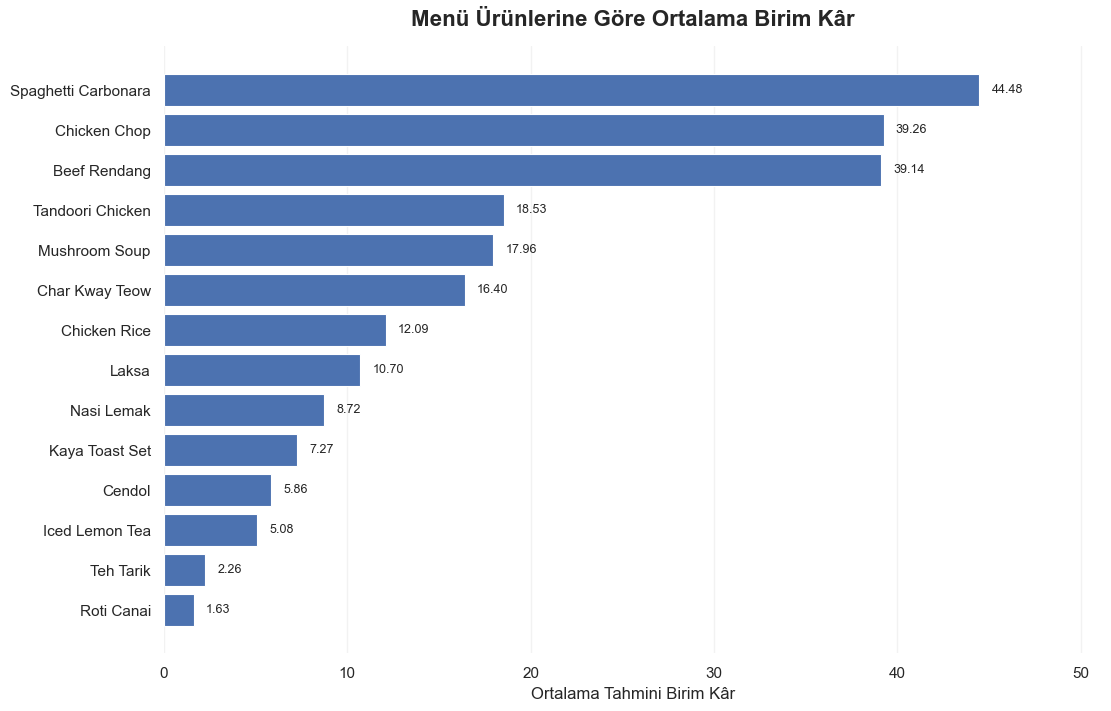

In [56]:
# ---------------------------------------------------------
# 5.2 ÜRÜNLERE GÖRE ORTALAMA BİRİM KÂR
# ---------------------------------------------------------

unit_profit_plot_data = (
    product_performance
    .sort_values(
        "average_unit_profit",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(11, 7),
    constrained_layout=True
)

bars = ax.barh(
    unit_profit_plot_data["menu_item_name"],
    unit_profit_plot_data["average_unit_profit"],
    edgecolor="white",
    linewidth=0.8
)

maximum_unit_profit = unit_profit_plot_data[
    "average_unit_profit"
].max()

for bar, value in zip(
    bars,
    unit_profit_plot_data["average_unit_profit"]
):
    ax.text(
        bar.get_width() + maximum_unit_profit * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        ha="left",
        fontsize=9
    )

ax.set_title(
    "Menü Ürünlerine Göre Ortalama Birim Kâr",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Ortalama Tahmini Birim Kâr")
ax.set_ylabel("")

ax.set_xlim(
    0,
    maximum_unit_profit * 1.15
)

ax.grid(
    axis="x",
    alpha=0.25
)

ax.grid(
    axis="y",
    visible=False
)

sns.despine(
    ax=ax,
    left=True,
    bottom=True
)

plt.show()

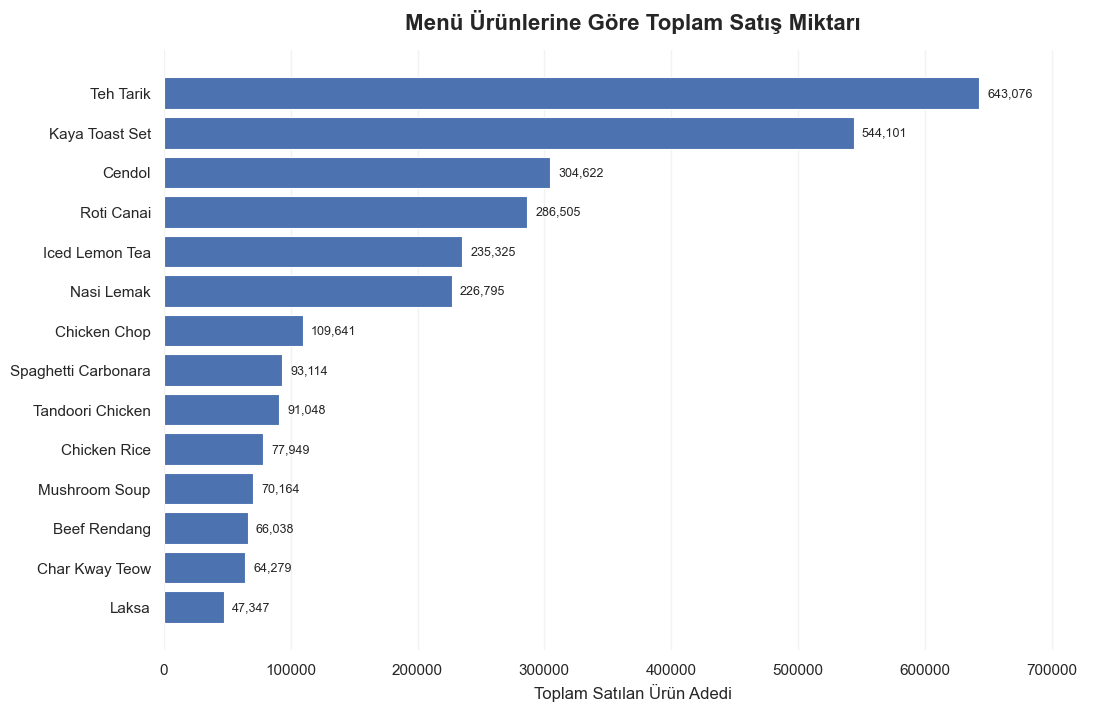

In [58]:
# ---------------------------------------------------------
# 5.3 ÜRÜNLERE GÖRE TOPLAM SATIŞ MİKTARI
# ---------------------------------------------------------

quantity_plot_data = (
    product_performance
    .sort_values(
        "total_quantity_sold",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(11, 7),
    constrained_layout=True
)

bars = ax.barh(
    quantity_plot_data["menu_item_name"],
    quantity_plot_data["total_quantity_sold"],
    edgecolor="white",
    linewidth=0.8
)

maximum_quantity = quantity_plot_data[
    "total_quantity_sold"
].max()

for bar, value in zip(
    bars,
    quantity_plot_data["total_quantity_sold"]
):
    ax.text(
        bar.get_width() + maximum_quantity * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value):,}",
        va="center",
        ha="left",
        fontsize=9
    )

ax.set_title(
    "Menü Ürünlerine Göre Toplam Satış Miktarı",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Toplam Satılan Ürün Adedi")
ax.set_ylabel("")

ax.set_xlim(
    0,
    maximum_quantity * 1.15
)

ax.grid(
    axis="x",
    alpha=0.25
)

ax.grid(
    axis="y",
    visible=False
)

sns.despine(
    ax=ax,
    left=True,
    bottom=True
)

plt.show()

## Ürün Bazında Kârlılık Analizinin Değerlendirilmesi

Ürün performansı yalnızca toplam kâr üzerinden değerlendirildiğinde bazı önemli bilgiler gözden kaçabilmektedir. Bu nedenle ürünler dört farklı açıdan incelenmiştir:

- Toplam tahmini brüt kâr
- Ağırlıklı kâr marjı
- Ortalama birim kâr
- Toplam satış miktarı

Analiz sonuçları farklı ürünlerin farklı performans göstergelerinde öne çıktığını göstermektedir.

Chicken Chop toplam tahmini brüt kâr açısından ilk sırada yer alırken, Mushroom Soup en yüksek kâr marjına sahip ürün olarak dikkat çekmektedir. Spaghetti Carbonara ise ürün başına elde edilen ortalama kâr bakımından en yüksek değeri üretmektedir. Buna karşılık Teh Tarik toplam satış miktarında açık ara ilk sırada bulunmasına rağmen toplam kârlılık bakımından aynı seviyede değildir.

Bu durum satış hacmi ile kârlılığın her zaman birlikte artmadığını göstermektedir. Yüksek satış hacmine sahip ürünler düşük birim kâr nedeniyle beklenen toplam katkıyı sağlayamayabilirken, daha düşük hacimde satılan bazı ürünler yüksek marjları sayesinde işletmeye önemli katkı sağlayabilmektedir.

Bu nedenle geliştirilecek Kâr/Fiyat Agent'ının karar verirken yalnızca satış miktarını değil, fiyatlandırma, maliyet, kâr marjı ve toplam kâr göstergelerini birlikte değerlendirmesi gerekmektedir.

# 6. Restoran Bazında Kârlılık Analizi

Ürün bazındaki analizlerin ardından performans restoran düzeyinde incelenmektedir.

Bu aşamada her restoran için;

- Toplam satış miktarı
- Toplam gelir
- Toplam tahmini maliyet
- Toplam tahmini brüt kâr
- Ortalama satış fiyatı
- Ortalama birim kâr
- Ağırlıklı kâr marjı

hesaplanacaktır.

Bu analiz sayesinde yüksek satış hacmine rağmen düşük kârlılığa sahip restoranlar ile düşük satış hacmine rağmen yüksek kârlılık sağlayan restoranlar belirlenebilecektir.

In [62]:
# ==========================================================
# 6. RESTORAN BAZINDA KÂRLILIK ANALİZİ
# ==========================================================

restaurant_performance = (
    sales_data
    .groupby("restaurant_id", as_index=False)
    .agg(
        observation_count=("restaurant_id", "size"),
        total_quantity_sold=("quantity_sold", "sum"),
        average_selling_price=("actual_selling_price", "mean"),
        average_ingredient_cost=("typical_ingredient_cost", "mean"),
        average_unit_profit=("unit_profit", "mean"),
        total_revenue=("revenue", "sum"),
        total_estimated_cost=("estimated_total_cost", "sum"),
        total_estimated_profit=("estimated_profit", "sum")
    )
)

restaurant_performance["weighted_profit_margin_pct"] = (
    restaurant_performance["total_estimated_profit"]
    /
    restaurant_performance["total_revenue"]
    * 100
)

restaurant_performance = (
    restaurant_performance
    .sort_values(
        "total_estimated_profit",
        ascending=False
    )
)

restaurant_performance = restaurant_performance.round({
    "average_selling_price":2,
    "average_ingredient_cost":2,
    "average_unit_profit":2,
    "total_revenue":2,
    "total_estimated_cost":2,
    "total_estimated_profit":2,
    "weighted_profit_margin_pct":2
})

restaurant_performance

,restaurant_id,observation_count,total_quantity_sold,average_selling_price,average_ingredient_cost,average_unit_profit,total_revenue,total_estimated_cost,total_estimated_profit,weighted_profit_margin_pct
5,6,232,40927,38.93,5.52,33.41,1272423.99,199624.8,1072799.19,84.31
31,32,218,41676,40.37,5.74,34.63,1233256.13,194050.6,1039205.53,84.27
22,23,204,43411,38.09,5.41,32.68,1160177.41,183180.8,976996.61,84.21
27,28,223,45073,38.28,5.35,32.94,1135245.46,175232.7,960012.76,84.56
41,42,205,40239,39.69,5.60,34.09,1103468.65,170201.8,933266.85,84.58
24,25,212,44139,39.72,5.58,34.14,1101644.40,176376.1,925268.30,83.99
9,10,192,39450,39.16,5.52,33.65,1087945.76,170784.5,917161.26,84.30
37,38,180,38345,37.92,5.31,32.61,967183.05,148882.0,818301.05,84.61
42,43,203,59176,22.45,4.27,18.18,819727.51,174602.3,645125.21,78.70
18,19,227,72829,14.36,2.92,11.45,820614.04,180247.9,640366.14,78.03


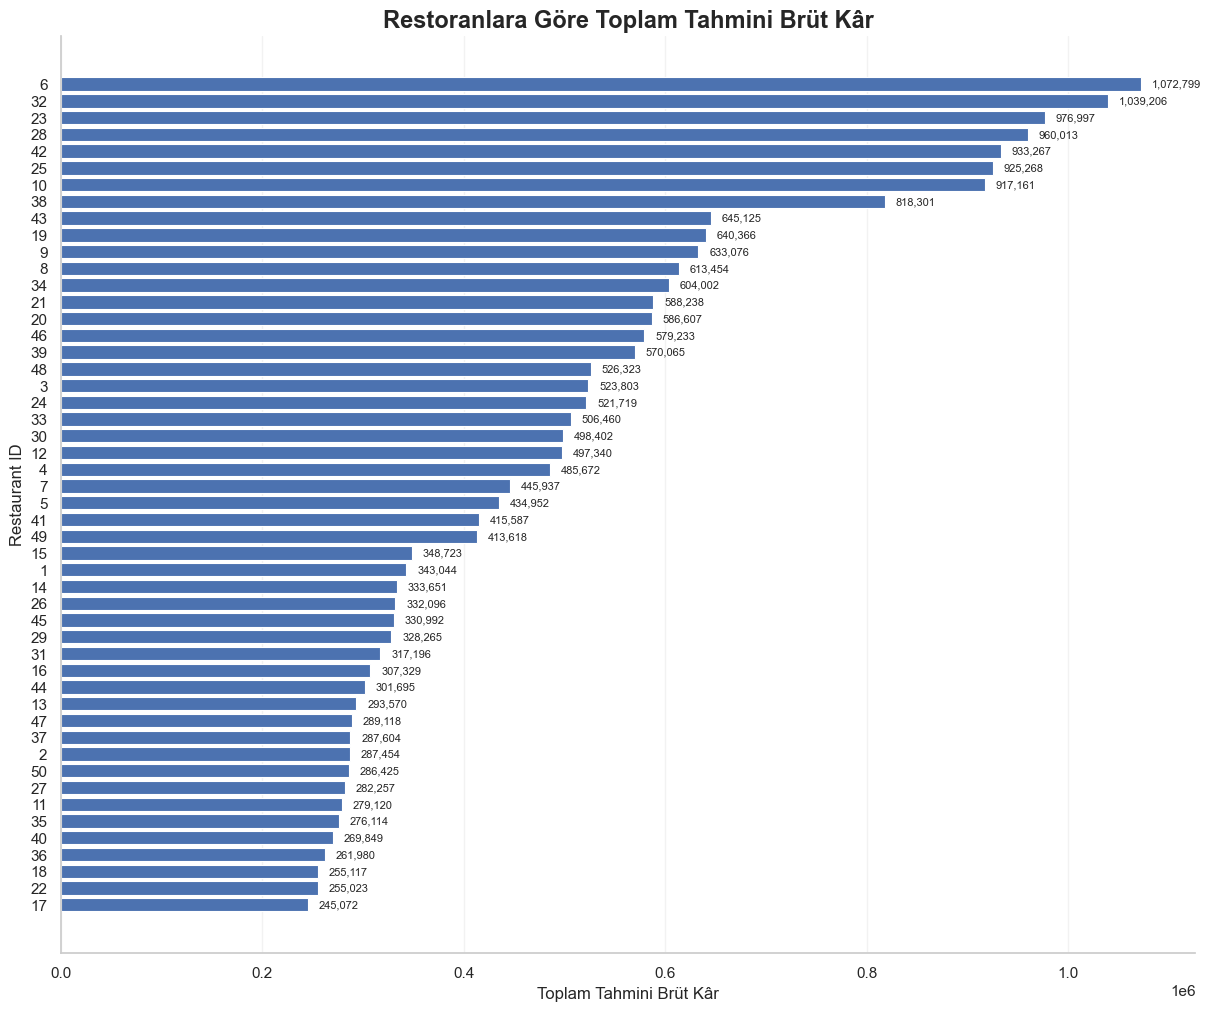

In [64]:
# ==========================================================
# RESTORANLARA GÖRE TOPLAM KÂR
# ==========================================================

plot_data = (
    restaurant_performance
    .sort_values(
        "total_estimated_profit",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(12,10),
    constrained_layout=True
)

bars = ax.barh(
    plot_data["restaurant_id"].astype(str),
    plot_data["total_estimated_profit"],
    edgecolor="white",
    linewidth=0.8
)

maximum = plot_data["total_estimated_profit"].max()

for bar, value in zip(
    bars,
    plot_data["total_estimated_profit"]
):

    ax.text(
        value + maximum*0.01,
        bar.get_y()+bar.get_height()/2,
        f"{value:,.0f}",
        va="center",
        fontsize=8
    )

ax.set_title(
    "Restoranlara Göre Toplam Tahmini Brüt Kâr",
    fontsize=17,
    fontweight="bold"
)

ax.set_xlabel("Toplam Tahmini Brüt Kâr")
ax.set_ylabel("Restaurant ID")

ax.grid(axis="x",alpha=.25)
ax.grid(axis="y",visible=False)

sns.despine()

plt.show()

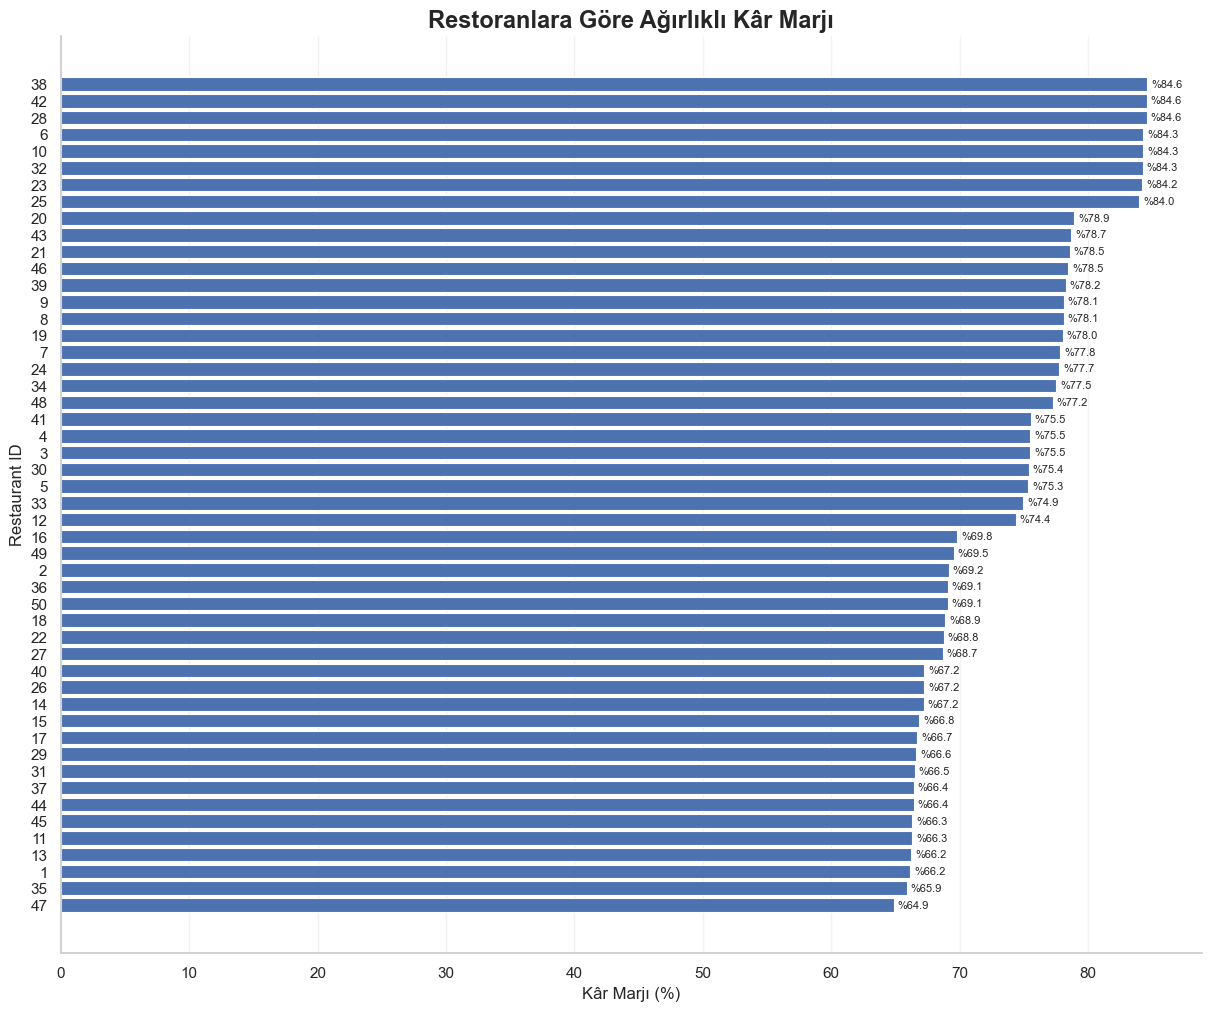

In [66]:
# ==========================================================
# RESTORANLARA GÖRE KÂR MARJI
# ==========================================================

plot_data = (
    restaurant_performance
    .sort_values(
        "weighted_profit_margin_pct",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(12,10),
    constrained_layout=True
)

bars = ax.barh(
    plot_data["restaurant_id"].astype(str),
    plot_data["weighted_profit_margin_pct"],
    edgecolor="white",
    linewidth=0.8
)

maximum = plot_data["weighted_profit_margin_pct"].max()

for bar, value in zip(
    bars,
    plot_data["weighted_profit_margin_pct"]
):

    ax.text(
        value+0.3,
        bar.get_y()+bar.get_height()/2,
        f"%{value:.1f}",
        va="center",
        fontsize=8
    )

ax.set_title(
    "Restoranlara Göre Ağırlıklı Kâr Marjı",
    fontsize=17,
    fontweight="bold"
)

ax.set_xlabel("Kâr Marjı (%)")
ax.set_ylabel("Restaurant ID")

ax.grid(axis="x",alpha=.25)
ax.grid(axis="y",visible=False)

sns.despine()

plt.show()

### Grafik Değerlendirmeleri

Restoranlar arasında toplam tahmini brüt kâr bakımından belirgin farklılıklar bulunmaktadır. En yüksek performans gösteren restoranların tahmini brüt kârı yaklaşık 1 milyon seviyesine ulaşırken, bazı restoranlarda bu değer yaklaşık 250 bin seviyesindedir.

Bu farklılık yalnızca fiyatlandırmadan değil; satış hacmi, ürün karması ve restoranın genel operasyonel performansından da kaynaklanmaktadır. Bu nedenle restoran bazında farklı fiyatlandırma stratejilerinin uygulanması proje kapsamında geliştirilecek Kâr/Fiyat Agent'ı için önemli bir gereksinim oluşturmaktadır.


##
Toplam tahmini brüt kâr ile karşılaştırıldığında ağırlıklı kâr marjı restoranların gerçek kârlılık verimliliğini daha iyi göstermektedir.

Analiz sonucunda restoranların ağırlıklı kâr marjlarının yaklaşık %65 ile %85 arasında değiştiği görülmektedir. Bazı restoranlar düşük satış hacmine rağmen yüksek kâr marjına sahip olurken, bazı restoranlar yüksek satış hacmine rağmen daha düşük marjlarla çalışmaktadır.

Bu durum yalnızca satış miktarına odaklanmanın yeterli olmadığını; fiyat optimizasyonu sürecinde satış hacmi ile kâr marjının birlikte değerlendirilmesi gerektiğini göstermektedir.

# 7. Promosyon Etkisinin Analizi

Bu bölümde promosyon uygulamalarının satış performansı ve tahmini kârlılık üzerindeki etkisi incelenecektir.

Amaç, promosyonların gerçekten satışları artırıp artırmadığını ve bu artışın kârlılığı nasıl etkilediğini belirlemektir. Elde edilen bulgular, geliştirilecek Kâr/Fiyat Agent'ının hangi durumlarda promosyon önerisi sunması gerektiğinin belirlenmesinde kullanılacaktır.

In [80]:
# =====================================================
# 6. PROMOSYON ETKİSİNİN ANALİZİ
# =====================================================

# -----------------------------------------------------
# 6.1 Promosyon gruplarının özet tablosu
# -----------------------------------------------------

promotion_summary = (
    sales_data
    .groupby("has_promotion", as_index=False)
    .agg(
        observation_count=("has_promotion", "size"),
        total_quantity=("quantity_sold", "sum"),
        average_quantity=("quantity_sold", "mean"),
        average_price=("actual_selling_price", "mean"),
        average_unit_profit=("unit_profit", "mean"),
        average_profit_margin_pct=("unit_profit_margin_pct", "mean"),
        total_revenue=("revenue", "sum"),
        average_revenue=("revenue", "mean"),
        total_estimated_profit=("estimated_profit", "sum"),
        average_estimated_profit=("estimated_profit", "mean")
    )
)

promotion_summary["promotion_status"] = (
    promotion_summary["has_promotion"]
    .map({
        False: "Promosyon Yok",
        True: "Promosyon Var"
    })
)

promotion_summary = promotion_summary[
    [
        "promotion_status",
        "observation_count",
        "total_quantity",
        "average_quantity",
        "average_price",
        "average_unit_profit",
        "average_profit_margin_pct",
        "total_revenue",
        "average_revenue",
        "total_estimated_profit",
        "average_estimated_profit"
    ]
].round(2)

promotion_summary

,promotion_status,observation_count,total_quantity,average_quantity,average_price,average_unit_profit,average_profit_margin_pct,total_revenue,average_revenue,total_estimated_profit,average_estimated_profit
0,Promosyon Yok,8502,2137688,251.43,19.78,15.88,76.13,26398050.06,3104.92,20557562.36,2417.97
1,Promosyon Var,1498,722316,482.19,13.61,9.71,65.32,6315368.04,4215.87,4327120.54,2888.60


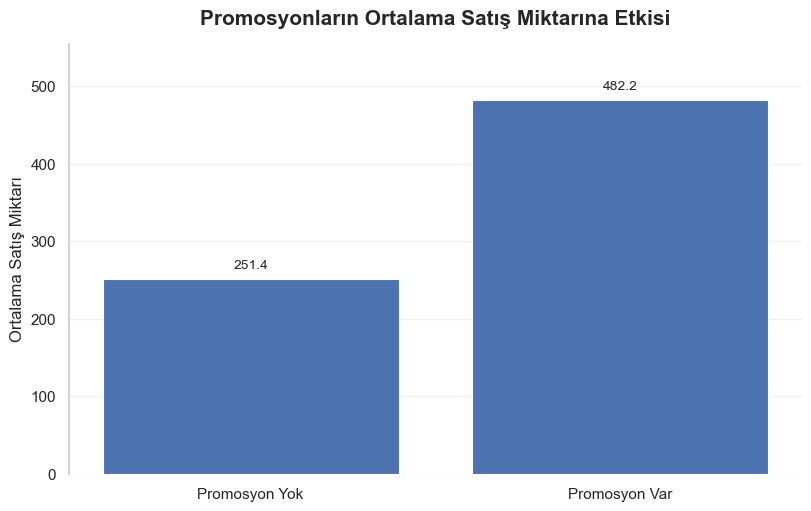

In [82]:
# -----------------------------------------------------
# 6.2 Promosyonların ortalama satış miktarına etkisi
# -----------------------------------------------------

promotion_quantity = (
    sales_data
    .groupby("has_promotion", as_index=False)
    .agg(
        average_quantity=("quantity_sold", "mean")
    )
)

promotion_quantity["promotion_status"] = (
    promotion_quantity["has_promotion"]
    .map({
        False: "Promosyon Yok",
        True: "Promosyon Var"
    })
)

fig, ax = plt.subplots(
    figsize=(8, 5),
    constrained_layout=True
)

bars = ax.bar(
    promotion_quantity["promotion_status"],
    promotion_quantity["average_quantity"],
    edgecolor="white",
    linewidth=0.8
)

maximum_quantity = promotion_quantity[
    "average_quantity"
].max()

for bar, value in zip(
    bars,
    promotion_quantity["average_quantity"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + maximum_quantity * 0.02,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title(
    "Promosyonların Ortalama Satış Miktarına Etkisi",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("")
ax.set_ylabel("Ortalama Satış Miktarı")
ax.set_ylim(0, maximum_quantity * 1.15)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

sns.despine(
    ax=ax,
    left=False,
    bottom=True
)

plt.show()

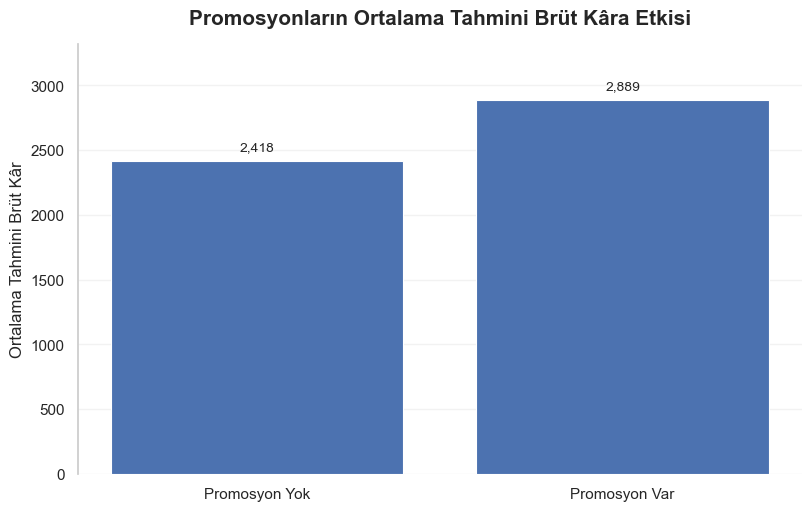

In [84]:
# -----------------------------------------------------
# 6.3 Promosyonların ortalama tahmini brüt kâra etkisi
# -----------------------------------------------------

promotion_profit = (
    sales_data
    .groupby("has_promotion", as_index=False)
    .agg(
        average_estimated_profit=("estimated_profit", "mean")
    )
)

promotion_profit["promotion_status"] = (
    promotion_profit["has_promotion"]
    .map({
        False: "Promosyon Yok",
        True: "Promosyon Var"
    })
)

fig, ax = plt.subplots(
    figsize=(8, 5),
    constrained_layout=True
)

bars = ax.bar(
    promotion_profit["promotion_status"],
    promotion_profit["average_estimated_profit"],
    edgecolor="white",
    linewidth=0.8
)

maximum_profit = promotion_profit[
    "average_estimated_profit"
].max()

for bar, value in zip(
    bars,
    promotion_profit["average_estimated_profit"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + maximum_profit * 0.02,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title(
    "Promosyonların Ortalama Tahmini Brüt Kâra Etkisi",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("")
ax.set_ylabel("Ortalama Tahmini Brüt Kâr")
ax.set_ylim(0, maximum_profit * 1.15)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

sns.despine(
    ax=ax,
    left=False,
    bottom=True
)

plt.show()

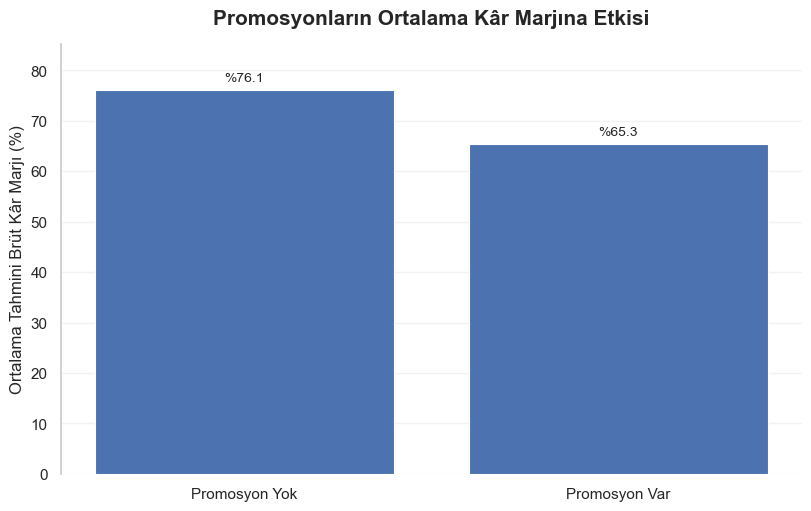

In [86]:
# -----------------------------------------------------
# 6.4 Promosyonların ortalama kâr marjına etkisi
# -----------------------------------------------------

promotion_margin = (
    sales_data
    .groupby("has_promotion", as_index=False)
    .agg(
        average_profit_margin_pct=(
            "unit_profit_margin_pct",
            "mean"
        )
    )
)

promotion_margin["promotion_status"] = (
    promotion_margin["has_promotion"]
    .map({
        False: "Promosyon Yok",
        True: "Promosyon Var"
    })
)

fig, ax = plt.subplots(
    figsize=(8, 5),
    constrained_layout=True
)

bars = ax.bar(
    promotion_margin["promotion_status"],
    promotion_margin["average_profit_margin_pct"],
    edgecolor="white",
    linewidth=0.8
)

maximum_margin = promotion_margin[
    "average_profit_margin_pct"
].max()

for bar, value in zip(
    bars,
    promotion_margin["average_profit_margin_pct"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + maximum_margin * 0.015,
        f"%{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title(
    "Promosyonların Ortalama Kâr Marjına Etkisi",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("")
ax.set_ylabel("Ortalama Tahmini Brüt Kâr Marjı (%)")
ax.set_ylim(0, maximum_margin * 1.12)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

sns.despine(
    ax=ax,
    left=False,
    bottom=True
)

plt.show()

### Promosyon Etkisinin Değerlendirilmesi

Promosyon uygulanan kayıtların ortalama satış miktarı 482,19 iken, promosyon uygulanmayan kayıtlarda bu değer 251,43'tür. Benzer biçimde, kayıt başına ortalama tahmini brüt kâr promosyonlu satışlarda 2.888,60; promosyon uygulanmayan satışlarda ise 2.417,97 olarak hesaplanmıştır.

Buna karşılık promosyonlu satışlarda ortalama satış fiyatı 13,61'e, ortalama birim kâr 9,71'e ve ortalama tahmini brüt kâr marjı %65,32'ye düşmektedir. Promosyon uygulanmayan kayıtlarda ortalama kâr marjı %76,13'tür.

Bu bulgular, promosyonların satış hacmini ve kayıt başına toplam kârı artırırken ürün başına kârı ve kâr marjını azalttığını göstermektedir. Başka bir ifadeyle promosyonlar, daha düşük birim kazanç karşılığında daha yüksek satış hacmi sağlayan bir strateji görünümündedir.

Bununla birlikte promosyon uygulanan ve uygulanmayan kayıtlar ürün, restoran türü, öğün ve diğer koşullar bakımından farklılık gösterebilir. Bu nedenle gözlenen farklar doğrudan nedensel bir promosyon etkisi olarak yorumlanmamalı; sonraki aşamada ürün ve restoran grupları içinde ayrıca incelenmelidir.

In [89]:
# =====================================================
# 6.5 ÜRÜN BAZINDA PROMOSYON ETKİSİ
# =====================================================

product_promotion_summary = (
    sales_data
    .groupby(
        ["menu_item_name", "has_promotion"],
        as_index=False
    )
    .agg(
        observation_count=("quantity_sold", "size"),
        average_quantity=("quantity_sold", "mean"),
        average_selling_price=("actual_selling_price", "mean"),
        average_unit_profit=("unit_profit", "mean"),
        average_profit_margin_pct=("unit_profit_margin_pct", "mean"),
        average_estimated_profit=("estimated_profit", "mean")
    )
)

product_promotion_summary["promotion_status"] = (
    product_promotion_summary["has_promotion"]
    .map({
        False: "Promosyon Yok",
        True: "Promosyon Var"
    })
)

product_promotion_summary = product_promotion_summary.round(2)

product_promotion_summary

,menu_item_name,has_promotion,observation_count,average_quantity,average_selling_price,average_unit_profit,average_profit_margin_pct,average_estimated_profit,promotion_status
0,Beef Rendang,False,531,94.17,50.55,41.55,80.27,3646.47,Promosyon Yok
1,Beef Rendang,True,95,168.80,34.69,25.69,71.13,4093.22,Promosyon Var
2,Cendol,False,1023,214.63,8.30,6.30,74.72,1275.97,Promosyon Yok
3,Cendol,True,196,433.96,5.59,3.59,62.30,1526.97,Promosyon Var
4,Char Kway Teow,False,324,149.85,22.49,17.49,76.53,2451.31,Promosyon Yok
5,Char Kway Teow,True,52,302.42,14.64,9.64,63.71,2866.67,Promosyon Var
6,Chicken Chop,False,590,139.75,49.47,41.47,82.94,5395.02,Promosyon Yok
7,Chicken Chop,True,103,263.96,34.64,26.64,75.59,6816.93,Promosyon Var
8,Chicken Rice,False,279,204.44,16.93,12.93,75.08,2508.22,Promosyon Yok
9,Chicken Rice,True,55,380.18,11.85,7.85,64.05,2914.65,Promosyon Var


In [91]:
# =====================================================
# 6.6 PROMOSYONLU VE PROMOSYONSUZ ÜRÜN FARKLARI
# =====================================================

promotion_comparison = (
    product_promotion_summary
    .pivot(
        index="menu_item_name",
        columns="promotion_status",
        values=[
            "average_quantity",
            "average_selling_price",
            "average_unit_profit",
            "average_profit_margin_pct",
            "average_estimated_profit"
        ]
    )
)

promotion_comparison.columns = [
    f"{metric}_{status}"
    for metric, status in promotion_comparison.columns
]

promotion_comparison = promotion_comparison.reset_index()

promotion_comparison["quantity_change_pct"] = (
    (
        promotion_comparison[
            "average_quantity_Promosyon Var"
        ]
        -
        promotion_comparison[
            "average_quantity_Promosyon Yok"
        ]
    )
    /
    promotion_comparison[
        "average_quantity_Promosyon Yok"
    ]
    * 100
)

promotion_comparison["profit_change_pct"] = (
    (
        promotion_comparison[
            "average_estimated_profit_Promosyon Var"
        ]
        -
        promotion_comparison[
            "average_estimated_profit_Promosyon Yok"
        ]
    )
    /
    promotion_comparison[
        "average_estimated_profit_Promosyon Yok"
    ]
    * 100
)

promotion_comparison["margin_change_point"] = (
    promotion_comparison[
        "average_profit_margin_pct_Promosyon Var"
    ]
    -
    promotion_comparison[
        "average_profit_margin_pct_Promosyon Yok"
    ]
)

promotion_comparison = (
    promotion_comparison
    .sort_values(
        "profit_change_pct",
        ascending=False
    )
    .round(2)
)

promotion_comparison

,menu_item_name,average_quantity_Promosyon Var,average_quantity_Promosyon Yok,average_selling_price_Promosyon Var,average_selling_price_Promosyon Yok,average_unit_profit_Promosyon Var,average_unit_profit_Promosyon Yok,average_profit_margin_pct_Promosyon Var,average_profit_margin_pct_Promosyon Yok,average_estimated_profit_Promosyon Var,average_estimated_profit_Promosyon Yok,quantity_change_pct,profit_change_pct,margin_change_point
3,Chicken Chop,263.96,139.75,34.64,49.47,26.64,41.47,75.59,82.94,6816.93,5395.02,88.88,26.36,-7.35
6,Kaya Toast Set,751.27,381.14,7.51,10.53,4.71,7.73,60.58,72.23,3558.26,2883.90,97.11,23.38,-11.65
13,Teh Tarik,937.69,494.15,2.42,3.29,1.52,2.39,60.67,71.46,1426.79,1159.79,89.76,23.02,-10.79
11,Spaghetti Carbonara,239.93,116.04,36.99,56.64,27.99,47.64,74.30,83.31,6302.96,5183.13,106.76,21.61,-9.01
1,Cendol,433.96,214.63,5.59,8.30,3.59,6.30,62.30,74.72,1526.97,1275.97,102.19,19.67,-12.42
5,Iced Lemon Tea,580.46,314.17,4.47,6.54,3.27,5.34,72.08,80.76,1925.13,1613.03,84.76,19.35,-8.68
8,Mushroom Soup,170.53,92.47,15.87,22.49,12.37,18.99,76.71,83.72,1952.82,1664.26,84.42,17.34,-7.01
2,Char Kway Teow,302.42,149.85,14.64,22.49,9.64,17.49,63.71,76.53,2866.67,2451.31,101.82,16.94,-12.82
4,Chicken Rice,380.18,204.44,11.85,16.93,7.85,12.93,64.05,75.08,2914.65,2508.22,85.96,16.20,-11.03
10,Roti Canai,672.77,356.01,1.81,2.55,1.01,1.75,55.16,68.23,682.12,600.42,88.98,13.61,-13.07


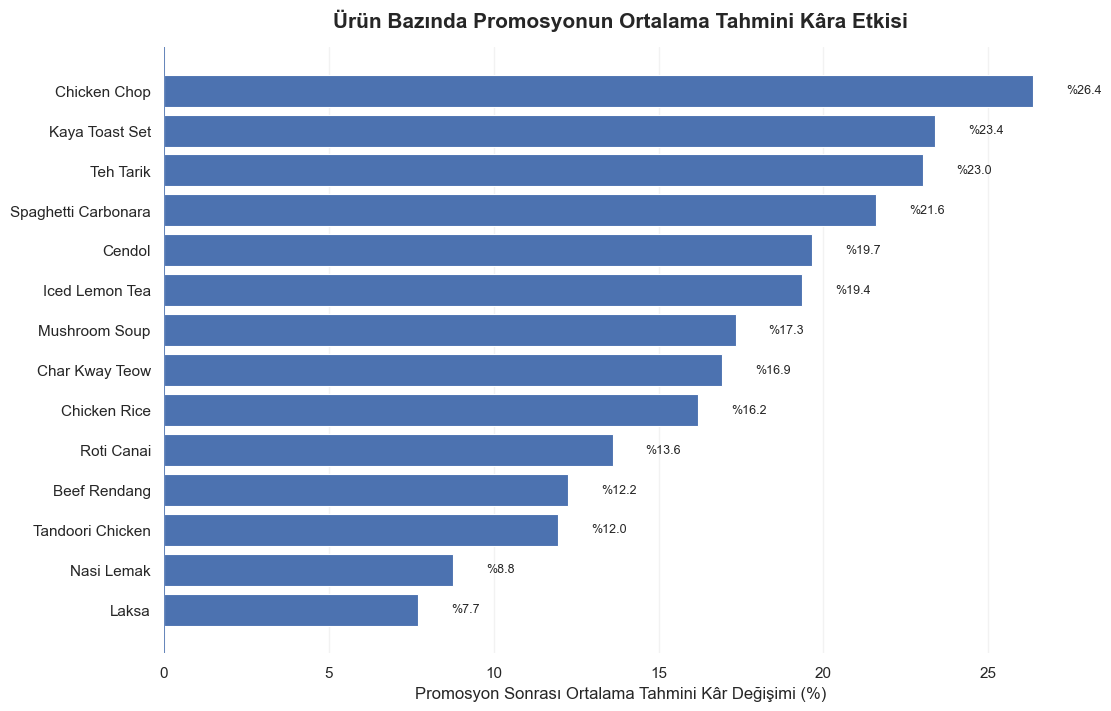

In [93]:
# =====================================================
# 6.7 ÜRÜN BAZINDA PROMOSYONUN KÂR DEĞİŞİMİ
# =====================================================

promotion_profit_plot = (
    promotion_comparison
    .sort_values(
        "profit_change_pct",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(11, 7),
    constrained_layout=True
)

bars = ax.barh(
    promotion_profit_plot["menu_item_name"],
    promotion_profit_plot["profit_change_pct"],
    edgecolor="white",
    linewidth=0.8
)

ax.axvline(
    0,
    linewidth=1.2
)

for bar, value in zip(
    bars,
    promotion_profit_plot["profit_change_pct"]
):
    offset = 1 if value >= 0 else -1

    ax.text(
        value + offset,
        bar.get_y() + bar.get_height() / 2,
        f"%{value:.1f}",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=9
    )

ax.set_title(
    "Ürün Bazında Promosyonun Ortalama Tahmini Kâra Etkisi",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Promosyon Sonrası Ortalama Tahmini Kâr Değişimi (%)")
ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.25
)

ax.grid(
    axis="y",
    visible=False
)

sns.despine(
    ax=ax,
    left=True,
    bottom=True
)

plt.show()

# 6. Promosyon Analizi

Bu bölümde promosyon uygulamalarının satış performansı üzerindeki etkisi incelenmiştir. Analizler hem genel düzeyde hem de ürün bazında gerçekleştirilerek promosyonların satış miktarı, gelir, tahmini brüt kâr ve kâr marjı üzerindeki etkileri değerlendirilmiştir.

---

## 6.1 Promosyonların Genel Etkisi

Öncelikle promosyon uygulanan ve uygulanmayan satış kayıtları karşılaştırılmıştır.

İlk sonuçlar promosyonların satış hacmini önemli ölçüde artırdığını göstermektedir.

- Promosyon uygulanan kayıtlarda ortalama satış miktarı yaklaşık **482 adet** iken,
- Promosyon uygulanmayan kayıtlarda bu değer yaklaşık **251 adet** olarak hesaplanmıştır.

Bu durum promosyonların müşteri talebini önemli ölçüde artırdığını göstermektedir.

Bununla birlikte fiyat indirimi nedeniyle;

- Ortalama satış fiyatı düşmektedir.
- Ortalama birim kâr azalmaktadır.
- Ortalama kâr marjı düşmektedir.

Ancak satış hacmindeki artış sayesinde toplam gelir ve toplam tahmini brüt kâr yükselmektedir.

---

## 6.2 Ortalama Satış Miktarına Etkisi

Grafik sonuçları promosyon uygulanan ürünlerde satış miktarının yaklaşık iki katına çıktığını göstermektedir.

Bu sonuç promosyonların özellikle talep oluşturma açısından oldukça başarılı olduğunu göstermektedir.

---

## 6.3 Ortalama Tahmini Brüt Kâra Etkisi

Promosyon uygulanan satışlarda ortalama tahmini brüt kâr yaklaşık **2.889** birime yükselirken,

promosyon uygulanmayan satışlarda bu değer yaklaşık **2.418** olarak hesaplanmıştır.

Bu durum promosyonların birim başına kârı azaltmasına rağmen toplam satış hacmini artırarak toplam kârlılığı yükselttiğini göstermektedir.

---

## 6.4 Ortalama Kâr Marjına Etkisi

Promosyon uygulanan satışlarda ortalama kâr marjı yaklaşık **%65.3** olarak hesaplanmıştır.

Promosyon uygulanmayan satışlarda ise ortalama kâr marjı **%76.1** seviyesindedir.

Dolayısıyla promosyonlar daha yüksek satış hacmi oluştururken kâr marjında yaklaşık **11 puanlık** bir azalmaya neden olmaktadır.

Bu sonuç fiyat indiriminin doğal bir sonucu olarak değerlendirilebilir.

---

## 6.5 Ürün Bazında Promosyon Analizi

Genel analizlerin ardından promosyonların her ürün üzerindeki etkisi ayrı ayrı incelenmiştir.

Her ürün için;

- Ortalama satış miktarı
- Ortalama satış fiyatı
- Ortalama birim kâr
- Ortalama kâr marjı
- Ortalama tahmini brüt kâr

promosyon uygulanan ve uygulanmayan durumlar için karşılaştırılmıştır.

Bu analiz sayesinde promosyonlardan en fazla fayda sağlayan ürünler belirlenmiştir.

---

## 6.6 Ürün Bazında Promosyon Performansı

Ürün bazında hesaplanan sonuçlar promosyonların bütün ürünlerde aynı etkiyi oluşturmadığını göstermektedir.

Bazı ürünlerde promosyonlar oldukça yüksek satış artışı sağlarken,

bazı ürünlerde satış artışı daha sınırlı kalmaktadır.

Benzer şekilde bazı ürünlerde kârlılık önemli ölçüde artarken bazı ürünlerde marj kaybı daha belirgin hale gelmektedir.

Bu nedenle bütün ürünler için tek tip promosyon stratejisi uygulanması yerine ürün bazlı promosyon planlaması yapılması daha uygun olacaktır.

---

## 6.7 Ürün Bazında Tahmini Kâr Değişimi

Promosyon sonrası tahmini brüt kâr değişimi incelendiğinde en yüksek iyileşmenin aşağıdaki ürünlerde gerçekleştiği görülmektedir.

- Chicken Chop
- Kaya Toast Set
- Teh Tarik
- Spaghetti Carbonara
- Cendol

Buna karşılık;

- Laksa
- Nasi Lemak
- Tandoori Chicken

ürünlerinde promosyonun sağladığı ek kâr artışı görece daha düşük seviyede kalmıştır.

Bu sonuçlar agent sisteminin gelecekte;

- hangi ürünlerde promosyon önerileceği,
- hangi ürünlerde promosyon oranının azaltılacağı,
- hangi ürünlerde promosyon uygulanmasının gerekli olmadığı

konularında karar verebilmesi için önemli girdiler sağlamaktadır.

---

## Bölüm Özeti

Bu bölümde yapılan analizler aşağıdaki temel sonuçları ortaya koymuştur.

- Promosyonlar satış miktarını önemli ölçüde artırmaktadır.
- Ortalama satış fiyatı promosyon nedeniyle düşmektedir.
- Ortalama birim kâr azalmaktadır.
- Ortalama kâr marjı yaklaşık 11 puan düşmektedir.
- Buna rağmen toplam tahmini brüt kâr artmaktadır.
- Promosyonların etkisi ürünlere göre önemli farklılıklar göstermektedir.
- Bazı ürünlerde promosyonlar oldukça yüksek ek kâr üretirken bazı ürünlerde etkisi sınırlı kalmaktadır.
- Bu nedenle agent sisteminin ürün bazlı dinamik promosyon önerileri üretmesi restoranların toplam kârlılığını artırabilecek önemli bir karar destek mekanizması sağlayacaktır.

# 7. Meal Type Analizi

Bu bölümde günün farklı öğünlerinde satış performansının nasıl değiştiği incelenmiştir.

Amaç;

- hangi öğünde satışların yoğunlaştığını,
- hangi öğünde kârlılığın daha yüksek olduğunu,
- agent sisteminin hangi saatlerde hangi ürünleri önereceğini belirleyebilmektir.

In [97]:
# ============================================================
# 7.1 MEAL TYPE ANALİZİ - ÖZET TABLO
# ============================================================

meal_summary = (
    sales_data
    .groupby("meal_type", as_index=False)
    .agg(
        observation_count=("meal_type","size"),
        total_quantity=("quantity_sold","sum"),
        average_quantity=("quantity_sold","mean"),
        average_price=("actual_selling_price","mean"),
        average_unit_profit=("unit_profit","mean"),
        average_profit_margin_pct=("unit_profit_margin_pct","mean"),
        total_revenue=("revenue","sum"),
        average_revenue=("revenue","mean"),
        total_estimated_profit=("estimated_profit","sum"),
        average_estimated_profit=("estimated_profit","mean")
    )
    .round(2)
)

meal_summary

,meal_type,observation_count,total_quantity,average_quantity,average_price,average_unit_profit,average_profit_margin_pct,total_revenue,average_revenue,total_estimated_profit,average_estimated_profit
0,Breakfast,2515,1157602,460.28,7.81,5.74,70.94,8199828.90,3260.37,5909026.90,2349.51
1,Dinner,3999,839299,209.88,22.80,18.12,75.35,12027687.92,3007.67,9268466.12,2317.70
2,Lunch,3486,863103,247.59,22.31,17.97,76.12,12485901.28,3581.73,9707189.88,2784.62


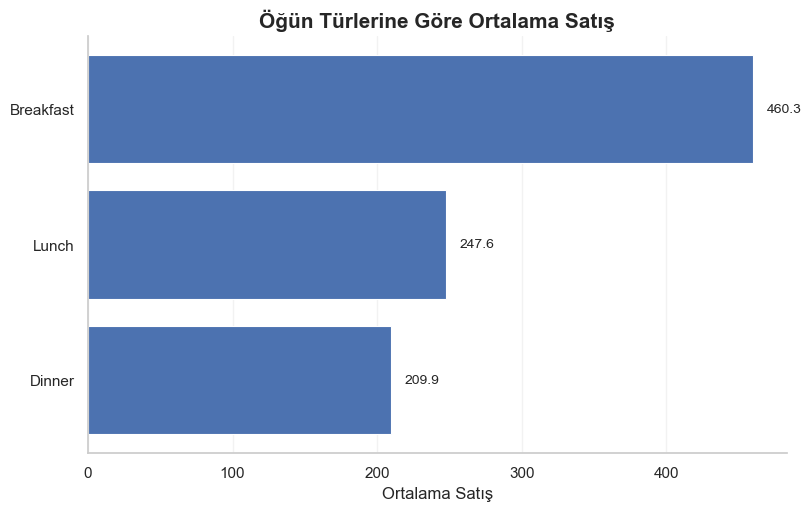

In [99]:
# ============================================================
# 7.2 MEAL TYPE - ORTALAMA SATIŞ
# ============================================================

fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)

plot_data = meal_summary.sort_values(
    "average_quantity",
    ascending=True
)

bars = ax.barh(
    plot_data["meal_type"],
    plot_data["average_quantity"],
    edgecolor="white",
    linewidth=.8
)

maximum = plot_data["average_quantity"].max()

for bar,value in zip(bars,plot_data["average_quantity"]):

    ax.text(
        value+maximum*0.02,
        bar.get_y()+bar.get_height()/2,
        f"{value:.1f}",
        va="center",
        fontsize=10
    )

ax.set_title(
    "Öğün Türlerine Göre Ortalama Satış",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Ortalama Satış")

ax.grid(axis="x",alpha=.25)
ax.grid(axis="y",visible=False)

sns.despine()

plt.show()

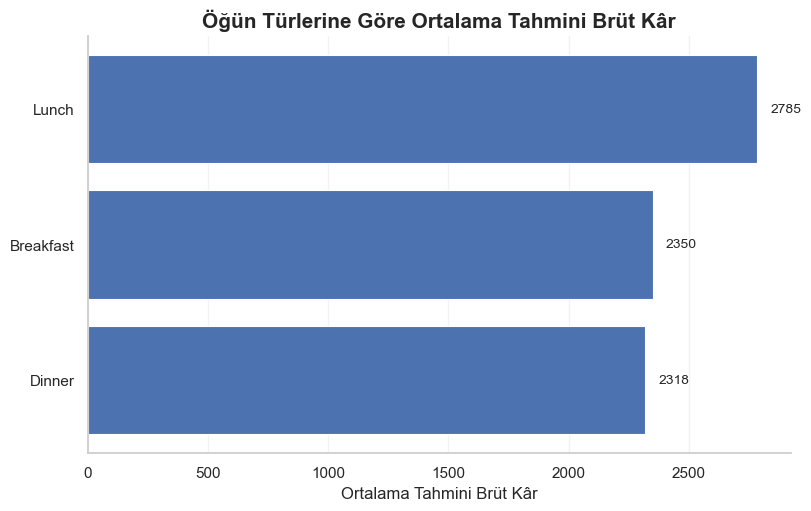

In [101]:
# ============================================================
# 7.3 MEAL TYPE - ORTALAMA KÂR
# ============================================================

fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)

plot_data = meal_summary.sort_values(
    "average_estimated_profit",
    ascending=True
)

bars = ax.barh(
    plot_data["meal_type"],
    plot_data["average_estimated_profit"],
    edgecolor="white",
    linewidth=.8
)

maximum = plot_data["average_estimated_profit"].max()

for bar,value in zip(bars,plot_data["average_estimated_profit"]):

    ax.text(
        value+maximum*0.02,
        bar.get_y()+bar.get_height()/2,
        f"{value:.0f}",
        va="center",
        fontsize=10
    )

ax.set_title(
    "Öğün Türlerine Göre Ortalama Tahmini Brüt Kâr",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Ortalama Tahmini Brüt Kâr")

ax.grid(axis="x",alpha=.25)
ax.grid(axis="y",visible=False)

sns.despine()

plt.show()

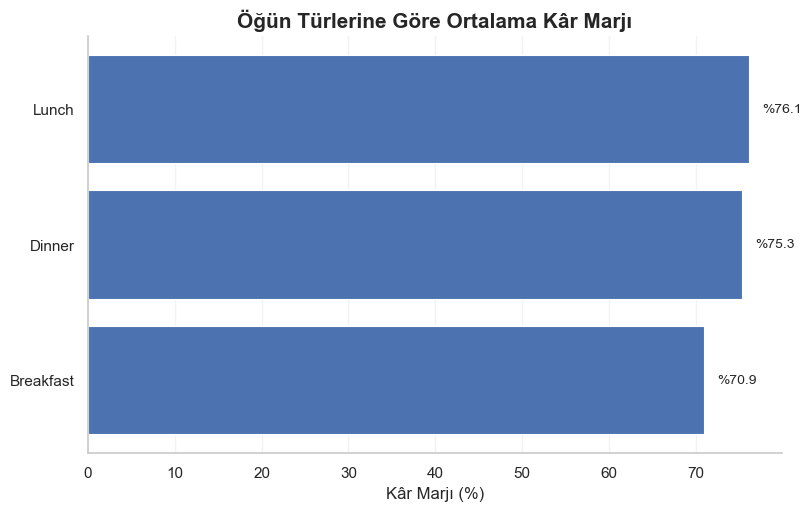

In [103]:
# ============================================================
# 7.4 MEAL TYPE - KÂR MARJI
# ============================================================

fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)

plot_data = meal_summary.sort_values(
    "average_profit_margin_pct",
    ascending=True
)

bars = ax.barh(
    plot_data["meal_type"],
    plot_data["average_profit_margin_pct"],
    edgecolor="white",
    linewidth=.8
)

maximum = plot_data["average_profit_margin_pct"].max()

for bar,value in zip(bars,plot_data["average_profit_margin_pct"]):

    ax.text(
        value+maximum*0.02,
        bar.get_y()+bar.get_height()/2,
        f"%{value:.1f}",
        va="center",
        fontsize=10
    )

ax.set_title(
    "Öğün Türlerine Göre Ortalama Kâr Marjı",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Kâr Marjı (%)")

ax.grid(axis="x",alpha=.25)
ax.grid(axis="y",visible=False)

sns.despine()

plt.show()

## Meal Type Analizi

Meal type değişkeni incelendiğinde farklı öğünlerde satış ve kârlılık açısından belirgin farklılıklar olduğu görülmektedir.

- Breakfast öğünü ortalama 460.3 adet ile en yüksek satış miktarına sahiptir.
- Lunch ortalama 247.6 adet ile ikinci sırada yer alırken Dinner ortalama 209.9 adet ile en düşük satış hacmine sahiptir.
- Ortalama tahmini brüt kâr açısından Lunch (2784.6) ilk sırada yer almakta, Breakfast (2349.5) ve Dinner (2317.7) ise birbirine yakın değerlere sahiptir.
- Ortalama kâr marjı Lunch (%76.1) ve Dinner (%75.3) öğünlerinde birbirine oldukça yakın olup Breakfast (%70.9) öğününe göre daha yüksektir.

Sonuç olarak Breakfast öğününde yüksek satış hacmi bulunmasına rağmen kâr marjı görece daha düşüktür. Lunch ise hem yüksek kârlılık hem de yüksek kâr marjı ile işletme açısından en avantajlı öğün olarak öne çıkmaktadır. Bu bulgular, geliştirilecek karar destek sisteminin öğün bazlı dinamik fiyatlandırma ve promosyon stratejileri oluşturmasına katkı sağlayacaktır.

In [106]:
# ===========================================================
# 7.5 EN ÇOK SATILAN ÜRÜNLER (MEAL TYPE BAZINDA)
# ===========================================================

meal_product = (
    sales_data
    .groupby(
        ["meal_type", "menu_item_name"],
        as_index=False
    )
    .agg(
        observation_count=("quantity_sold","size"),
        total_quantity=("quantity_sold","sum"),
        average_quantity=("quantity_sold","mean"),
        average_price=("actual_selling_price","mean"),
        average_unit_profit=("unit_profit","mean"),
        average_profit_margin_pct=("unit_profit_margin_pct","mean"),
        total_estimated_profit=("estimated_profit","sum"),
        average_estimated_profit=("estimated_profit","mean")
    )
    .round(2)
)

meal_product

,meal_type,menu_item_name,observation_count,total_quantity,average_quantity,average_price,average_unit_profit,average_profit_margin_pct,total_estimated_profit,average_estimated_profit
0,Breakfast,Iced Lemon Tea,205,82043,400.21,6.17,4.97,79.37,389699.48,1900.97
1,Breakfast,Kaya Toast Set,1245,544101,437.03,10.07,7.27,70.47,3717236.83,2985.73
2,Breakfast,Nasi Lemak,347,128876,371.40,11.14,8.64,74.74,1051822.78,3031.19
3,Breakfast,Roti Canai,340,156462,460.18,2.39,1.59,65.89,237337.65,698.05
4,Breakfast,Teh Tarik,378,246120,651.11,3.07,2.17,68.99,512930.16,1356.96
5,Dinner,Beef Rendang,327,32274,98.70,47.21,38.21,78.60,1114964.20,3409.68
6,Dinner,Cendol,601,139683,232.42,7.97,5.97,73.12,745316.15,1240.13
7,Dinner,Char Kway Teow,170,26651,156.77,21.12,16.12,74.24,374224.79,2201.32
8,Dinner,Chicken Chop,335,48204,143.89,48.30,40.30,82.32,1751785.91,5229.21
9,Dinner,Chicken Rice,149,31366,210.51,16.32,12.32,73.86,359594.52,2413.39


In [108]:
top_meal_products = (
    meal_product
    .sort_values(
        "average_quantity",
        ascending=False
    )
    .groupby("meal_type")
    .head(1)
    .reset_index(drop=True)
)

top_meal_products

,meal_type,menu_item_name,observation_count,total_quantity,average_quantity,average_price,average_unit_profit,average_profit_margin_pct,total_estimated_profit,average_estimated_profit
0,Breakfast,Teh Tarik,378,246120,651.11,3.07,2.17,68.99,512930.16,1356.96
1,Lunch,Teh Tarik,382,214630,561.86,3.13,2.23,69.68,455935.00,1193.55
2,Dinner,Teh Tarik,387,182326,471.13,3.26,2.36,70.83,407336.13,1052.55


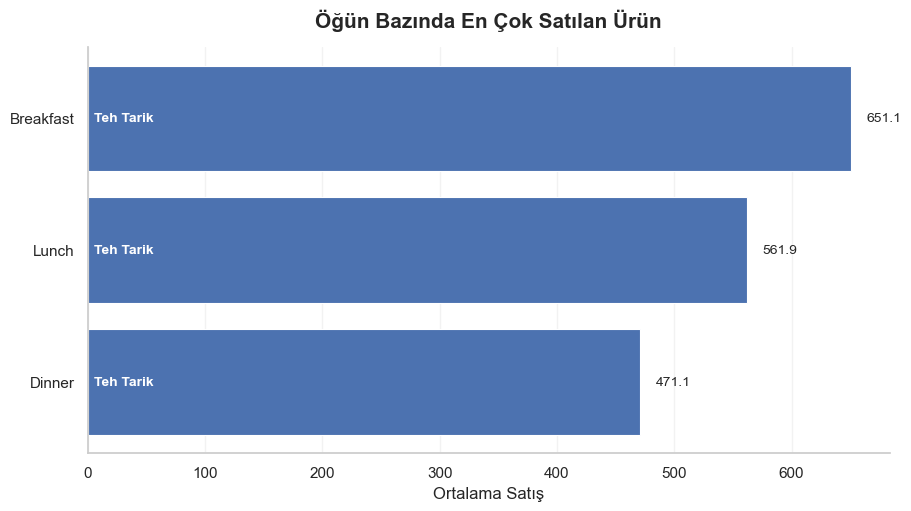

In [110]:
fig, ax = plt.subplots(
    figsize=(9,5),
    constrained_layout=True
)

plot_data = top_meal_products.sort_values(
    "average_quantity",
    ascending=True
)

bars = ax.barh(
    plot_data["meal_type"],
    plot_data["average_quantity"],
    edgecolor="white",
    linewidth=.8
)

maximum = plot_data["average_quantity"].max()

for bar, value in zip(
    bars,
    plot_data["average_quantity"]
):

    ax.text(
        value + maximum*0.02,
        bar.get_y()+bar.get_height()/2,
        f"{value:.1f}",
        va="center",
        fontsize=10
    )

for bar, product in zip(
    bars,
    plot_data["menu_item_name"]
):

    ax.text(
        5,
        bar.get_y()+bar.get_height()/2,
        product,
        va="center",
        ha="left",
        fontsize=10,
        color="white",
        fontweight="bold"
    )

ax.set_title(
    "Öğün Bazında En Çok Satılan Ürün",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Ortalama Satış")

ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=.25
)

ax.grid(
    axis="y",
    visible=False
)

sns.despine()

plt.show()

In [112]:
# ==========================================================
# 7.5 ÖĞÜN BAZINDA EN ÇOK KÂR GETİREN ÜRÜN
# ==========================================================

top_profit_products = (
    meal_product
    .sort_values(
        "average_estimated_profit",
        ascending=False
    )
    .groupby("meal_type")
    .head(1)
    .reset_index(drop=True)
)

top_profit_products

,meal_type,menu_item_name,observation_count,total_quantity,average_quantity,average_price,average_unit_profit,average_profit_margin_pct,total_estimated_profit,average_estimated_profit
0,Lunch,Chicken Chop,358,61437,171.61,46.29,38.29,81.41,2133419.09,5959.27
1,Dinner,Spaghetti Carbonara,358,48008,134.10,53.65,44.65,81.95,1902344.44,5313.81
2,Breakfast,Nasi Lemak,347,128876,371.40,11.14,8.64,74.74,1051822.78,3031.19


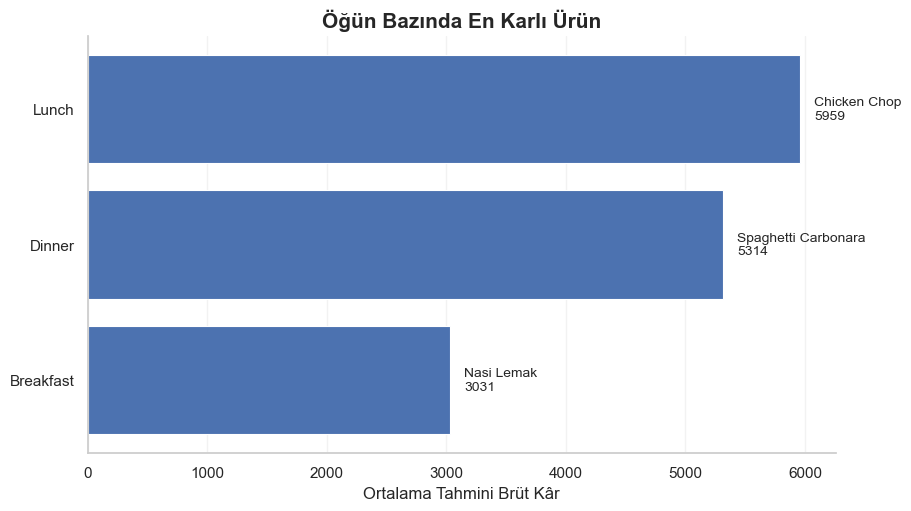

In [114]:
# ==========================================================
# 7.5.1 GRAFİK
# ==========================================================

fig, ax = plt.subplots(
    figsize=(9,5),
    constrained_layout=True
)

plot_data = top_profit_products.sort_values(
    "average_estimated_profit",
    ascending=True
)

bars = ax.barh(
    plot_data["meal_type"],
    plot_data["average_estimated_profit"],
    edgecolor="white",
    linewidth=.8
)

maximum = plot_data["average_estimated_profit"].max()

for bar, value, product in zip(
    bars,
    plot_data["average_estimated_profit"],
    plot_data["menu_item_name"]
):

    ax.text(
        value + maximum*0.02,
        bar.get_y()+bar.get_height()/2,
        f"{product}\n{value:.0f}",
        va="center",
        fontsize=10
    )

ax.set_title(
    "Öğün Bazında En Karlı Ürün",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Ortalama Tahmini Brüt Kâr")

ax.grid(axis="x",alpha=.25)
ax.grid(axis="y",visible=False)

sns.despine()

plt.show()

### Grafik Yorumu

Grafik, her öğün türünde ortalama tahmini brüt kârı en yüksek ürünü göstermektedir.

Analiz sonucunda;

- Kahvaltı öğününde **Nasi Lemak** yaklaşık **3.031** ortalama tahmini brüt kâr ile en yüksek kârlılığa sahip üründür.
- Öğle öğününde **Chicken Chop** yaklaşık **5.959** ortalama tahmini brüt kâr ile ilk sırada yer almaktadır.
- Akşam öğününde ise **Spaghetti Carbonara** yaklaşık **5.314** ortalama tahmini brüt kâr ile en yüksek ekonomik katkıyı sağlamaktadır.

Bu sonuçlar, en çok satılan ürün ile en yüksek kâr sağlayan ürünün her zaman aynı olmayabileceğini göstermektedir. Agent sistemi yalnızca satış hacmini değil, beklenen kârlılığı da dikkate alarak öneriler oluşturabilir.

Yoğun saatlerde veya stok kısıtı bulunmayan durumlarda bu ürünlerin öncelikli olarak önerilmesi, restoranın toplam gelirini ve operasyonel verimliliğini artırabilecek önemli bir karar destek mekanizması sunmaktadır.

> **Önemli İçgörü**
>
> Analizler, en çok satılan ürün ile en yüksek kâr sağlayan ürünün farklı olabileceğini göstermektedir. Bu nedenle öneri sistemi yalnızca satış miktarını değil, beklenen kârlılığı da dikkate almalıdır. Böylece restoran cirosu yerine toplam kârlılığın artırılması hedeflenebilir.

In [118]:
# ==========================================================
# 8.1 WEATHER ANALYSIS - ÖZET TABLO
# ==========================================================

weather_summary = (
    sales_data
    .groupby("weather_condition", as_index=False)
    .agg(
        observation_count=("weather_condition","size"),
        total_quantity=("quantity_sold","sum"),
        average_quantity=("quantity_sold","mean"),

        average_price=("actual_selling_price","mean"),

        average_unit_profit=("unit_profit","mean"),

        average_profit_margin_pct=("unit_profit_margin_pct","mean"),

        total_revenue=("revenue","sum"),
        average_revenue=("revenue","mean"),

        total_estimated_profit=("estimated_profit","sum"),
        average_estimated_profit=("estimated_profit","mean")
    )
    .round(2)
)

weather_summary

,weather_condition,observation_count,total_quantity,average_quantity,average_price,average_unit_profit,average_profit_margin_pct,total_revenue,average_revenue,total_estimated_profit,average_estimated_profit
0,Cloudy,3045,856987,281.44,19.12,15.19,74.67,9934265.50,3262.48,7557681.80,2482.00
1,Rainy,2005,527936,263.31,18.95,15.02,74.62,6397461.54,3190.75,4883891.54,2435.86
2,Sunny,4950,1475081,298.00,18.66,14.79,74.37,16381691.06,3309.43,12443109.56,2513.76


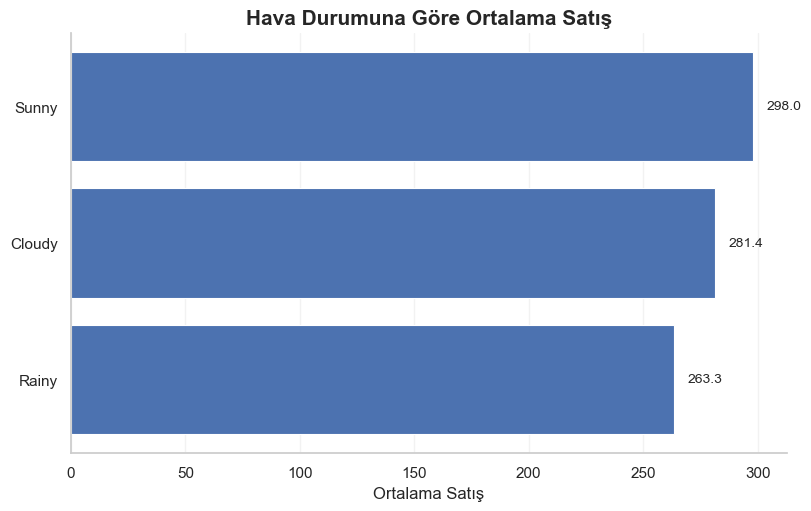

In [120]:
# ==========================================================
# 8.2 WEATHER - ORTALAMA SATIŞ
# ==========================================================

fig, ax = plt.subplots(
    figsize=(8,5),
    constrained_layout=True
)

plot_data = weather_summary.sort_values(
    "average_quantity",
    ascending=True
)

bars = ax.barh(
    plot_data["weather_condition"],
    plot_data["average_quantity"],
    edgecolor="white",
    linewidth=.8
)

maximum = plot_data["average_quantity"].max()

for bar, value in zip(
    bars,
    plot_data["average_quantity"]
):

    ax.text(
        value + maximum*0.02,
        bar.get_y()+bar.get_height()/2,
        f"{value:.1f}",
        va="center",
        fontsize=10
    )

ax.set_title(
    "Hava Durumuna Göre Ortalama Satış",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Ortalama Satış")

ax.grid(axis="x",alpha=.25)
ax.grid(axis="y",visible=False)

sns.despine()

plt.show()

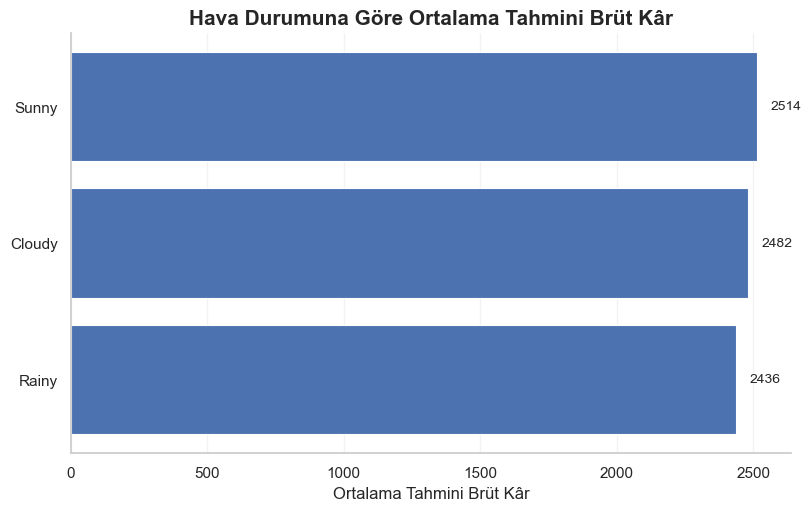

In [122]:
# ==========================================================
# 8.3 WEATHER - ORTALAMA TAHMİNİ BRÜT KÂR
# ==========================================================

fig, ax = plt.subplots(
    figsize=(8,5),
    constrained_layout=True
)

plot_data = weather_summary.sort_values(
    "average_estimated_profit",
    ascending=True
)

bars = ax.barh(
    plot_data["weather_condition"],
    plot_data["average_estimated_profit"],
    edgecolor="white",
    linewidth=.8
)

maximum = plot_data["average_estimated_profit"].max()

for bar, value in zip(
    bars,
    plot_data["average_estimated_profit"]
):

    ax.text(
        value + maximum*0.02,
        bar.get_y()+bar.get_height()/2,
        f"{value:.0f}",
        va="center",
        fontsize=10
    )

ax.set_title(
    "Hava Durumuna Göre Ortalama Tahmini Brüt Kâr",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Ortalama Tahmini Brüt Kâr")

ax.grid(axis="x",alpha=.25)
ax.grid(axis="y",visible=False)

sns.despine()

plt.show()

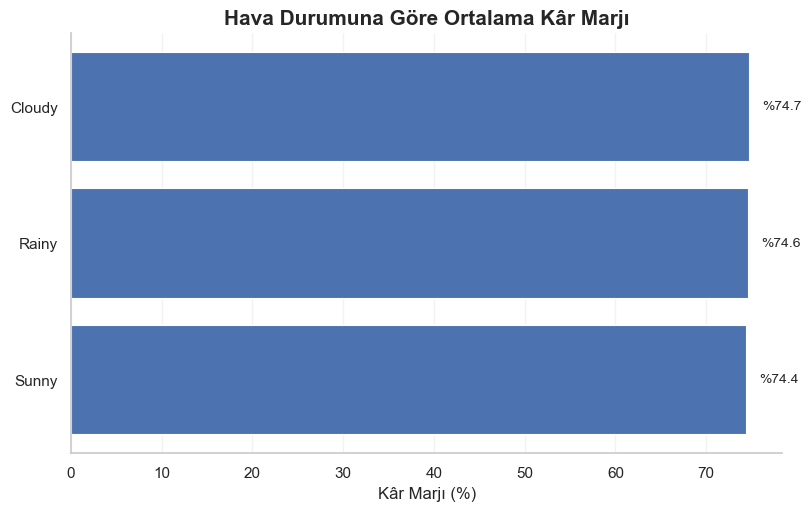

In [124]:
# ==========================================================
# 8.4 WEATHER - KÂR MARJI
# ==========================================================

fig, ax = plt.subplots(
    figsize=(8,5),
    constrained_layout=True
)

plot_data = weather_summary.sort_values(
    "average_profit_margin_pct",
    ascending=True
)

bars = ax.barh(
    plot_data["weather_condition"],
    plot_data["average_profit_margin_pct"],
    edgecolor="white",
    linewidth=.8
)

maximum = plot_data["average_profit_margin_pct"].max()

for bar, value in zip(
    bars,
    plot_data["average_profit_margin_pct"]
):

    ax.text(
        value + maximum*0.02,
        bar.get_y()+bar.get_height()/2,
        f"%{value:.1f}",
        va="center",
        fontsize=10
    )

ax.set_title(
    "Hava Durumuna Göre Ortalama Kâr Marjı",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Kâr Marjı (%)")

ax.grid(axis="x",alpha=.25)
ax.grid(axis="y",visible=False)

sns.despine()

plt.show()

## Genel Değerlendirme

Hava durumu bazında gerçekleştirilen analizler, satış performansının çevresel faktörlerden etkilendiğini göstermektedir. Güneşli hava koşullarında ortalama satış miktarı ve ortalama tahmini brüt kâr diğer hava koşullarına göre daha yüksek seviyede gerçekleşmiştir. Buna karşılık ortalama kâr marjının tüm hava koşullarında benzer seviyelerde kaldığı görülmektedir. Bu durum, hava koşullarının ürünlerin birim kârlılığından ziyade müşteri talebi ve satış hacmi üzerinde etkili olduğunu göstermektedir.

Elde edilen bulgular, hava durumunun talep tahmininde kullanılabilecek önemli bir değişken olduğunu ortaya koymaktadır. Özellikle güneşli günlerde satış hacmi yüksek ürünlerin ön plana çıkarılması, stok planlamasının buna göre yapılması ve ürün önerilerinin dinamik olarak güncellenmesi agent tabanlı karar destek sistemi açısından önemli avantajlar sağlayacaktır. Böylece sistem, yalnızca geçmiş satış verilerine değil aynı zamanda çevresel koşullara da uyum sağlayarak daha doğru ve proaktif öneriler üretebilecektir.

# 9. Tarih Bazlı Zaman Analizi

Veri setinde saat bilgisi bulunmadığı için saatlik analiz gerçekleştirilememektedir. Bu nedenle zaman boyutu; haftanın günü, ay ve hafta sonu durumu üzerinden incelenmiştir.

In [129]:
# ============================================================
# 9. ZAMAN DEĞİŞKENLERİNİN OLUŞTURULMASI
# ============================================================

# Tarih sütununu datetime formatına dönüştür
sales_data["date"] = pd.to_datetime(
    sales_data["date"],
    errors="coerce"
)

# Zaman değişkenlerini oluştur
sales_data["day_of_week"] = sales_data["date"].dt.day_name()
sales_data["month"] = sales_data["date"].dt.month_name()
sales_data["month_number"] = sales_data["date"].dt.month
sales_data["day_of_month"] = sales_data["date"].dt.day
sales_data["is_weekend"] = sales_data["date"].dt.dayofweek >= 5

# Türkçe etiketler
day_mapping = {
    "Monday": "Pazartesi",
    "Tuesday": "Salı",
    "Wednesday": "Çarşamba",
    "Thursday": "Perşembe",
    "Friday": "Cuma",
    "Saturday": "Cumartesi",
    "Sunday": "Pazar"
}

month_mapping = {
    "January": "Ocak",
    "February": "Şubat",
    "March": "Mart",
    "April": "Nisan",
    "May": "Mayıs",
    "June": "Haziran",
    "July": "Temmuz",
    "August": "Ağustos",
    "September": "Eylül",
    "October": "Ekim",
    "November": "Kasım",
    "December": "Aralık"
}

sales_data["day_name_tr"] = (
    sales_data["day_of_week"]
    .map(day_mapping)
)

sales_data["month_name_tr"] = (
    sales_data["month"]
    .map(month_mapping)
)

sales_data["weekend_status"] = (
    sales_data["is_weekend"]
    .map({
        False: "Hafta İçi",
        True: "Hafta Sonu"
    })
)

sales_data[
    [
        "date",
        "day_name_tr",
        "month_name_tr",
        "weekend_status"
    ]
].head()

,date,day_name_tr,month_name_tr,weekend_status
0,2024-01-01,Pazartesi,Ocak,Hafta İçi
1,2024-01-01,Pazartesi,Ocak,Hafta İçi
2,2024-01-01,Pazartesi,Ocak,Hafta İçi
3,2024-01-01,Pazartesi,Ocak,Hafta İçi
4,2024-01-01,Pazartesi,Ocak,Hafta İçi


In [131]:
# ============================================================
# 9.1 HAFTANIN GÜNLERİNE GÖRE PERFORMANS ÖZETİ
# ============================================================

day_order = [
    "Pazartesi",
    "Salı",
    "Çarşamba",
    "Perşembe",
    "Cuma",
    "Cumartesi",
    "Pazar"
]

day_summary = (
    sales_data
    .groupby("day_name_tr", as_index=False)
    .agg(
        observation_count=("day_name_tr", "size"),
        total_quantity=("quantity_sold", "sum"),
        average_quantity=("quantity_sold", "mean"),
        average_price=("actual_selling_price", "mean"),
        average_unit_profit=("unit_profit", "mean"),
        average_profit_margin_pct=("unit_profit_margin_pct", "mean"),
        total_revenue=("revenue", "sum"),
        average_revenue=("revenue", "mean"),
        total_estimated_profit=("estimated_profit", "sum"),
        average_estimated_profit=("estimated_profit", "mean")
    )
)

day_summary["day_name_tr"] = pd.Categorical(
    day_summary["day_name_tr"],
    categories=day_order,
    ordered=True
)

day_summary = (
    day_summary
    .sort_values("day_name_tr")
    .reset_index(drop=True)
    .round(2)
)

day_summary

,day_name_tr,observation_count,total_quantity,average_quantity,average_price,average_unit_profit,average_profit_margin_pct,total_revenue,average_revenue,total_estimated_profit,average_estimated_profit
0,Pazartesi,1513,384001,253.80,19.75,15.76,74.92,4546905.22,3005.22,3478396.32,2299.01
1,Salı,1383,333279,240.98,19.91,15.85,75.19,4153327.36,3003.13,3186250.76,2303.87
2,Çarşamba,1455,380958,261.83,19.35,15.44,74.83,4399024.64,3023.38,3358140.44,2308.00
3,Perşembe,1408,369740,262.60,18.01,14.25,74.63,4094262.62,2907.86,3115991.22,2213.06
4,Cuma,1424,349847,245.68,19.25,15.30,74.85,4114895.96,2889.67,3141459.96,2206.08
5,Cumartesi,1451,542530,373.90,17.41,13.64,73.29,5835936.44,4022.01,4394848.54,3028.84
6,Pazar,1366,499649,365.78,18.28,14.41,73.86,5569065.86,4076.91,4209595.66,3081.70


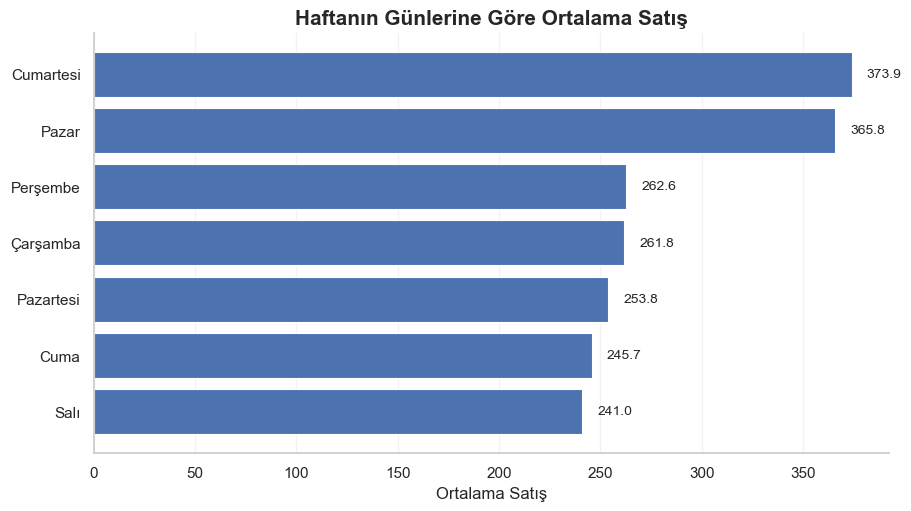

In [135]:
# ============================================================
# 9.2 HAFTANIN GÜNLERİ - ORTALAMA SATIŞ
# ============================================================

fig, ax = plt.subplots(
    figsize=(9,5),
    constrained_layout=True
)

plot_data = day_summary.sort_values(
    "average_quantity",
    ascending=True
)

bars = ax.barh(
    plot_data["day_name_tr"],
    plot_data["average_quantity"],
    edgecolor="white",
    linewidth=.8
)

maximum = plot_data["average_quantity"].max()

for bar, value in zip(
    bars,
    plot_data["average_quantity"]
):

    ax.text(
        value + maximum*0.02,
        bar.get_y()+bar.get_height()/2,
        f"{value:.1f}",
        va="center",
        fontsize=10
    )

ax.set_title(
    "Haftanın Günlerine Göre Ortalama Satış",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Ortalama Satış")

ax.grid(axis="x",alpha=.25)
ax.grid(axis="y",visible=False)

sns.despine()

plt.show()

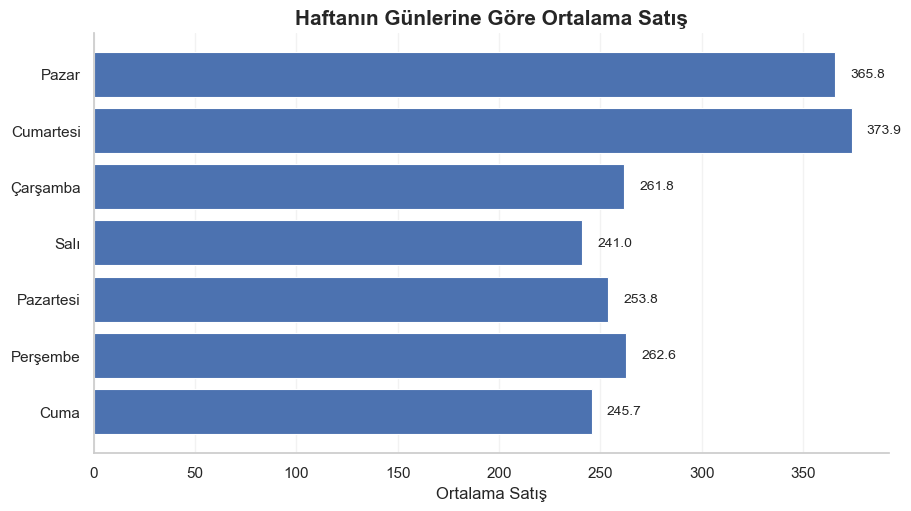

In [137]:
# ============================================================
# 9.2 HAFTANIN GÜNLERİ - ORTALAMA SATIŞ
# ============================================================

fig, ax = plt.subplots(
    figsize=(9,5),
    constrained_layout=True
)

plot_data = day_summary.sort_values(
    "average_estimated_profit",
    ascending=True
)

bars = ax.barh(
    plot_data["day_name_tr"],
    plot_data["average_quantity"],
    edgecolor="white",
    linewidth=.8
)

maximum = plot_data["average_quantity"].max()

for bar, value in zip(
    bars,
    plot_data["average_quantity"]
):

    ax.text(
        value + maximum*0.02,
        bar.get_y()+bar.get_height()/2,
        f"{value:.1f}",
        va="center",
        fontsize=10
    )

ax.set_title(
    "Haftanın Günlerine Göre Ortalama Satış",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Ortalama Satış")

ax.grid(axis="x",alpha=.25)
ax.grid(axis="y",visible=False)

sns.despine()

plt.show()

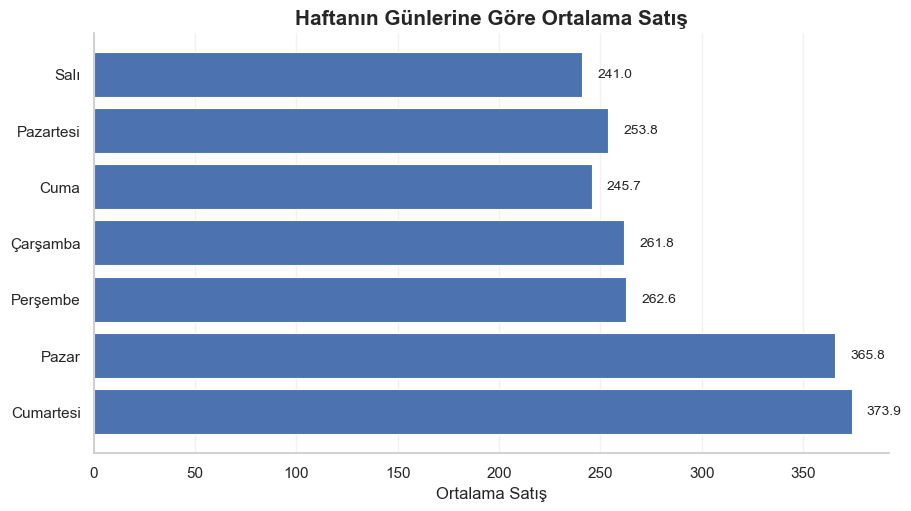

In [139]:
# ============================================================
# 9.2 HAFTANIN GÜNLERİ - ORTALAMA SATIŞ
# ============================================================

fig, ax = plt.subplots(
    figsize=(9,5),
    constrained_layout=True
)

plot_data = day_summary.sort_values(
    "average_profit_margin_pct",
    ascending=True
)

bars = ax.barh(
    plot_data["day_name_tr"],
    plot_data["average_quantity"],
    edgecolor="white",
    linewidth=.8
)

maximum = plot_data["average_quantity"].max()

for bar, value in zip(
    bars,
    plot_data["average_quantity"]
):

    ax.text(
        value + maximum*0.02,
        bar.get_y()+bar.get_height()/2,
        f"{value:.1f}",
        va="center",
        fontsize=10
    )

ax.set_title(
    "Haftanın Günlerine Göre Ortalama Satış",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Ortalama Satış")

ax.grid(axis="x",alpha=.25)
ax.grid(axis="y",visible=False)

sns.despine()

plt.show()

In [143]:
day_product = (
    sales_data
    .groupby(
        ["day_name_tr","menu_item_name"],
        as_index=False
    )
    .agg(
        observation_count=("menu_item_name","size"),
        total_quantity=("quantity_sold","sum"),
        average_quantity=("quantity_sold","mean"),
        average_price=("actual_selling_price","mean"),
        average_unit_profit=("unit_profit","mean"),
        average_profit_margin_pct=("unit_profit_margin_pct","mean"),
        total_estimated_profit=("estimated_profit","sum"),
        average_estimated_profit=("estimated_profit","mean")
    )
    .round(2)
)

### Değerlendirme

Haftanın günlerine göre yapılan analizler, satış performansının özellikle hafta sonlarında belirgin şekilde arttığını göstermektedir. Cumartesi ve Pazar günleri hem ortalama satış miktarı hem de ortalama tahmini brüt kâr açısından diğer günlerin önüne çıkmaktadır. Buna karşılık ortalama kâr marjı hafta boyunca oldukça benzer seviyelerde seyretmektedir. Bu durum, hafta sonlarında elde edilen daha yüksek toplam kârlılığın fiyatlandırmadan veya marj artışından değil, artan müşteri talebi ve satış hacminden kaynaklandığını göstermektedir. Bu bulgu, agent sisteminin hafta sonları için stok planlamasını güçlendirmesi, personel planlamasını optimize etmesi ve yüksek talep gören ürünleri önceliklendirmesi açısından önemli bir karar destek girdisi sağlayacaktır.

In [146]:
# ===========================================================
# 9.5 HAFTANIN GÜNÜNE GÖRE EN ÇOK SATILAN ÜRÜN
# ===========================================================

top_day_products = (
    sales_data
    .sort_values(
        "quantity_sold",
        ascending=False
    )
    .groupby("day_name_tr")
    .head(1)
    .reset_index(drop=True)
)

day_order = [
    "Pazartesi",
    "Salı",
    "Çarşamba",
    "Perşembe",
    "Cuma",
    "Cumartesi",
    "Pazar"
]

top_day_products["day_name_tr"] = pd.Categorical(
    top_day_products["day_name_tr"],
    categories=day_order,
    ordered=True
)

top_day_products = (
    top_day_products
    .sort_values("day_name_tr")
    .reset_index(drop=True)
)

top_day_products[[
    "day_name_tr",
    "menu_item_name",
    "quantity_sold",
    "actual_selling_price",
    "estimated_profit"
]]

,day_name_tr,menu_item_name,quantity_sold,actual_selling_price,estimated_profit
0,Pazartesi,Teh Tarik,1545,2.24,2070.30
1,Salı,Teh Tarik,1382,2.57,2307.94
2,Çarşamba,Teh Tarik,1224,2.28,1689.12
3,Perşembe,Teh Tarik,1352,2.11,1635.92
4,Cuma,Teh Tarik,1190,2.91,2391.90
5,Cumartesi,Teh Tarik,1517,1.80,1365.30
6,Pazar,Teh Tarik,1668,2.33,2385.24


### Değerlendirme

Haftanın günlerine göre en çok satılan ürün incelendiğinde tüm günlerde **Teh Tarik** ürününün ilk sırada yer aldığı görülmektedir. Bu durum ürünün yalnızca belirli günlerde değil, hafta boyunca istikrarlı ve yüksek talep gördüğünü göstermektedir.

Dolayısıyla Teh Tarik, restoranın temel talep oluşturan ürünlerinden biri olarak değerlendirilebilir. Agent sistemi bu ürünü stok planlamasında önceliklendirebilir, olası stok tükenmelerini önceden tahmin edebilir ve promosyon veya menü önerilerini oluştururken referans ürün olarak kullanabilir.

In [149]:
# ===========================================================
# 9.6 GÜN BAZINDA EN ÇOK SATILAN ÜRÜN
# ===========================================================

top_day_products = (
    day_product
    .sort_values(
        "total_quantity",
        ascending=False
    )
    .groupby("day_name_tr")
    .head(1)
    .reset_index(drop=True)
)

day_order = [
    "Pazartesi",
    "Salı",
    "Çarşamba",
    "Perşembe",
    "Cuma",
    "Cumartesi",
    "Pazar"
]

top_day_products["day_name_tr"] = pd.Categorical(
    top_day_products["day_name_tr"],
    categories=day_order,
    ordered=True
)

top_day_products = (
    top_day_products
    .sort_values("day_name_tr")
    .reset_index(drop=True)
)

top_day_products[[
    "day_name_tr",
    "menu_item_name",
    "observation_count",
    "total_quantity",
    "average_quantity",
    "average_price",
    "average_unit_profit",
    "average_profit_margin_pct",
    "total_estimated_profit",
    "average_estimated_profit"
]]

,day_name_tr,menu_item_name,observation_count,total_quantity,average_quantity,average_price,average_unit_profit,average_profit_margin_pct,total_estimated_profit,average_estimated_profit
0,Pazartesi,Teh Tarik,172,85551,497.39,3.15,2.25,69.71,180951.05,1052.04
1,Salı,Teh Tarik,152,74899,492.76,3.28,2.38,70.84,165639.78,1089.74
2,Çarşamba,Teh Tarik,164,86926,530.04,3.13,2.23,69.31,182533.56,1113.01
3,Perşembe,Teh Tarik,159,85240,536.10,3.13,2.23,69.44,179004.37,1125.81
4,Cuma,Teh Tarik,161,76540,475.40,3.31,2.41,71.41,176144.78,1094.07
5,Cumartesi,Teh Tarik,188,129300,687.77,3.03,2.13,68.78,270617.30,1439.45
6,Pazar,Kaya Toast Set,185,107442,580.77,9.57,6.77,69.13,706888.20,3821.02


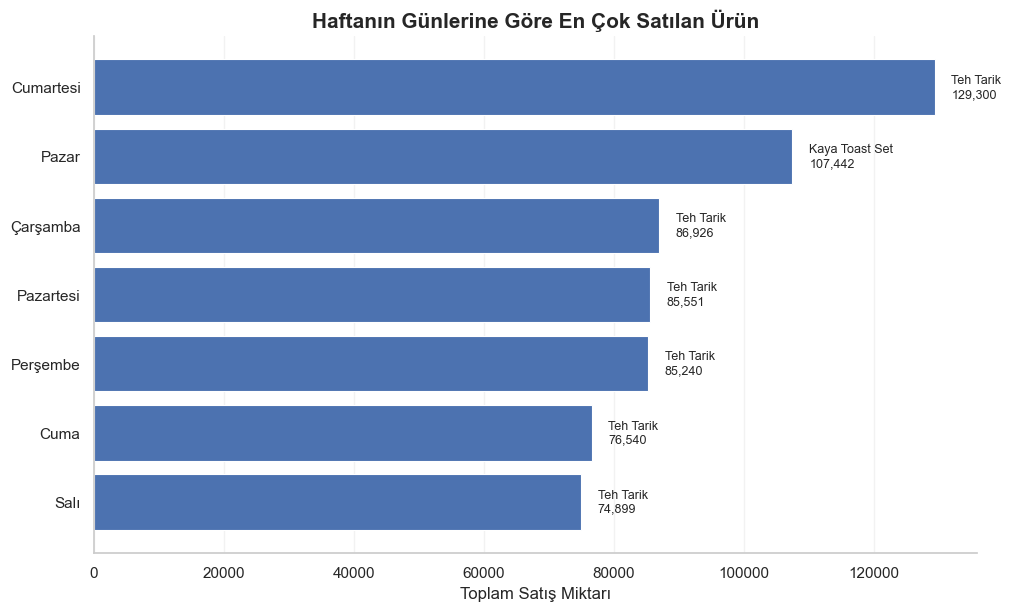

In [151]:
# ===========================================================
# 9.5 GRAFİK
# ===========================================================

fig, ax = plt.subplots(
    figsize=(10,6),
    constrained_layout=True
)

plot_data = top_day_products.sort_values(
    "total_quantity",
    ascending=True
)

bars = ax.barh(
    plot_data["day_name_tr"],
    plot_data["total_quantity"],
    edgecolor="white",
    linewidth=.8
)

maximum = plot_data["total_quantity"].max()

for bar, value, product in zip(
    bars,
    plot_data["total_quantity"],
    plot_data["menu_item_name"]
):

    ax.text(
        value + maximum*0.02,
        bar.get_y() + bar.get_height()/2,
        f"{product}\n{value:,.0f}",
        va="center",
        fontsize=9
    )

ax.set_title(
    "Haftanın Günlerine Göre En Çok Satılan Ürün",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Toplam Satış Miktarı")

ax.grid(axis="x", alpha=.25)
ax.grid(axis="y", visible=False)

sns.despine()

plt.show()

### Değerlendirme

Haftanın günleri ve menü ürünleri birlikte değerlendirildiğinde, **Teh Tarik** ürününün haftanın yedi gününün altısında en yüksek toplam satış miktarına sahip olduğu görülmektedir. Bu sonuç, ürünün belirli bir güne bağlı olmayan, hafta boyunca istikrarlı biçimde yüksek talep gören temel bir menü ürünü olduğunu göstermektedir.

En yüksek toplam satış, Cumartesi günü Teh Tarik için 129.300 adet olarak gerçekleşmiştir. Pazar günü ise diğer günlerden farklı olarak **Kaya Toast Set**, 107.442 adetlik toplam satışla ilk sıraya yükselmiştir. Bu farklılaşma, pazar günündeki müşteri tercihlerinin diğer günlere kıyasla daha çok set veya kahvaltı türü ürünlere yöneldiğini düşündürmektedir.

Bu bulgular doğrultusunda agent sistemi, Teh Tarik için hafta genelinde yüksek ve sürekli bir stok seviyesi önerebilir; özellikle Cumartesi günü talep artışına karşı ek stok planlaması yapabilir. Pazar günü ise Kaya Toast Set üretim ve stok miktarının artırılması, gün bazlı menü önerilerinde bu ürünün önceliklendirilmesi uygun olacaktır.

In [154]:
# ============================================================
# 9.6 GÜN BAZINDA EN KÂRLI ÜRÜN
# ============================================================

top_profit_products = (
    day_product
    .sort_values(
        "total_estimated_profit",
        ascending=False
    )
    .groupby("day_name_tr")
    .head(1)
    .reset_index(drop=True)
)

day_order = [
    "Pazartesi",
    "Salı",
    "Çarşamba",
    "Perşembe",
    "Cuma",
    "Cumartesi",
    "Pazar"
]

top_profit_products["day_name_tr"] = pd.Categorical(
    top_profit_products["day_name_tr"],
    categories=day_order,
    ordered=True
)

top_profit_products = (
    top_profit_products
    .sort_values("day_name_tr")
    .reset_index(drop=True)
)

top_profit_products[[
    "day_name_tr",
    "menu_item_name",
    "observation_count",
    "total_quantity",
    "average_quantity",
    "average_price",
    "average_unit_profit",
    "average_profit_margin_pct",
    "total_estimated_profit",
    "average_estimated_profit"
]]

,day_name_tr,menu_item_name,observation_count,total_quantity,average_quantity,average_price,average_unit_profit,average_profit_margin_pct,total_estimated_profit,average_estimated_profit
0,Pazartesi,Spaghetti Carbonara,119,14861,124.88,53.78,44.78,81.94,577082.67,4849.43
1,Salı,Spaghetti Carbonara,103,12489,121.25,54.09,45.09,82.18,528434.74,5130.43
2,Çarşamba,Chicken Chop,109,16407,150.52,46.77,38.77,81.50,569891.87,5228.37
3,Perşembe,Kaya Toast Set,171,65533,383.23,10.51,7.71,71.65,470763.30,2753.00
4,Cuma,Chicken Chop,101,13430,132.97,50.40,42.40,83.00,515650.75,5105.45
5,Cumartesi,Spaghetti Carbonara,104,18940,182.12,50.85,41.85,80.78,705831.23,6786.84
6,Pazar,Kaya Toast Set,185,107442,580.77,9.57,6.77,69.13,706888.20,3821.02


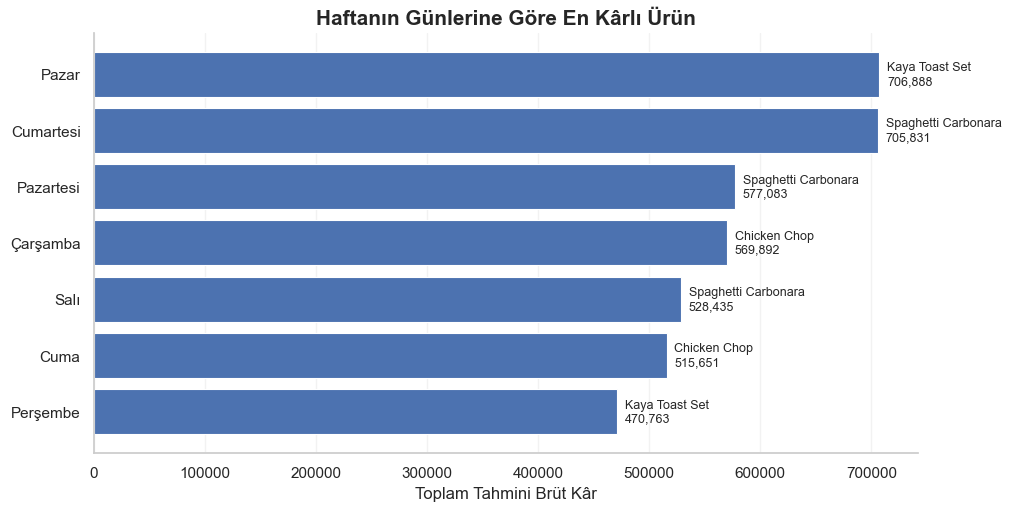

In [156]:
# ============================================================
# 9.6 GRAFİK
# ============================================================

fig, ax = plt.subplots(
    figsize=(10,5),
    constrained_layout=True
)

plot_data = top_profit_products.sort_values(
    "total_estimated_profit",
    ascending=True
)

bars = ax.barh(
    plot_data["day_name_tr"],
    plot_data["total_estimated_profit"],
    edgecolor="white",
    linewidth=.8
)

maximum = plot_data["total_estimated_profit"].max()

for bar, value, product in zip(
    bars,
    plot_data["total_estimated_profit"],
    plot_data["menu_item_name"]
):
    ax.text(
        value + maximum*0.01,
        bar.get_y()+bar.get_height()/2,
        f"{product}\n{value:,.0f}",
        va="center",
        fontsize=9
    )

ax.set_title(
    "Haftanın Günlerine Göre En Kârlı Ürün",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Toplam Tahmini Brüt Kâr")

ax.grid(axis="x", alpha=.25)
ax.grid(axis="y", visible=False)

sns.despine()

plt.show()

### Değerlendirme

Haftanın günleri ürün bazında incelendiğinde, en yüksek toplam tahmini brüt kârı sağlayan ürünlerin günlere göre farklılaştığı görülmektedir.

- **Pazartesi** günü en yüksek toplam tahmini brüt kârı yaklaşık **577.083** ile *Spaghetti Carbonara* sağlamıştır.
- **Salı** günü en kârlı ürün yaklaşık **528.435** toplam tahmini brüt kâr ile yine *Spaghetti Carbonara* olmuştur.
- **Çarşamba** günü yaklaşık **569.892** toplam tahmini brüt kâr ile *Chicken Chop* öne çıkmıştır.
- **Perşembe** günü en yüksek kâr sağlayan ürün yaklaşık **470.763** ile *Kaya Toast Set* olmuştur.
- **Cuma** günü yaklaşık **515.651** toplam tahmini brüt kâr ile *Chicken Chop* ilk sırada yer almıştır.
- **Cumartesi** günü yaklaşık **705.831** toplam tahmini brüt kâr ile *Spaghetti Carbonara* en yüksek performansı göstermiştir.
- **Pazar** günü ise yaklaşık **706.888** toplam tahmini brüt kâr ile *Kaya Toast Set* en kârlı ürün olmuştur.

Sonuçlar, hafta boyunca tek bir ürünün sürekli olarak en yüksek kârı sağlamadığını göstermektedir. *Spaghetti Carbonara* pazartesi, salı ve cumartesi günlerinde; *Chicken Chop* çarşamba ve cuma günlerinde; *Kaya Toast Set* ise perşembe ve pazar günlerinde öne çıkmaktadır.

Hafta sonundaki toplam tahmini kâr değerlerinin hafta içindeki değerlere göre daha yüksek olması, hafta sonu artan satış hacminin ürün bazındaki toplam kârlılığa yansıdığını göstermektedir. Bununla birlikte toplam kâr yalnızca birim kâra değil, ürünün satış miktarına da bağlıdır. Bu nedenle ürün performansı değerlendirilirken toplam tahmini kâr, ortalama birim kâr, kâr marjı ve satış miktarı birlikte ele alınmalıdır.

Bu bulgular, karar destek sisteminin gün bazında ürün önerisi üretmesine katkı sağlayabilir. Sistem; ilgili günde yüksek satış ve kâr potansiyeli bulunan ürünlerin stok seviyesinin artırılması, menüde daha görünür hâle getirilmesi ve uygun ürünlere yönelik promosyon stratejilerinin geliştirilmesi için kullanılabilir.

# MODELLER

In [160]:
# ============================================================
# 10. SATIŞ TALEBİ TAHMİN MODELİ
# 10.1 GEREKLİ KÜTÜPHANELER
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [162]:
# ============================================================
# 10.2 MODELLEME VERİSİNİN HAZIRLANMASI
# ============================================================

model_data = sales_data.copy()

# Tarih değişkenini datetime formatına dönüştür
model_data["date"] = pd.to_datetime(
    model_data["date"],
    errors="coerce"
)

# Tarihten yeni değişkenler üret
model_data["year"] = model_data["date"].dt.year
model_data["month"] = model_data["date"].dt.month
model_data["day_of_month"] = model_data["date"].dt.day
model_data["day_of_week"] = model_data["date"].dt.dayofweek
model_data["week_of_year"] = model_data["date"].dt.isocalendar().week.astype(int)
model_data["is_weekend"] = (
    model_data["day_of_week"] >= 5
).astype(int)

# Döngüsel zaman dönüşümleri
model_data["day_sin"] = np.sin(
    2 * np.pi * model_data["day_of_week"] / 7
)

model_data["day_cos"] = np.cos(
    2 * np.pi * model_data["day_of_week"] / 7
)

model_data["month_sin"] = np.sin(
    2 * np.pi * model_data["month"] / 12
)

model_data["month_cos"] = np.cos(
    2 * np.pi * model_data["month"] / 12
)

print("Model veri seti boyutu:", model_data.shape)
print("Başlangıç tarihi:", model_data["date"].min())
print("Bitiş tarihi:", model_data["date"].max())

model_data.head()

Model veri seti boyutu: (10000, 36)
Başlangıç tarihi: 2024-01-01 00:00:00
Bitiş tarihi: 2025-01-01 00:00:00


,date,restaurant_id,restaurant_type,menu_item_name,meal_type,key_ingredients_tags,typical_ingredient_cost,observed_market_price,actual_selling_price,quantity_sold,has_promotion,special_event,weather_condition,unit_profit,unit_profit_margin,revenue,estimated_total_cost,estimated_profit,price_difference,price_difference_pct,price_position,unit_profit_margin_pct,day_of_week,month,month_number,day_of_month,is_weekend,day_name_tr,month_name_tr,weekend_status,year,week_of_year,day_sin,day_cos,month_sin,month_cos
0,2024-01-01,11,Food Stall,Laksa,Lunch,"rice noodles, fish broth, tamarind, shrimp pas...",4.50,10.59,12.48,361,False,False,Sunny,7.98,0.64,"4,505.28","1,624.50","2,880.78",1.89,17.85,Piyasanın Üzerinde,63.94,0,1,1,1,0,Pazartesi,Ocak,Hafta İçi,2024,1,0.00,1.00,0.50,0.87
1,2024-01-01,7,Casual Dining,Spaghetti Carbonara,Dinner,"spaghetti, eggs, cheese, beef bacon, black pepper",9.00,26.64,60.46,105,False,False,Sunny,51.46,0.85,"6,348.30",945.00,"5,403.30",33.82,126.95,Piyasanın Üzerinde,85.11,0,1,1,1,0,Pazartesi,Ocak,Hafta İçi,2024,1,0.00,1.00,0.50,0.87
2,2024-01-01,23,Fine Dining,Beef Rendang,Dinner,"beef, coconut milk, galangal, lemongrass, spic...",9.00,49.42,80.15,36,False,False,Rainy,71.15,0.89,"2,885.40",324.00,"2,561.40",30.73,62.18,Piyasanın Üzerinde,88.77,0,1,1,1,0,Pazartesi,Ocak,Hafta İçi,2024,1,0.00,1.00,0.50,0.87
3,2024-01-01,22,Food Stall,Roti Canai,Dinner,"flour, ghee, egg, water, curry",0.80,2.04,2.48,503,False,False,Sunny,1.68,0.68,"1,247.44",402.40,845.04,0.44,21.57,Piyasanın Üzerinde,67.74,0,1,1,1,0,Pazartesi,Ocak,Hafta İçi,2024,1,0.00,1.00,0.50,0.87
4,2024-01-01,32,Fine Dining,Spaghetti Carbonara,Lunch,"spaghetti, eggs, cheese, beef bacon, black pepper",9.00,40.30,55.54,262,False,False,Rainy,46.54,0.84,"14,551.48","2,358.00","12,193.48",15.24,37.82,Piyasanın Üzerinde,83.80,0,1,1,1,0,Pazartesi,Ocak,Hafta İçi,2024,1,0.00,1.00,0.50,0.87


In [164]:
# ============================================================
# 10.3 MODEL DEĞİŞKENLERİNİN BELİRLENMESİ
# ============================================================

target_column = "quantity_sold"

categorical_features = [
    "restaurant_id",
    "restaurant_type",
    "menu_item_name",
    "meal_type",
    "key_ingredients_tags",
    "has_promotion",
    "special_event",
    "weather_condition"
]

numeric_features = [
    "typical_ingredient_cost",
    "observed_market_price",
    "actual_selling_price",
    "year",
    "month",
    "day_of_month",
    "day_of_week",
    "week_of_year",
    "is_weekend",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos"
]

feature_columns = categorical_features + numeric_features

model_data = (
    model_data[
        ["date"] + feature_columns + [target_column]
    ]
    .dropna(subset=["date", target_column])
    .sort_values("date")
    .reset_index(drop=True)
)

print("Kullanılan gözlem sayısı:", len(model_data))
print("Bağımsız değişken sayısı:", len(feature_columns))
print("Hedef değişken:", target_column)

model_data.head()

Kullanılan gözlem sayısı: 10000
Bağımsız değişken sayısı: 21
Hedef değişken: quantity_sold


,date,restaurant_id,restaurant_type,menu_item_name,meal_type,key_ingredients_tags,has_promotion,special_event,weather_condition,typical_ingredient_cost,observed_market_price,actual_selling_price,year,month,day_of_month,day_of_week,week_of_year,is_weekend,day_sin,day_cos,month_sin,month_cos,quantity_sold
0,2024-01-01,11,Food Stall,Laksa,Lunch,"rice noodles, fish broth, tamarind, shrimp pas...",False,False,Sunny,4.50,10.59,12.48,2024,1,1,0,1,0,0.00,1.00,0.50,0.87,361
1,2024-01-01,42,Fine Dining,Spaghetti Carbonara,Dinner,"spaghetti, eggs, cheese, beef bacon, black pepper",False,False,Sunny,9.00,40.64,56.82,2024,1,1,0,1,0,0.00,1.00,0.50,0.87,143
2,2024-01-01,5,Cafe,Mushroom Soup,Dinner,"mushrooms, cream, onion, garlic, vegetable broth",False,True,Cloudy,3.50,12.68,19.43,2024,1,1,0,1,0,0.00,1.00,0.50,0.87,73
3,2024-01-01,27,Food Stall,Tandoori Chicken,Dinner,"chicken, yogurt, tandoori masala, ginger, garlic",True,False,Cloudy,7.00,15.68,14.60,2024,1,1,0,1,0,0.00,1.00,0.50,0.87,410
4,2024-01-01,28,Fine Dining,Nasi Lemak,Breakfast,"rice, coconut milk, sambal, anchovies, egg, pe...",False,False,Sunny,2.50,11.92,16.75,2024,1,1,0,1,0,0.00,1.00,0.50,0.87,315


In [166]:
# ============================================================
# 10.4 VERİ TİPLERİNİN DÜZENLENMESİ
# ============================================================

for column in categorical_features:
    model_data[column] = (
        model_data[column]
        .fillna("Bilinmiyor")
        .astype(str)
    )

for column in numeric_features:
    model_data[column] = pd.to_numeric(
        model_data[column],
        errors="coerce"
    )

# Sayısal sütunlardaki eksikleri medyan ile doldur
for column in numeric_features:
    model_data[column] = model_data[column].fillna(
        model_data[column].median()
    )

print("Toplam eksik değer sayısı:")
print(model_data[feature_columns + [target_column]].isna().sum().sum())

model_data[feature_columns + [target_column]].dtypes

Toplam eksik değer sayısı:
0


restaurant_id               object
restaurant_type             object
menu_item_name              object
meal_type                   object
key_ingredients_tags        object
has_promotion               object
special_event               object
weather_condition           object
typical_ingredient_cost    float64
observed_market_price      float64
actual_selling_price       float64
year                         int32
month                        int32
day_of_month                 int32
day_of_week                  int32
week_of_year                 int64
is_weekend                   int64
day_sin                    float64
day_cos                    float64
month_sin                  float64
month_cos                  float64
quantity_sold                int64
dtype: object

In [168]:
# ============================================================
# 10.5 TARİH BAZLI TRAIN-VALIDATION-TEST AYRIMI
# ============================================================

unique_dates = np.array(
    sorted(model_data["date"].unique())
)

n_dates = len(unique_dates)

train_end_index = int(n_dates * 0.70)
validation_end_index = int(n_dates * 0.85)

train_dates = unique_dates[:train_end_index]
validation_dates = unique_dates[
    train_end_index:validation_end_index
]
test_dates = unique_dates[validation_end_index:]

train_data = model_data[
    model_data["date"].isin(train_dates)
].copy()

validation_data = model_data[
    model_data["date"].isin(validation_dates)
].copy()

test_data = model_data[
    model_data["date"].isin(test_dates)
].copy()

X_train = train_data[feature_columns].copy()
y_train = train_data[target_column].copy()

X_validation = validation_data[feature_columns].copy()
y_validation = validation_data[target_column].copy()

X_test = test_data[feature_columns].copy()
y_test = test_data[target_column].copy()

print("Toplam benzersiz tarih:", n_dates)
print()

print("Eğitim seti:")
print("Gözlem sayısı:", len(train_data))
print(
    "Tarih aralığı:",
    train_data["date"].min(),
    "-",
    train_data["date"].max()
)

print("\nDoğrulama seti:")
print("Gözlem sayısı:", len(validation_data))
print(
    "Tarih aralığı:",
    validation_data["date"].min(),
    "-",
    validation_data["date"].max()
)

print("\nTest seti:")
print("Gözlem sayısı:", len(test_data))
print(
    "Tarih aralığı:",
    test_data["date"].min(),
    "-",
    test_data["date"].max()
)

Toplam benzersiz tarih: 367

Eğitim seti:
Gözlem sayısı: 6959
Tarih aralığı: 2024-01-01 00:00:00 - 2024-09-12 00:00:00

Doğrulama seti:
Gözlem sayısı: 1519
Tarih aralığı: 2024-09-13 00:00:00 - 2024-11-06 00:00:00

Test seti:
Gözlem sayısı: 1522
Tarih aralığı: 2024-11-07 00:00:00 - 2025-01-01 00:00:00


In [170]:
# ============================================================
# 10.6 VERİ SETLERİNDE TARİH ÇAKIŞMASI KONTROLÜ
# ============================================================

train_validation_overlap = set(train_dates).intersection(
    set(validation_dates)
)

train_test_overlap = set(train_dates).intersection(
    set(test_dates)
)

validation_test_overlap = set(validation_dates).intersection(
    set(test_dates)
)

print(
    "Train-Validation tarih çakışması:",
    len(train_validation_overlap)
)

print(
    "Train-Test tarih çakışması:",
    len(train_test_overlap)
)

print(
    "Validation-Test tarih çakışması:",
    len(validation_test_overlap)
)

Train-Validation tarih çakışması: 0
Train-Test tarih çakışması: 0
Validation-Test tarih çakışması: 0


In [174]:
# ============================================================
# 10.7 MODEL DEĞERLENDİRME FONKSİYONU
# ============================================================

def evaluate_regression_model(
    y_true,
    y_pred,
    model_name,
    dataset_name
):
    """
    Regresyon modelinin temel performans metriklerini hesaplar.
    """

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )
    r2 = r2_score(y_true, y_pred)

    # Sıfır gerçek değerler MAPE hesabında sorun çıkarır
    non_zero_mask = y_true != 0

    if non_zero_mask.sum() > 0:
        mape = np.mean(
            np.abs(
                (
                    y_true[non_zero_mask]
                    - y_pred[non_zero_mask]
                )
                / y_true[non_zero_mask]
            )
        ) * 100
    else:
        mape = np.nan

    results = pd.DataFrame({
        "Model": [model_name],
        "Veri Seti": [dataset_name],
        "MAE": [mae],
        "RMSE": [rmse],
        "MAPE (%)": [mape],
        "R2": [r2]
    })

    return results.round(4)

In [176]:
# ============================================================
# 10.8 BASELINE MODEL
# ============================================================

baseline_model = DummyRegressor(
    strategy="mean"
)

# DummyRegressor kategorik değişkenleri kullanmasa da
# yalnızca satır sayısına ihtiyaç duyar
baseline_model.fit(
    np.zeros((len(X_train), 1)),
    y_train
)

baseline_validation_predictions = baseline_model.predict(
    np.zeros((len(X_validation), 1))
)

baseline_test_predictions = baseline_model.predict(
    np.zeros((len(X_test), 1))
)

baseline_validation_results = evaluate_regression_model(
    y_true=y_validation.reset_index(drop=True),
    y_pred=baseline_validation_predictions,
    model_name="Baseline - Ortalama",
    dataset_name="Validation"
)

baseline_test_results = evaluate_regression_model(
    y_true=y_test.reset_index(drop=True),
    y_pred=baseline_test_predictions,
    model_name="Baseline - Ortalama",
    dataset_name="Test"
)

baseline_results = pd.concat(
    [
        baseline_validation_results,
        baseline_test_results
    ],
    ignore_index=True
)

baseline_results

,Model,Veri Seti,MAE,RMSE,MAPE (%),R2
0,Baseline - Ortalama,Validation,166.01,214.95,174.89,-0.00
1,Baseline - Ortalama,Test,169.80,224.09,203.55,-0.00


In [178]:
# CatBoost bilgisayarda yüklü değilse çalıştır
%pip install catboost


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [180]:
pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 1.3 MB/s  0:00:01 eta 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 25.2
    Uninstalling pip-25.2:
      Successfully uninstalled pip-25.2
Note: you may need to restart the kernel to use updated packages.


In [182]:
# ============================================================
# 10.10 CATBOOST REGRESYON MODELİ
# ============================================================

from catboost import CatBoostRegressor

catboost_model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    l2_leaf_reg=5,
    random_strength=1,
    subsample=0.8,
    verbose=100,
    allow_writing_files=False
)

catboost_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_validation, y_validation),
    early_stopping_rounds=150,
    verbose=100
)

0:	learn: 212.0912813	test: 211.8273824	best: 211.8273824 (0)	total: 64.6ms	remaining: 1m 36s
100:	learn: 101.4694993	test: 98.5618319	best: 98.5618319 (100)	total: 356ms	remaining: 4.93s
200:	learn: 93.2236589	test: 95.8914971	best: 95.8607004 (199)	total: 678ms	remaining: 4.38s
300:	learn: 88.2746804	test: 94.8952864	best: 94.8952864 (300)	total: 1s	remaining: 4s
400:	learn: 83.1454630	test: 93.5872492	best: 93.5846339 (398)	total: 1.33s	remaining: 3.63s
500:	learn: 79.5077205	test: 92.8282963	best: 92.8049340 (497)	total: 1.63s	remaining: 3.25s
600:	learn: 76.3868874	test: 92.5755372	best: 92.5475022 (537)	total: 1.94s	remaining: 2.9s
700:	learn: 73.8726544	test: 92.3902430	best: 92.3739830 (693)	total: 2.23s	remaining: 2.54s
800:	learn: 71.8322728	test: 92.2281287	best: 92.2106387 (763)	total: 2.52s	remaining: 2.2s
900:	learn: 69.7565340	test: 91.9103876	best: 91.9103876 (900)	total: 2.82s	remaining: 1.87s
1000:	learn: 67.8301484	test: 91.9734207	best: 91.9103876 (900)	total: 3.11s

CatBoostRegressor(allow_writing_files=False, depth=8, eval_metric='RMSE', iterations=1500, l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', random_seed=42, random_strength=1, subsample=0.8, verbose=100)

In [184]:
# ============================================================
# 10.11 CATBOOST TAHMİNLERİ
# ============================================================

catboost_validation_predictions = catboost_model.predict(
    X_validation
)

catboost_test_predictions = catboost_model.predict(
    X_test
)

# Satış miktarı negatif olamayacağı için
# negatif tahminleri sıfıra eşitle
catboost_validation_predictions = np.clip(
    catboost_validation_predictions,
    a_min=0,
    a_max=None
)

catboost_test_predictions = np.clip(
    catboost_test_predictions,
    a_min=0,
    a_max=None
)

In [186]:
# ============================================================
# 10.12 CATBOOST MODEL SONUÇLARI
# ============================================================

catboost_validation_results = evaluate_regression_model(
    y_true=y_validation.reset_index(drop=True),
    y_pred=catboost_validation_predictions,
    model_name="CatBoost",
    dataset_name="Validation"
)

catboost_test_results = evaluate_regression_model(
    y_true=y_test.reset_index(drop=True),
    y_pred=catboost_test_predictions,
    model_name="CatBoost",
    dataset_name="Test"
)

model_results = pd.concat(
    [
        baseline_results,
        catboost_validation_results,
        catboost_test_results
    ],
    ignore_index=True
)

model_results

,Model,Veri Seti,MAE,RMSE,MAPE (%),R2
0,Baseline - Ortalama,Validation,166.01,214.95,174.89,-0.00
1,Baseline - Ortalama,Test,169.80,224.09,203.55,-0.00
2,CatBoost,Validation,71.87,91.91,65.78,0.82
3,CatBoost,Test,73.56,100.32,68.82,0.80


In [188]:
# ============================================================
# 10.13 TEST TAHMİNLERİNİN İNCELENMESİ
# ============================================================

test_predictions_table = test_data[
    [
        "date",
        "restaurant_id",
        "menu_item_name",
        "meal_type",
        "has_promotion",
        "weather_condition",
        "actual_selling_price",
        "quantity_sold"
    ]
].copy()

test_predictions_table["predicted_quantity_sold"] = (
    catboost_test_predictions
)

test_predictions_table["absolute_error"] = np.abs(
    test_predictions_table["quantity_sold"]
    - test_predictions_table["predicted_quantity_sold"]
)

test_predictions_table["percentage_error"] = np.where(
    test_predictions_table["quantity_sold"] != 0,
    (
        test_predictions_table["absolute_error"]
        / test_predictions_table["quantity_sold"]
    ) * 100,
    np.nan
)

test_predictions_table[
    [
        "quantity_sold",
        "predicted_quantity_sold",
        "absolute_error",
        "percentage_error"
    ]
] = test_predictions_table[
    [
        "quantity_sold",
        "predicted_quantity_sold",
        "absolute_error",
        "percentage_error"
    ]
].round(2)

test_predictions_table.head(20)

,date,restaurant_id,menu_item_name,meal_type,has_promotion,weather_condition,actual_selling_price,quantity_sold,predicted_quantity_sold,absolute_error,percentage_error
8478,2024-11-07,2,Roti Canai,Dinner,False,Sunny,2.72,269,251.82,17.18,6.38
8479,2024-11-07,21,Chicken Chop,Dinner,True,Cloudy,27.69,294,200.64,93.36,31.76
8480,2024-11-07,30,Nasi Lemak,Breakfast,False,Sunny,9.78,373,310.81,62.19,16.67
8481,2024-11-07,35,Cendol,Dinner,False,Rainy,8.03,162,154.64,7.36,4.54
8482,2024-11-07,33,Iced Lemon Tea,Lunch,False,Cloudy,5.63,332,262.36,69.64,20.98
8483,2024-11-07,14,Cendol,Dinner,False,Sunny,6.54,191,258.35,67.35,35.26
8484,2024-11-07,14,Cendol,Dinner,False,Sunny,6.31,298,262.92,35.08,11.77
8485,2024-11-07,3,Teh Tarik,Dinner,False,Cloudy,3.32,397,328.49,68.51,17.26
8486,2024-11-07,36,Roti Canai,Breakfast,False,Sunny,2.33,385,401.28,16.28,4.23
8487,2024-11-07,48,Kaya Toast Set,Breakfast,False,Rainy,11.20,497,339.96,157.04,31.60


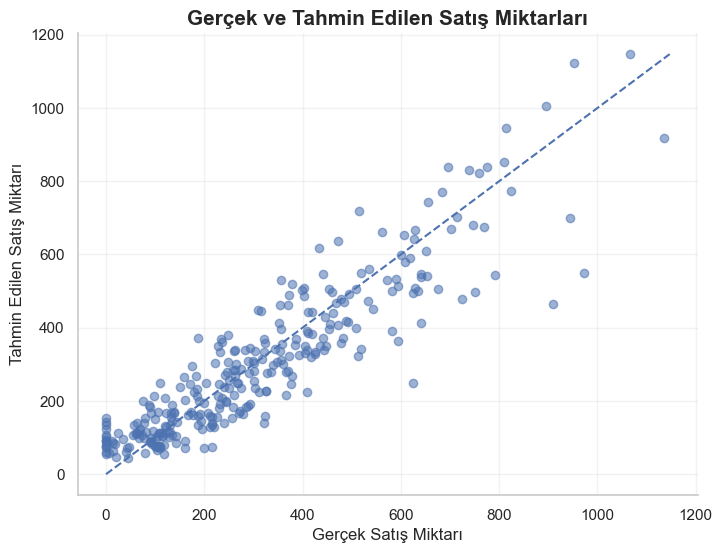

In [190]:
# ============================================================
# 10.14 GERÇEK VE TAHMİN EDİLEN SATIŞLAR
# ============================================================

plot_sample = test_predictions_table.sample(
    n=min(300, len(test_predictions_table)),
    random_state=42
)

plt.figure(figsize=(8, 6))

plt.scatter(
    plot_sample["quantity_sold"],
    plot_sample["predicted_quantity_sold"],
    alpha=0.55
)

minimum_value = min(
    plot_sample["quantity_sold"].min(),
    plot_sample["predicted_quantity_sold"].min()
)

maximum_value = max(
    plot_sample["quantity_sold"].max(),
    plot_sample["predicted_quantity_sold"].max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "Gerçek ve Tahmin Edilen Satış Miktarları",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Gerçek Satış Miktarı")
plt.ylabel("Tahmin Edilen Satış Miktarı")

plt.grid(alpha=0.25)
sns.despine()
plt.show()

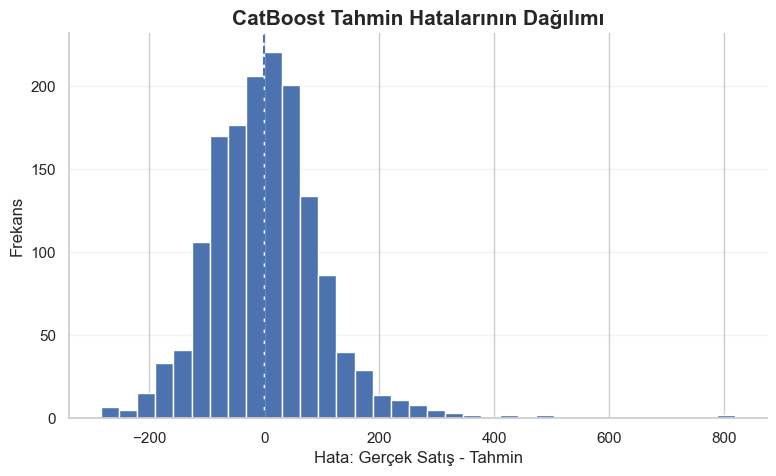

In [192]:
# ============================================================
# 10.15 TAHMİN HATALARININ DAĞILIMI
# ============================================================

residuals = (
    y_test.reset_index(drop=True)
    - catboost_test_predictions
)

plt.figure(figsize=(9, 5))

plt.hist(
    residuals,
    bins=35,
    edgecolor="white"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "CatBoost Tahmin Hatalarının Dağılımı",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Hata: Gerçek Satış - Tahmin")
plt.ylabel("Frekans")

plt.grid(axis="y", alpha=0.25)
sns.despine()
plt.show()

In [194]:
# ============================================================
# 10.16 DEĞİŞKEN ÖNEMLERİ
# ============================================================

feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": catboost_model.get_feature_importance()
})

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance

,feature,importance
0,has_promotion,25.49
1,key_ingredients_tags,17.06
2,actual_selling_price,8.80
3,day_sin,5.43
4,menu_item_name,5.13
5,meal_type,4.86
6,day_of_month,4.64
7,day_of_week,4.17
8,typical_ingredient_cost,4.11
9,observed_market_price,4.04


### Model Performansının Değerlendirilmesi

Satış miktarını tahmin etmek amacıyla öncelikle eğitim setindeki ortalama satış değerini kullanan bir referans model oluşturulmuş, ardından kategorik ve sayısal değişkenleri birlikte değerlendirebilen CatBoost regresyon modeli eğitilmiştir. Veri seti zamansal yapısı korunarak eğitim, doğrulama ve test kümelerine ayrılmış; aynı tarihe ait kayıtların farklı veri kümelerinde yer almaması sağlanmıştır.

Referans model test kümesinde 169,80 MAE ve 224,09 RMSE değerleri üretirken, CatBoost modeli bu değerleri sırasıyla 73,56 ve 100,32 seviyesine düşürmüştür. Böylece CatBoost modeli, referans modele kıyasla ortalama mutlak hatayı yaklaşık %57 ve hata kareleri ortalamasının karekökünü yaklaşık %55 oranında azaltmıştır.

CatBoost modelinin açıklayıcılık düzeyi doğrulama kümesinde 0,82, test kümesinde ise 0,80 olarak hesaplanmıştır. Doğrulama ve test sonuçlarının birbirine yakın olması, modelin yalnızca eğitim verisini ezberlemediğini ve daha önce görmediği zaman dönemlerine de büyük ölçüde genellenebildiğini göstermektedir.

Test kümesindeki MAE değeri, model tahminlerinin gerçek satış miktarından ortalama yaklaşık 74 adet saptığını göstermektedir. RMSE değerinin MAE değerinden daha yüksek olması ise bazı kayıtlarda daha büyük tahmin hatalarının bulunduğuna işaret etmektedir.

MAPE değeri yaklaşık %68,82 olmakla birlikte, veri setinde sıfır veya düşük satış değerleri bulunduğundan bu metrik tek başına yanıltıcı olabilir. Bu nedenle model başarısının değerlendirilmesinde MAE, RMSE ve R² ölçütleri öncelikli olarak dikkate alınmıştır.

Genel olarak ilk CatBoost modeli, referans modele göre belirgin bir performans artışı sağlamış ve talep tahmini agent'ının temel tahmin modeli olarak kullanılabilecek başarılı bir başlangıç modeli ortaya koymuştur.

### Tahmin Sonuçları, Hata Yapısı ve Değişken Önemlerinin Değerlendirilmesi

Gerçek ve tahmin edilen satış miktarları karşılaştırıldığında gözlemlerin büyük bölümünün referans çizgisi çevresinde toplandığı görülmektedir. Bu durum, CatBoost modelinin satış miktarındaki genel değişimi başarılı biçimde yakaladığını desteklemektedir. Özellikle düşük ve orta satış düzeylerinde tahminler gerçek değerlere daha yakınken, yüksek satış miktarlarında tahminlerin saçılımı artmaktadır. Dolayısıyla modelin yüksek talep görülen kayıtları tahmin ederken daha yüksek hata üretebildiği söylenebilir.

Tahmin hatalarının dağılımı büyük ölçüde sıfır çevresinde yoğunlaşmaktadır. Bu bulgu, modelin genel olarak sürekli fazla ya da sürekli düşük tahmin yapan belirgin bir yönlü yanlılığa sahip olmadığını göstermektedir. Bununla birlikte hata dağılımının pozitif yönde daha uzun bir kuyruğa sahip olması, bazı yüksek satış kayıtlarının model tarafından olduğundan düşük tahmin edildiğini göstermektedir. Bu kayıtların ayrıca incelenmesi, yüksek talep dönemlerini açıklayan değişkenlerin güçlendirilmesine yardımcı olabilir.

Değişken önemleri incelendiğinde satış tahmininde en belirleyici değişkenin promosyon durumu olduğu görülmektedir. Promosyon bilgisini ürünün temel içerik etiketleri, gerçek satış fiyatı, ürün adı, öğün türü ve zaman değişkenleri izlemektedir. Bu sonuçlar, satış talebinin yalnızca fiyat üzerinden değil; kampanya durumu, ürün yapısı ve tüketim zamanı gibi birden fazla faktörün birlikte etkisiyle oluştuğunu göstermektedir.

Hava durumu ve restoran türü de modele katkı sağlamakla birlikte, önem düzeyleri promosyon ve ürün özelliklerine göre daha düşüktür. Yıl değişkeninin öneminin sıfır olması ise veri setinin yalnızca tek yıllık bir dönemi kapsamasından kaynaklanmaktadır.

Genel olarak CatBoost modeli satış talebindeki temel örüntüleri başarılı biçimde öğrenmiştir. Ancak yüksek satış miktarlarında hata düzeyinin artması, modelin özellikle yoğun talep dönemleri için geliştirilebileceğini göstermektedir. Bir sonraki aşamada hata analizi, alternatif modeller ve özellik geliştirme çalışmalarıyla tahmin performansı karşılaştırılacaktır.

In [197]:
# =========================================================
# 10.17 LIGHTGBM KURULUMU VE KÜTÜPHANELER
# =========================================================

%pip install lightgbm -q

import lightgbm as lgb
from lightgbm import LGBMRegressor

Note: you may need to restart the kernel to use updated packages.


In [199]:
# =========================================================
# 10.18 LIGHTGBM VERİ SETLERİNİN HAZIRLANMASI
# =========================================================

X_train_lgb = X_train.copy()
X_validation_lgb = X_validation.copy()
X_test_lgb = X_test.copy()

# Kategorik değişkenleri LightGBM için category tipine dönüştür
for column in categorical_features:
    X_train_lgb[column] = X_train_lgb[column].astype("category")

    # Validation ve test kategorilerini eğitim setiyle aynı seviyelere getir
    X_validation_lgb[column] = pd.Categorical(
        X_validation_lgb[column],
        categories=X_train_lgb[column].cat.categories
    )

    X_test_lgb[column] = pd.Categorical(
        X_test_lgb[column],
        categories=X_train_lgb[column].cat.categories
    )

print("LightGBM eğitim seti boyutu:", X_train_lgb.shape)
print("LightGBM doğrulama seti boyutu:", X_validation_lgb.shape)
print("LightGBM test seti boyutu:", X_test_lgb.shape)

print("\nKategorik değişken tipleri:")
print(X_train_lgb[categorical_features].dtypes)

LightGBM eğitim seti boyutu: (6959, 21)
LightGBM doğrulama seti boyutu: (1519, 21)
LightGBM test seti boyutu: (1522, 21)

Kategorik değişken tipleri:
restaurant_id           category
restaurant_type         category
menu_item_name          category
meal_type               category
key_ingredients_tags    category
has_promotion           category
special_event           category
weather_condition       category
dtype: object


In [201]:
# =========================================================
# 10.19 LIGHTGBM MODELİNİN OLUŞTURULMASI
# =========================================================

lightgbm_model = LGBMRegressor(
    objective="regression",
    n_estimators=3000,
    learning_rate=0.02,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.10,
    reg_lambda=0.50,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lightgbm_model

LGBMRegressor(colsample_bytree=0.85, learning_rate=0.02, min_child_samples=30,
              n_estimators=3000, n_jobs=-1, objective='regression',
              random_state=42, reg_alpha=0.1, reg_lambda=0.5, subsample=0.85,
              verbosity=-1)

In [203]:
# =========================================================
# 10.20 LIGHTGBM MODELİNİN EĞİTİLMESİ
# =========================================================

lightgbm_model.fit(
    X_train_lgb,
    y_train,
    eval_set=[
        (X_train_lgb, y_train),
        (X_validation_lgb, y_validation)
    ],
    eval_names=[
        "Eğitim",
        "Doğrulama"
    ],
    eval_metric="rmse",
    categorical_feature=categorical_features,
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=150,
            verbose=True
        ),
        lgb.log_evaluation(period=100)
    ]
)

print("\nEn iyi iterasyon:", lightgbm_model.best_iteration_)
print(
    "En iyi doğrulama RMSE:",
    lightgbm_model.best_score_["Doğrulama"]["rmse"]
)

Training until validation scores don't improve for 150 rounds
[100]	Eğitim's rmse: 99.3703	Eğitim's l2: 9874.46	Doğrulama's rmse: 97.938	Doğrulama's l2: 9591.86
[200]	Eğitim's rmse: 84.6239	Eğitim's l2: 7161.2	Doğrulama's rmse: 91.7693	Doğrulama's l2: 8421.61
[300]	Eğitim's rmse: 77.991	Eğitim's l2: 6082.6	Doğrulama's rmse: 92.1072	Doğrulama's l2: 8483.74
Early stopping, best iteration is:
[228]	Eğitim's rmse: 82.5752	Eğitim's l2: 6818.66	Doğrulama's rmse: 91.7495	Doğrulama's l2: 8417.97

En iyi iterasyon: 228
En iyi doğrulama RMSE: 91.74951667579354


In [205]:
# =========================================================
# 10.21 LIGHTGBM TAHMİNLERİ
# =========================================================

lightgbm_validation_predictions = lightgbm_model.predict(
    X_validation_lgb,
    num_iteration=lightgbm_model.best_iteration_
)

lightgbm_test_predictions = lightgbm_model.predict(
    X_test_lgb,
    num_iteration=lightgbm_model.best_iteration_
)

# Satış miktarı negatif olamayacağı için negatif tahminleri sıfıra çek
lightgbm_validation_predictions = np.clip(
    lightgbm_validation_predictions,
    a_min=0,
    a_max=None
)

lightgbm_test_predictions = np.clip(
    lightgbm_test_predictions,
    a_min=0,
    a_max=None
)

print(
    "Validation tahmin sayısı:",
    len(lightgbm_validation_predictions)
)

print(
    "Test tahmin sayısı:",
    len(lightgbm_test_predictions)
)

Validation tahmin sayısı: 1519
Test tahmin sayısı: 1522


In [207]:
# =========================================================
# 10.22 LIGHTGBM PERFORMANS SONUÇLARI
# =========================================================

lightgbm_validation_results = evaluate_regression_model(
    y_true=y_validation.reset_index(drop=True),
    y_pred=lightgbm_validation_predictions,
    model_name="LightGBM",
    dataset_name="Validation"
)

lightgbm_test_results = evaluate_regression_model(
    y_true=y_test.reset_index(drop=True),
    y_pred=lightgbm_test_predictions,
    model_name="LightGBM",
    dataset_name="Test"
)

lightgbm_results = pd.concat(
    [
        lightgbm_validation_results,
        lightgbm_test_results
    ],
    ignore_index=True
)

lightgbm_results

,Model,Veri Seti,MAE,RMSE,MAPE (%),R2
0,LightGBM,Validation,72.32,91.75,66.30,0.82
1,LightGBM,Test,75.70,103.15,72.20,0.79


In [209]:
# =========================================================
# 10.23 TÜM MODELLERİN KARŞILAŞTIRILMASI
# =========================================================

all_model_results = pd.concat(
    [
        model_results,
        lightgbm_results
    ],
    ignore_index=True
)

all_model_results = (
    all_model_results
    .sort_values(
        ["Veri Seti", "RMSE"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

all_model_results

,Model,Veri Seti,MAE,RMSE,MAPE (%),R2
0,CatBoost,Test,73.56,100.32,68.82,0.80
1,LightGBM,Test,75.70,103.15,72.20,0.79
2,Baseline - Ortalama,Test,169.80,224.09,203.55,-0.00
3,LightGBM,Validation,72.32,91.75,66.30,0.82
4,CatBoost,Validation,71.87,91.91,65.78,0.82
5,Baseline - Ortalama,Validation,166.01,214.95,174.89,-0.00


In [211]:
# =========================================================
# 10.24 LIGHTGBM TEST TAHMİNLERİNİN İNCELENMESİ
# =========================================================

lightgbm_test_predictions_table = test_data[
    [
        "date",
        "restaurant_id",
        "restaurant_type",
        "menu_item_name",
        "meal_type",
        "has_promotion",
        "special_event",
        "weather_condition",
        "actual_selling_price",
        "quantity_sold"
    ]
].copy()

lightgbm_test_predictions_table["predicted_quantity_sold"] = (
    lightgbm_test_predictions
)

lightgbm_test_predictions_table["absolute_error"] = (
    lightgbm_test_predictions_table["quantity_sold"]
    - lightgbm_test_predictions_table["predicted_quantity_sold"]
).abs()

lightgbm_test_predictions_table["percentage_error"] = np.where(
    lightgbm_test_predictions_table["quantity_sold"] > 0,
    (
        lightgbm_test_predictions_table["absolute_error"]
        / lightgbm_test_predictions_table["quantity_sold"]
    ) * 100,
    np.nan
)

lightgbm_test_predictions_table[
    [
        "date",
        "restaurant_id",
        "menu_item_name",
        "meal_type",
        "has_promotion",
        "weather_condition",
        "quantity_sold",
        "predicted_quantity_sold",
        "absolute_error",
        "percentage_error"
    ]
].round(2).head(20)

,date,restaurant_id,menu_item_name,meal_type,has_promotion,weather_condition,quantity_sold,predicted_quantity_sold,absolute_error,percentage_error
8478,2024-11-07,2,Roti Canai,Dinner,False,Sunny,269,280.17,11.17,4.15
8479,2024-11-07,21,Chicken Chop,Dinner,True,Cloudy,294,236.55,57.45,19.54
8480,2024-11-07,30,Nasi Lemak,Breakfast,False,Sunny,373,290.48,82.52,22.12
8481,2024-11-07,35,Cendol,Dinner,False,Rainy,162,178.65,16.65,10.28
8482,2024-11-07,33,Iced Lemon Tea,Lunch,False,Cloudy,332,266.59,65.41,19.70
8483,2024-11-07,14,Cendol,Dinner,False,Sunny,191,274.94,83.94,43.95
8484,2024-11-07,14,Cendol,Dinner,False,Sunny,298,288.54,9.46,3.18
8485,2024-11-07,3,Teh Tarik,Dinner,False,Cloudy,397,366.56,30.44,7.67
8486,2024-11-07,36,Roti Canai,Breakfast,False,Sunny,385,414.27,29.27,7.60
8487,2024-11-07,48,Kaya Toast Set,Breakfast,False,Rainy,497,339.74,157.26,31.64


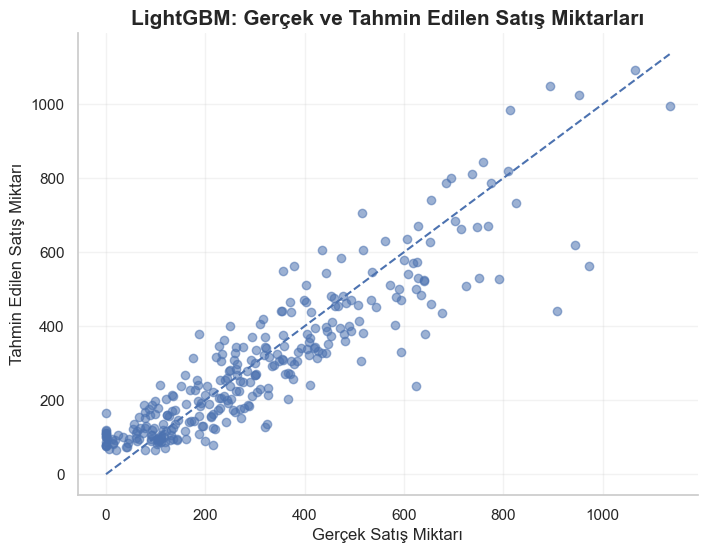

In [213]:
# =========================================================
# 10.25 LIGHTGBM GERÇEK VE TAHMİN EDİLEN SATIŞLAR
# =========================================================

plot_sample_lgb = lightgbm_test_predictions_table.sample(
    n=min(300, len(lightgbm_test_predictions_table)),
    random_state=42
)

plt.figure(figsize=(8, 6))

plt.scatter(
    plot_sample_lgb["quantity_sold"],
    plot_sample_lgb["predicted_quantity_sold"],
    alpha=0.55
)

minimum_value = min(
    plot_sample_lgb["quantity_sold"].min(),
    plot_sample_lgb["predicted_quantity_sold"].min()
)

maximum_value = max(
    plot_sample_lgb["quantity_sold"].max(),
    plot_sample_lgb["predicted_quantity_sold"].max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "LightGBM: Gerçek ve Tahmin Edilen Satış Miktarları",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Gerçek Satış Miktarı")
plt.ylabel("Tahmin Edilen Satış Miktarı")

plt.grid(alpha=0.25)
sns.despine()
plt.show()

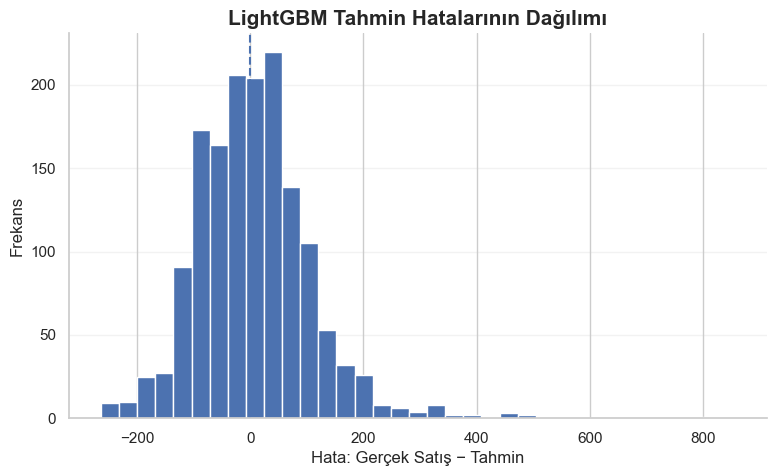

In [215]:
# =========================================================
# 10.26 LIGHTGBM TAHMİN HATALARININ DAĞILIMI
# =========================================================

lightgbm_residuals = (
    y_test.reset_index(drop=True)
    - lightgbm_test_predictions
)

plt.figure(figsize=(9, 5))

plt.hist(
    lightgbm_residuals,
    bins=35,
    edgecolor="white"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "LightGBM Tahmin Hatalarının Dağılımı",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Hata: Gerçek Satış − Tahmin")
plt.ylabel("Frekans")

plt.grid(axis="y", alpha=0.25)
sns.despine()
plt.show()

In [217]:
# =========================================================
# 10.27 LIGHTGBM DEĞİŞKEN ÖNEMLERİ
# =========================================================

lightgbm_feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": lightgbm_model.feature_importances_
})

lightgbm_feature_importance = (
    lightgbm_feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

lightgbm_feature_importance

,feature,importance
0,actual_selling_price,1475
1,restaurant_id,747
2,observed_market_price,609
3,day_of_week,589
4,day_of_month,476
5,menu_item_name,465
6,meal_type,448
7,weather_condition,445
8,has_promotion,334
9,typical_ingredient_cost,281


In [219]:
# =========================================================
# 10.28 XGBOOST KURULUMU VE KÜTÜPHANELER
# =========================================================

%pip install xgboost -q

from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

Note: you may need to restart the kernel to use updated packages.


In [221]:
# =========================================================
# 10.29 XGBOOST İÇİN ÖN İŞLEME
# =========================================================

xgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ],
    remainder="drop"
)

print("Kategorik değişken sayısı:", len(categorical_features))
print("Sayısal değişken sayısı:", len(numeric_features))

Kategorik değişken sayısı: 8
Sayısal değişken sayısı: 13


In [223]:
# =========================================================
# 10.30 XGBOOST MODELİNİN OLUŞTURULMASI
# =========================================================

xgboost_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=2500,
    learning_rate=0.02,
    max_depth=7,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.10,
    reg_lambda=1.00,
    random_state=42,
    n_jobs=-1,
    eval_metric="rmse"
)

xgboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", xgb_preprocessor),
        ("model", xgboost_model)
    ]
)

xgboost_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['restaurant_id',
                                                   'restaurant_type',
                                                   'menu_item_name',
                                                   'meal_type',
                                                   'key_ingredients_tags',
                                                   'has_promotion',
                                                   'special_event',
                                                   'weather_condition']),
                                                 ('numeric', 'passthrough',
                                                  ['typical_ingredient_cost',
                                                   'observed_market_price',
                                                   'actual_selling...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.02,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=7, max_leaves=None, min_child_weight=5,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=2500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [225]:
# =========================================================
# 10.31 XGBOOST MODELİNİN EĞİTİLMESİ
# =========================================================

xgboost_pipeline.fit(
    X_train,
    y_train
)

print("XGBoost modeli başarıyla eğitildi.")

XGBoost modeli başarıyla eğitildi.


In [227]:
# =========================================================
# 10.32 XGBOOST TAHMİNLERİ
# =========================================================

xgboost_validation_predictions = xgboost_pipeline.predict(
    X_validation
)

xgboost_test_predictions = xgboost_pipeline.predict(
    X_test
)

# Satış miktarı negatif olamayacağı için negatif tahminleri sıfıra çek
xgboost_validation_predictions = np.clip(
    xgboost_validation_predictions,
    a_min=0,
    a_max=None
)

xgboost_test_predictions = np.clip(
    xgboost_test_predictions,
    a_min=0,
    a_max=None
)

print(
    "Validation tahmin sayısı:",
    len(xgboost_validation_predictions)
)

print(
    "Test tahmin sayısı:",
    len(xgboost_test_predictions)
)

Validation tahmin sayısı: 1519
Test tahmin sayısı: 1522


In [229]:
# =========================================================
# 10.33 XGBOOST PERFORMANS SONUÇLARI
# =========================================================

xgboost_validation_results = evaluate_regression_model(
    y_true=y_validation.reset_index(drop=True),
    y_pred=xgboost_validation_predictions,
    model_name="XGBoost",
    dataset_name="Validation"
)

xgboost_test_results = evaluate_regression_model(
    y_true=y_test.reset_index(drop=True),
    y_pred=xgboost_test_predictions,
    model_name="XGBoost",
    dataset_name="Test"
)

xgboost_results = pd.concat(
    [
        xgboost_validation_results,
        xgboost_test_results
    ],
    ignore_index=True
)

xgboost_results

,Model,Veri Seti,MAE,RMSE,MAPE (%),R2
0,XGBoost,Validation,74.79,96.35,66.95,0.80
1,XGBoost,Test,76.29,103.36,73.30,0.79


In [231]:
# =========================================================
# 10.34 TÜM MODELLERİN KARŞILAŞTIRILMASI
# =========================================================

all_model_results = pd.concat(
    [
        model_results,
        lightgbm_results,
        xgboost_results
    ],
    ignore_index=True
)

all_model_results = (
    all_model_results
    .sort_values(
        ["Veri Seti", "RMSE"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

all_model_results

,Model,Veri Seti,MAE,RMSE,MAPE (%),R2
0,CatBoost,Test,73.56,100.32,68.82,0.80
1,LightGBM,Test,75.70,103.15,72.20,0.79
2,XGBoost,Test,76.29,103.36,73.30,0.79
3,Baseline - Ortalama,Test,169.80,224.09,203.55,-0.00
4,LightGBM,Validation,72.32,91.75,66.30,0.82
5,CatBoost,Validation,71.87,91.91,65.78,0.82
6,XGBoost,Validation,74.79,96.35,66.95,0.80
7,Baseline - Ortalama,Validation,166.01,214.95,174.89,-0.00


In [233]:
# =========================================================
# 10.35 TEST SONUÇLARININ KARŞILAŞTIRILMASI
# =========================================================

test_model_comparison = (
    all_model_results[
        all_model_results["Veri Seti"] == "Test"
    ]
    .sort_values(
        "RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

test_model_comparison

,Model,Veri Seti,MAE,RMSE,MAPE (%),R2
0,CatBoost,Test,73.56,100.32,68.82,0.80
1,LightGBM,Test,75.70,103.15,72.20,0.79
2,XGBoost,Test,76.29,103.36,73.30,0.79
3,Baseline - Ortalama,Test,169.80,224.09,203.55,-0.00


In [235]:
# =========================================================
# 10.36 XGBOOST TEST TAHMİNLERİNİN İNCELENMESİ
# =========================================================

xgboost_test_predictions_table = test_data[
    [
        "date",
        "restaurant_id",
        "menu_item_name",
        "meal_type",
        "has_promotion",
        "weather_condition",
        "actual_selling_price",
        "quantity_sold"
    ]
].copy()

xgboost_test_predictions_table[
    "predicted_quantity_sold"
] = xgboost_test_predictions

xgboost_test_predictions_table["absolute_error"] = (
    xgboost_test_predictions_table["quantity_sold"]
    - xgboost_test_predictions_table["predicted_quantity_sold"]
).abs()

xgboost_test_predictions_table["percentage_error"] = np.where(
    xgboost_test_predictions_table["quantity_sold"] > 0,
    (
        xgboost_test_predictions_table["absolute_error"]
        / xgboost_test_predictions_table["quantity_sold"]
    ) * 100,
    np.nan
)

xgboost_test_predictions_table[
    [
        "quantity_sold",
        "predicted_quantity_sold",
        "absolute_error",
        "percentage_error"
    ]
] = xgboost_test_predictions_table[
    [
        "quantity_sold",
        "predicted_quantity_sold",
        "absolute_error",
        "percentage_error"
    ]
].round(2)

xgboost_test_predictions_table.head(20)

,date,restaurant_id,menu_item_name,meal_type,has_promotion,weather_condition,actual_selling_price,quantity_sold,predicted_quantity_sold,absolute_error,percentage_error
8478,2024-11-07,2,Roti Canai,Dinner,False,Sunny,2.72,269,312.39,43.39,16.13
8479,2024-11-07,21,Chicken Chop,Dinner,True,Cloudy,27.69,294,273.11,20.89,7.11
8480,2024-11-07,30,Nasi Lemak,Breakfast,False,Sunny,9.78,373,288.20,84.80,22.73
8481,2024-11-07,35,Cendol,Dinner,False,Rainy,8.03,162,120.55,41.45,25.59
8482,2024-11-07,33,Iced Lemon Tea,Lunch,False,Cloudy,5.63,332,261.91,70.09,21.11
8483,2024-11-07,14,Cendol,Dinner,False,Sunny,6.54,191,283.23,92.23,48.29
8484,2024-11-07,14,Cendol,Dinner,False,Sunny,6.31,298,262.68,35.32,11.85
8485,2024-11-07,3,Teh Tarik,Dinner,False,Cloudy,3.32,397,372.18,24.82,6.25
8486,2024-11-07,36,Roti Canai,Breakfast,False,Sunny,2.33,385,399.21,14.21,3.69
8487,2024-11-07,48,Kaya Toast Set,Breakfast,False,Rainy,11.20,497,387.19,109.81,22.09


In [237]:
# =========================================================
# 10.37 SHAP KÜTÜPHANESİNİN HAZIRLANMASI
# =========================================================

# SHAP yüklü değilse aşağıdaki satırı bir kez çalıştır
%pip install shap

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import Pool

print("SHAP sürümü:", shap.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 987.6 kB/s  0:00:05 eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [shap]2/3 [shap]]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
SHAP sürümü: 0.52.0


In [239]:
# =========================================================
# 10.38 SHAP ANALİZİ İÇİN TEST ÖRNEKLEMİ
# =========================================================

shap_sample_size = min(1000, len(X_test))

X_shap = (
    X_test
    .sample(
        n=shap_sample_size,
        random_state=42
    )
    .copy()
)

y_shap = y_test.loc[X_shap.index].copy()

print("SHAP analizinde kullanılan gözlem sayısı:", len(X_shap))
print("Değişken sayısı:", X_shap.shape[1])

SHAP analizinde kullanılan gözlem sayısı: 1000
Değişken sayısı: 21


In [241]:
# =========================================================
# 10.39 CATBOOST SHAP POOL
# =========================================================

shap_pool = Pool(
    data=X_shap,
    label=y_shap,
    cat_features=categorical_features
)

print("SHAP Pool başarıyla oluşturuldu.")

SHAP Pool başarıyla oluşturuldu.


In [243]:
# =========================================================
# 10.40 SHAP DEĞERLERİNİN HESAPLANMASI
# =========================================================

shap_values_raw = catboost_model.get_feature_importance(
    data=shap_pool,
    type="ShapValues"
)

# Son sütun beklenen/baseline değerdir
shap_values = shap_values_raw[:, :-1]

expected_value = shap_values_raw[:, -1].mean()

print("SHAP değerleri boyutu:", shap_values.shape)
print("Beklenen temel tahmin değeri:", round(expected_value, 2))

SHAP değerleri boyutu: (1000, 21)
Beklenen temel tahmin değeri: 283.89


In [245]:
# =========================================================
# 10.41 SHAP DEĞİŞKEN ÖNEM TABLOSU
# =========================================================

shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_absolute_shap": np.abs(shap_values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "mean_absolute_shap",
        ascending=False
    )
    .reset_index(drop=True)
    .round(2)
)

shap_importance

,feature,mean_absolute_shap
0,actual_selling_price,59.32
1,key_ingredients_tags,50.36
2,has_promotion,46.12
3,meal_type,40.47
4,day_of_week,16.13
5,menu_item_name,13.98
6,observed_market_price,13.50
7,day_sin,13.42
8,restaurant_type,10.73
9,is_weekend,10.02


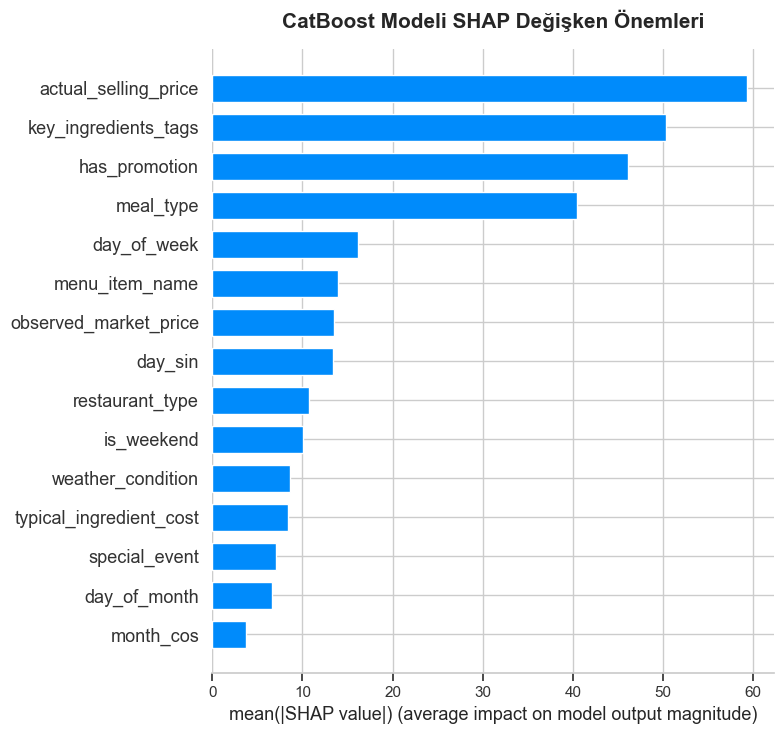

In [247]:
# =========================================================
# 10.42 SHAP GENEL DEĞİŞKEN ÖNEM GRAFİĞİ
# =========================================================

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title(
    "CatBoost Modeli SHAP Değişken Önemleri",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

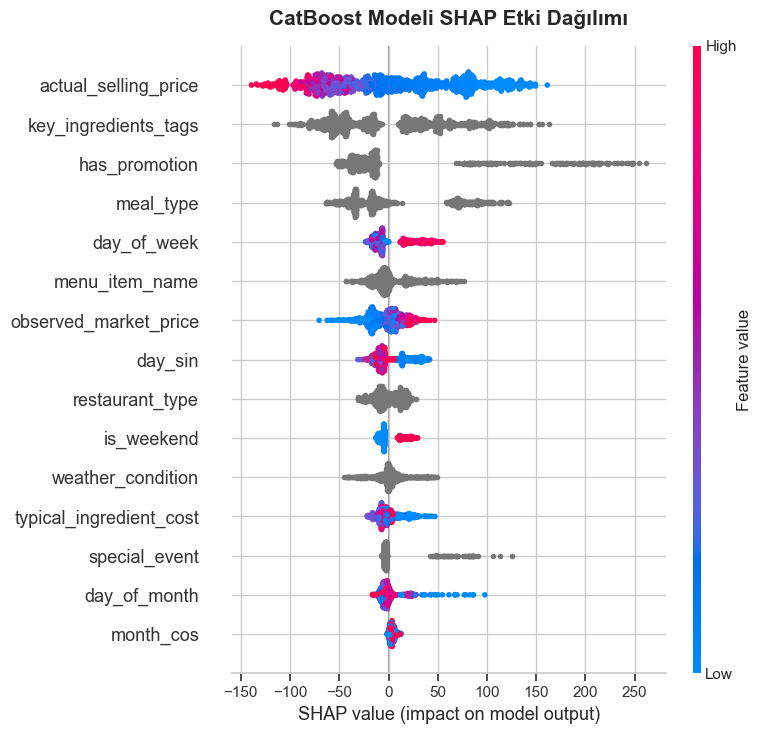

In [249]:
# =========================================================
# 10.43 SHAP SUMMARY PLOT
# =========================================================

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=15,
    show=False
)

plt.title(
    "CatBoost Modeli SHAP Etki Dağılımı",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

In [251]:
# =========================================================
# 10.44 EN ÖNEMLİ SAYISAL DEĞİŞKENİN BELİRLENMESİ
# =========================================================

numeric_shap_features = [
    feature
    for feature in shap_importance["feature"]
    if feature in numeric_features
]

top_numeric_feature = numeric_shap_features[0]

print("En önemli sayısal değişken:", top_numeric_feature)

En önemli sayısal değişken: actual_selling_price


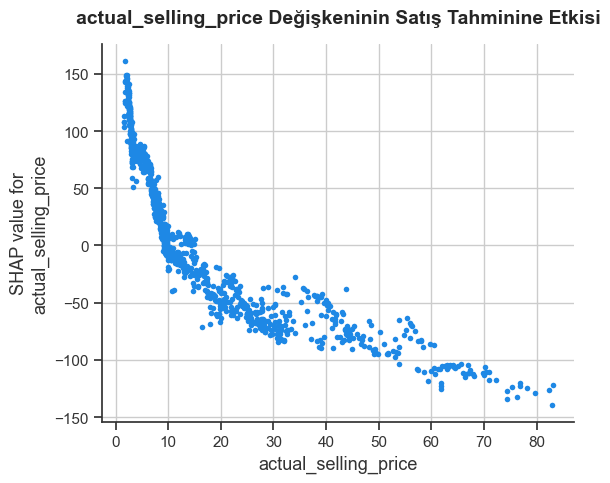

In [253]:
# =========================================================
# 10.45 SHAP DEPENDENCE PLOT
# =========================================================

shap.dependence_plot(
    top_numeric_feature,
    shap_values,
    X_shap,
    interaction_index=None,
    show=False
)

plt.title(
    f"{top_numeric_feature} Değişkeninin Satış Tahminine Etkisi",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

### SHAP Analizinin Değerlendirilmesi

Modelin tahmin mekanizmasını açıklayabilmek amacıyla SHAP (SHapley Additive exPlanations) analizi uygulanmıştır. Bu analiz sayesinde her bir değişkenin satış tahminlerine yaptığı katkı hem büyüklük hem de yön açısından incelenmiştir.

SHAP değişken önem sıralaması incelendiğinde **actual_selling_price** değişkeninin model üzerinde en yüksek etkiye sahip olduğu görülmüştür. Bu değişkeni sırasıyla **key_ingredients_tags**, **has_promotion**, **meal_type** ve **day_of_week** değişkenleri takip etmektedir. Sonuçlar, modelin yalnızca ürün fiyatını değil; ürün özellikleri, promosyon bilgisi ve zamansal faktörleri birlikte değerlendirerek tahmin oluşturduğunu göstermektedir.

SHAP Summary Plot sonuçları, değişkenlerin tahminleri hangi yönde etkilediğini ortaya koymuştur. Özellikle satış fiyatı arttıkça SHAP değerlerinin negatif yönde değiştiği, düşük fiyat seviyelerinde ise pozitif katkının arttığı gözlemlenmiştir. Bu durum fiyat ile talep arasındaki beklenen ters ilişkiyi yansıtmakta ve modelin gerçekçi karar kuralları öğrendiğini göstermektedir. Benzer şekilde promosyon uygulamaları ve öğün tipi de satış tahminleri üzerinde belirgin etkilere sahiptir.

En önemli sayısal değişken için oluşturulan SHAP Dependence Plot, satış fiyatı ile model tahminleri arasında doğrusal olmayan güçlü bir ilişki bulunduğunu göstermiştir. Fiyat seviyeleri yükseldikçe model satış tahminlerini azaltma eğilimindeyken, düşük fiyat seviyelerinde satış tahminleri artmaktadır.

Genel olarak SHAP analizi, CatBoost modelinin kararlarının yorumlanabilir olduğunu ve modelin restoran satışlarını etkileyen temel iş dinamiklerini başarılı bir şekilde öğrendiğini ortaya koymaktadır. Bu bulgular, model performansının yalnızca istatistiksel olarak değil, aynı zamanda işletme açısından da anlamlı ve açıklanabilir olduğunu desteklemektedir.

In [258]:
# ============================================================
# 10.46 RESTORAN BAZLI MODEL PERFORMANSI
# ============================================================

restaurant_performance = (
    test_predictions_table
    .groupby("restaurant_id", as_index=False)
    .agg(
        Gözlem_Sayısı=("quantity_sold", "count"),
        Ortalama_Gerçek_Satış=("quantity_sold", "mean"),
        Ortalama_Tahmin=("predicted_quantity_sold", "mean"),
        Ortalama_MAE=("absolute_error", "mean"),
        Ortalama_MAPE=("percentage_error", "mean")
    )
    .round(2)
    .sort_values("Ortalama_MAE")
    .reset_index(drop=True)
)

restaurant_performance

,restaurant_id,Gözlem_Sayısı,Ortalama_Gerçek_Satış,Ortalama_Tahmin,Ortalama_MAE,Ortalama_MAPE
0,38,25,241.16,247.81,43.50,60.60
1,21,19,237.63,219.48,49.94,38.58
2,10,28,205.75,223.40,52.47,80.73
3,37,20,310.80,313.30,54.08,24.32
4,39,32,293.47,306.56,56.32,163.56
5,41,39,272.00,269.74,56.55,56.42
6,9,24,249.50,261.80,57.05,33.89
7,42,27,205.15,205.77,60.16,44.95
8,23,32,250.97,218.59,60.62,24.08
9,50,37,201.70,217.23,61.38,58.52


In [260]:
# Ortalama mutlak hatası en düşük 10 restoran
restaurant_performance.head(10)

,restaurant_id,Gözlem_Sayısı,Ortalama_Gerçek_Satış,Ortalama_Tahmin,Ortalama_MAE,Ortalama_MAPE
0,38,25,241.16,247.81,43.50,60.60
1,21,19,237.63,219.48,49.94,38.58
2,10,28,205.75,223.40,52.47,80.73
3,37,20,310.80,313.30,54.08,24.32
4,39,32,293.47,306.56,56.32,163.56
5,41,39,272.00,269.74,56.55,56.42
6,9,24,249.50,261.80,57.05,33.89
7,42,27,205.15,205.77,60.16,44.95
8,23,32,250.97,218.59,60.62,24.08
9,50,37,201.70,217.23,61.38,58.52


In [262]:
# Ortalama mutlak hatası en yüksek 10 restoran
restaurant_performance.tail(10).sort_values(
    "Ortalama_MAE",
    ascending=False
)

,restaurant_id,Gözlem_Sayısı,Ortalama_Gerçek_Satış,Ortalama_Tahmin,Ortalama_MAE,Ortalama_MAPE
49,35,23,464.96,406.25,115.72,21.34
48,34,30,402.90,369.86,108.93,36.78
47,11,34,383.21,381.94,99.38,28.21
46,15,38,381.63,364.74,99.01,27.98
45,13,33,376.36,394.24,98.81,62.96
44,47,24,377.08,395.74,95.42,40.91
43,33,23,349.22,344.65,88.73,27.05
42,46,28,307.36,297.45,88.57,33.83
41,26,27,268.74,284.32,86.00,44.72
40,30,31,292.71,268.15,84.84,131.60


### Restoran Bazlı Model Performansının Değerlendirilmesi

CatBoost modelinin test verisindeki tahmin performansı restoran bazında incelenmiştir. Restoranlar arasında model hata düzeylerinin farklılaştığı görülmektedir. Ortalama mutlak hata değerlerine göre model, bazı restoranların satış örüntülerini daha başarılı biçimde öğrenirken bazı restoranlarda daha yüksek tahmin hataları üretmektedir.

En düşük ortalama mutlak hata Restoran 38'de elde edilmiş ve bu restoranı Restoran 21, Restoran 10 ve Restoran 37 izlemiştir. Bu sonuçlar, söz konusu restoranların satış yapılarının kullanılan ürün, fiyat, promosyon, öğün ve zaman değişkenleriyle daha düzenli ve öngörülebilir olduğunu göstermektedir.

Modelin en fazla zorlandığı restoranlar arasında Restoran 35, Restoran 34, Restoran 11, Restoran 15 ve Restoran 13 bulunmaktadır. Bu restoranlardaki daha yüksek hata değerleri; satışların daha değişken olması, test dönemindeki gözlem sayısının sınırlı kalması veya modele dahil edilmeyen restoran özelindeki faktörlerden kaynaklanabilir.

Bazı restoranlarda MAPE değerlerinin oldukça yüksek olması, gerçek satış miktarının sıfıra veya düşük değerlere yakın olduğu gözlemlerin yüzde hatayı büyütmesinden kaynaklanabilir. Bu nedenle restoran bazlı model başarısı değerlendirilirken temel performans ölçütü olarak ortalama mutlak hata kullanılmış, MAPE ise destekleyici bir ölçüt olarak ele alınmıştır.

Bu analiz, agent sisteminin bütün restoranlara aynı güven düzeyiyle yaklaşmaması gerektiğini göstermektedir. Model hatasının düşük olduğu restoranlarda tahminler doğrudan stok ve hazırlık önerilerinde kullanılabilirken, hata düzeyi yüksek restoranlarda daha temkinli öneriler üretilmesi, güven aralığının genişletilmesi veya ek işletme verilerinin değerlendirilmesi daha uygun olacaktır.

In [265]:
# ============================================================
# 10.47 ÜRÜN BAZLI MODEL PERFORMANSI
# ============================================================

product_performance = (
    test_predictions_table
    .groupby("menu_item_name", as_index=False)
    .agg(
        Gözlem_Sayısı=("quantity_sold", "count"),
        Ortalama_Gerçek_Satış=("quantity_sold", "mean"),
        Ortalama_Tahmin=("predicted_quantity_sold", "mean"),
        Ortalama_MAE=("absolute_error", "mean"),
        Ortalama_MAPE=("percentage_error", "mean")
    )
    .round(2)
    .sort_values("Ortalama_MAE")
    .reset_index(drop=True)
)

product_performance

,menu_item_name,Gözlem_Sayısı,Ortalama_Gerçek_Satış,Ortalama_Tahmin,Ortalama_MAE,Ortalama_MAPE
0,Beef Rendang,97,99.00,100.63,48.76,199.31
1,Mushroom Soup,100,103.52,113.80,49.21,121.42
2,Tandoori Chicken,112,126.46,118.46,54.38,107.01
3,Laksa,32,175.56,201.45,58.75,82.08
4,Spaghetti Carbonara,114,158.33,149.26,59.02,140.97
5,Chicken Chop,102,168.46,159.32,62.88,106.26
6,Char Kway Teow,57,162.49,147.24,65.09,150.73
7,Nasi Lemak,101,372.00,375.64,69.28,23.11
8,Chicken Rice,45,251.20,264.22,70.21,45.03
9,Cendol,172,254.72,267.61,72.07,54.30


In [267]:
product_performance.tail(10).sort_values(
    "Ortalama_MAE",
    ascending=False
)

,menu_item_name,Gözlem_Sayısı,Ortalama_Gerçek_Satış,Ortalama_Tahmin,Ortalama_MAE,Ortalama_MAPE
13,Teh Tarik,171,576.13,568.12,112.25,21.14
12,Kaya Toast Set,204,466.67,447.89,90.31,22.13
11,Roti Canai,104,379.12,386.87,85.64,26.15
10,Iced Lemon Tea,111,357.45,346.99,75.78,26.35
9,Cendol,172,254.72,267.61,72.07,54.30
8,Chicken Rice,45,251.20,264.22,70.21,45.03
7,Nasi Lemak,101,372.00,375.64,69.28,23.11
6,Char Kway Teow,57,162.49,147.24,65.09,150.73
5,Chicken Chop,102,168.46,159.32,62.88,106.26
4,Spaghetti Carbonara,114,158.33,149.26,59.02,140.97


### Ürün Bazlı Model Performansının Değerlendirilmesi

CatBoost modelinin tahmin performansı ürün bazında incelendiğinde bazı ürünlerin satışlarının oldukça başarılı tahmin edildiği, bazı ürünlerde ise hata düzeyinin belirgin biçimde arttığı görülmektedir. Ortalama mutlak hata (MAE) değerlerine göre Beef Rendang, Mushroom Soup ve Tandoori Chicken ürünlerinde model daha başarılı tahminler üretirken; Teh Tarik, Kaya Toast Set ve Roti Canai ürünlerinde hata düzeyi daha yüksek gerçekleşmiştir.

Ürünler arasındaki performans farklılıkları, talep değişkenliği, ürünlerin satış hacmi ve dönemsel davranışlarından kaynaklanabilir. Özellikle satışları daha istikrarlı ürünlerde modelin gerçek satış eğilimini daha başarılı öğrendiği görülmektedir.

Bazı ürünlerde MAPE değerlerinin yüksek olmasına rağmen MAE değerlerinin düşük kalması, gerçek satış miktarının düşük olduğu gözlemlerde yüzde hatanın büyümesinden kaynaklanmaktadır. Bu nedenle ürün bazlı karşılaştırmalarda temel performans ölçütü olarak MAE dikkate alınmıştır.

Bu analiz, agent sisteminin tüm ürünler için aynı güven düzeyiyle tahmin üretmemesi gerektiğini göstermektedir. Tahmin hatasının düşük olduğu ürünlerde stok planlama ve üretim önerileri daha güvenilir şekilde oluşturulabilirken, hata düzeyi yüksek ürünlerde daha temkinli karar mekanizmalarının kullanılması veya ek bilgi kaynaklarının değerlendirilmesi önerilmektedir.

In [270]:
# ============================================================
# 10.48 HAVA DURUMU BAZLI MODEL PERFORMANSI
# ============================================================

weather_performance = (
    test_predictions_table
    .groupby("weather_condition", as_index=False)
    .agg(
        Gözlem_Sayısı=("quantity_sold", "count"),
        Ortalama_Gerçek_Satış=("quantity_sold", "mean"),
        Ortalama_Tahmin=("predicted_quantity_sold", "mean"),
        Ortalama_MAE=("absolute_error", "mean"),
        Ortalama_MAPE=("percentage_error", "mean")
    )
    .round(2)
    .sort_values("Ortalama_MAE")
)

weather_performance

,weather_condition,Gözlem_Sayısı,Ortalama_Gerçek_Satış,Ortalama_Tahmin,Ortalama_MAE,Ortalama_MAPE
0,Cloudy,483,277.47,277.09,69.60,71.70
2,Sunny,744,322.98,317.03,75.28,65.04
1,Rainy,295,255.69,257.40,75.72,73.81


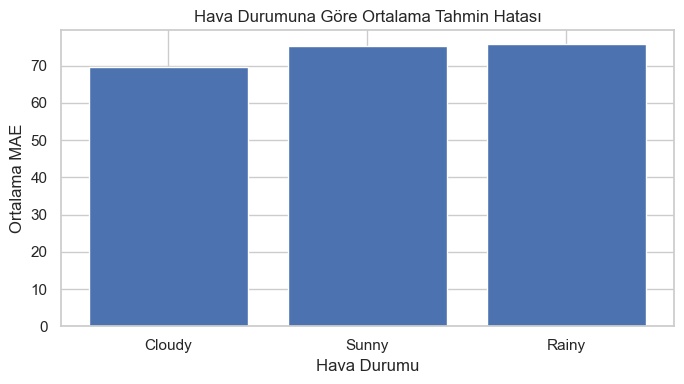

In [272]:
plt.figure(figsize=(7,4))

plt.bar(
    weather_performance["weather_condition"],
    weather_performance["Ortalama_MAE"]
)

plt.title("Hava Durumuna Göre Ortalama Tahmin Hatası")
plt.xlabel("Hava Durumu")
plt.ylabel("Ortalama MAE")

plt.tight_layout()
plt.show()

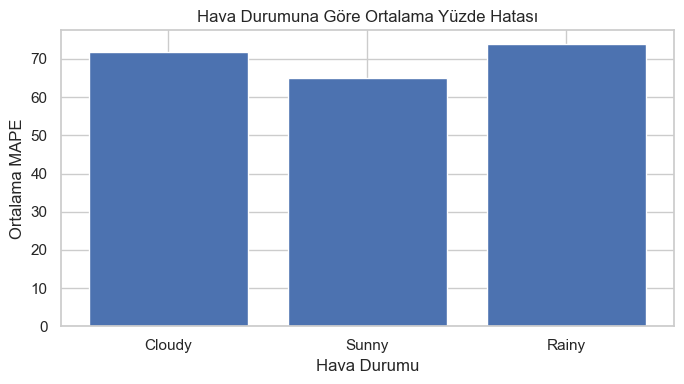

In [274]:
plt.figure(figsize=(7,4))

plt.bar(
    weather_performance["weather_condition"],
    weather_performance["Ortalama_MAPE"]
)

plt.title("Hava Durumuna Göre Ortalama Yüzde Hatası")
plt.xlabel("Hava Durumu")
plt.ylabel("Ortalama MAPE")

plt.tight_layout()
plt.show()

### Hava Durumuna Göre Model Performansının Değerlendirilmesi

Model performansı hava durumu bazında incelendiğinde farklı hava koşulları arasında tahmin başarısında küçük farklılıklar olduğu görülmektedir. Ortalama mutlak hata (MAE) değerlerine göre model en başarılı performansı bulutlu (Cloudy) günlerde göstermiştir. Yağmurlu (Rainy) günlerde ise hata düzeyi bir miktar artmıştır. Ortalama yüzde hata (MAPE) açısından ise en düşük hata güneşli (Sunny) günlerde elde edilmiştir.

Hava koşulları arasında performans farklılıkları bulunsa da hata değerleri birbirine oldukça yakındır. Bu durum modelin farklı hava koşullarına karşı genel olarak kararlı bir performans sergilediğini göstermektedir.

Özellikle yağmurlu günlerde hata düzeyinin nispeten yükselmesi, hava koşullarının müşteri davranışlarını daha değişken hale getirmesinden kaynaklanabilir. Buna karşın model, tüm hava koşullarında benzer doğruluk seviyelerini koruyabilmiştir.

Agent sistemi açısından bu sonuç, hava durumunun karar mekanizmasında tamamen göz ardı edilmemesi gerektiğini ancak tek başına belirleyici bir faktör olarak da değerlendirilmemesi gerektiğini göstermektedir. Özellikle yağmurlu günlerde tahminlere daha temkinli yaklaşılması, buna karşılık bulutlu ve güneşli günlerde model tahminlerine daha yüksek güven duyulması uygun olacaktır.

In [283]:
# ============================================================
# 10.49 PROMOSYON BAZLI MODEL PERFORMANSI
# ============================================================

promotion_data = test_predictions_table.copy()

# Promosyon değişkenini güvenli biçimde standartlaştır
promotion_data["promotion_status"] = (
    promotion_data["has_promotion"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "true": "Promosyon Var",
        "1": "Promosyon Var",
        "yes": "Promosyon Var",
        "false": "Promosyon Yok",
        "0": "Promosyon Yok",
        "no": "Promosyon Yok"
    })
)

# Dönüşüm kontrolü
print(promotion_data[
    ["has_promotion", "promotion_status"]
].drop_duplicates())

promotion_performance = (
    promotion_data
    .dropna(subset=["promotion_status"])
    .groupby("promotion_status", as_index=False)
    .agg(
        Gözlem_Sayısı=("quantity_sold", "count"),
        Ortalama_Gerçek_Satış=("quantity_sold", "mean"),
        Ortalama_Tahmin=("predicted_quantity_sold", "mean"),
        Ortalama_MAE=("absolute_error", "mean"),
        Ortalama_MAPE=("percentage_error", "mean")
    )
    .round(2)
    .sort_values("Ortalama_MAE")
    .reset_index(drop=True)
)

promotion_performance

     has_promotion promotion_status
8478         False    Promosyon Yok
8479          True    Promosyon Var


,promotion_status,Gözlem_Sayısı,Ortalama_Gerçek_Satış,Ortalama_Tahmin,Ortalama_MAE,Ortalama_MAPE
0,Promosyon Yok,1300,265.20,261.18,72.14,76.41
1,Promosyon Var,222,472.92,477.96,81.92,26.45


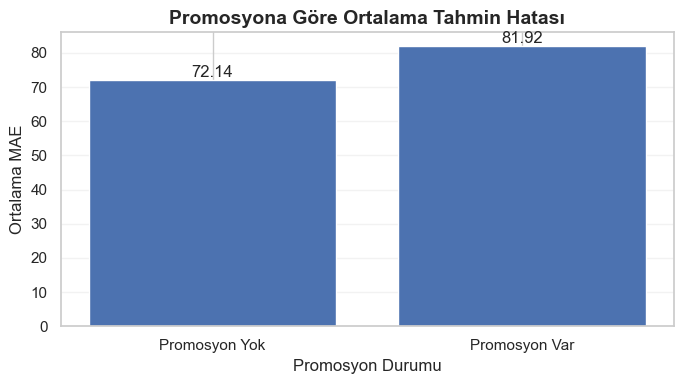

In [285]:
# ============================================================
# 10.49.1 PROMOSYONA GÖRE ORTALAMA MAE
# ============================================================

plt.figure(figsize=(7, 4))

bars = plt.bar(
    promotion_performance["promotion_status"],
    promotion_performance["Ortalama_MAE"]
)

for bar, value in zip(
    bars,
    promotion_performance["Ortalama_MAE"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.title(
    "Promosyona Göre Ortalama Tahmin Hatası",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Promosyon Durumu")
plt.ylabel("Ortalama MAE")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

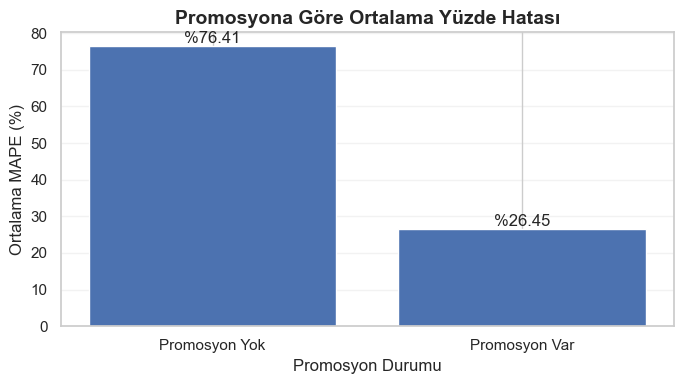

In [287]:
# ============================================================
# 10.49.2 PROMOSYONA GÖRE ORTALAMA MAPE
# ============================================================

plt.figure(figsize=(7, 4))

bars = plt.bar(
    promotion_performance["promotion_status"],
    promotion_performance["Ortalama_MAPE"]
)

for bar, value in zip(
    bars,
    promotion_performance["Ortalama_MAPE"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"%{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.title(
    "Promosyona Göre Ortalama Yüzde Hatası",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Promosyon Durumu")
plt.ylabel("Ortalama MAPE (%)")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### Promosyon Durumuna Göre Model Performansının Değerlendirilmesi

Promosyon durumuna göre yapılan incelemede, promosyonlu gözlemlerde ortalama satış miktarının belirgin biçimde yükseldiği görülmüştür. Promosyon uygulanmayan dönemlerde ortalama gerçek satış 265,20 iken, promosyonlu dönemlerde bu değer 472,92’ye ulaşmıştır. Bu sonuç, promosyonların talep üzerinde güçlü bir artırıcı etkiye sahip olduğunu göstermektedir.

Modelin ortalama mutlak hatası promosyonlu dönemde 81,92, promosyon olmayan dönemde ise 72,14 olarak hesaplanmıştır. Promosyonlu satışlarda mutlak hata bir miktar daha yüksek olmakla birlikte, ortalama yüzde hata promosyonlu grupta %26,45 ile oldukça daha düşüktür. Promosyon uygulanmayan grupta ise MAPE değeri %76,41’dir.

Bu farklılık, promosyonlu dönemlerde satış hacminin daha yüksek olmasından kaynaklanmaktadır. Yüksek satış değerlerinde mutlak hata artsa bile, hata toplam satış miktarına oranlandığında daha düşük kalmaktadır. Buna karşılık düşük veya sıfıra yakın satış gözlemleri, promosyon olmayan gruptaki MAPE değerini önemli ölçüde yükseltebilmektedir.

Bu bulgular doğrultusunda promosyon değişkeni, hem talep tahmini hem de agent sisteminin stok ve üretim önerileri açısından kritik bir karar değişkenidir. Agent sistemi promosyonlu günlerde daha yüksek talep beklemeli; stok, hazırlık miktarı ve personel planlamasını buna göre artırmalıdır.

In [290]:
# ============================================================
# 10.50 EN YÜKSEK HATA YAPILAN GÖZLEMLER
# ============================================================

top_error_cases = (
    test_predictions_table
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(20)
    .reset_index(drop=True)
)

top_error_cases[
    [
        "date",
        "restaurant_id",
        "menu_item_name",
        "meal_type",
        "has_promotion",
        "weather_condition",
        "actual_selling_price",
        "quantity_sold",
        "predicted_quantity_sold",
        "absolute_error",
        "percentage_error"
    ]
]

,date,restaurant_id,menu_item_name,meal_type,has_promotion,weather_condition,actual_selling_price,quantity_sold,predicted_quantity_sold,absolute_error,percentage_error
0,2024-12-01,35,Teh Tarik,Breakfast,False,Sunny,2.69,1584,765.63,818.37,51.66
1,2024-12-15,35,Teh Tarik,Breakfast,False,Sunny,2.33,1668,873.40,794.60,47.64
2,2024-12-25,22,Roti Canai,Breakfast,False,Sunny,2.72,852,367.68,484.32,56.85
3,2024-12-01,33,Kaya Toast Set,Breakfast,False,Sunny,11.78,1013,537.45,475.55,46.95
4,2024-12-25,11,Teh Tarik,Lunch,False,Sunny,2.69,909,464.00,445.00,48.95
5,2024-12-01,15,Teh Tarik,Dinner,False,Sunny,2.99,972,548.55,423.45,43.57
6,2024-12-01,24,Kaya Toast Set,Breakfast,False,Sunny,11.00,987,572.56,414.44,41.99
7,2024-11-17,7,Kaya Toast Set,Breakfast,True,Sunny,10.05,1278,877.88,400.12,31.31
8,2024-12-25,23,Iced Lemon Tea,Dinner,False,Sunny,7.60,624,249.57,374.43,60.00
9,2024-12-25,15,Teh Tarik,Lunch,False,Cloudy,2.47,807,447.69,359.31,44.52


In [292]:
# ============================================================
# 10.51 TAHMİN YÖNÜNÜN BELİRLENMESİ
# ============================================================

error_analysis_data = test_predictions_table.copy()

error_analysis_data["residual"] = (
    error_analysis_data["quantity_sold"]
    - error_analysis_data["predicted_quantity_sold"]
)

error_analysis_data["prediction_direction"] = np.select(
    [
        error_analysis_data["residual"] > 0,
        error_analysis_data["residual"] < 0
    ],
    [
        "Eksik Tahmin",
        "Fazla Tahmin"
    ],
    default="Tam Tahmin"
)

error_analysis_data[
    [
        "quantity_sold",
        "predicted_quantity_sold",
        "residual",
        "absolute_error",
        "prediction_direction"
    ]
].head()

,quantity_sold,predicted_quantity_sold,residual,absolute_error,prediction_direction
8478,269,251.82,17.18,17.18,Eksik Tahmin
8479,294,200.64,93.36,93.36,Eksik Tahmin
8480,373,310.81,62.19,62.19,Eksik Tahmin
8481,162,154.64,7.36,7.36,Eksik Tahmin
8482,332,262.36,69.64,69.64,Eksik Tahmin


In [294]:
# ============================================================
# TAHMİN YÖNÜ ÖZETİ
# ============================================================

prediction_direction_summary = (
    error_analysis_data
    .groupby("prediction_direction", as_index=False)
    .agg(
        Gözlem_Sayısı=("quantity_sold", "count"),
        Ortalama_Gerçek_Satış=("quantity_sold", "mean"),
        Ortalama_Tahmin=("predicted_quantity_sold", "mean"),
        Ortalama_Mutlak_Hata=("absolute_error", "mean"),
        Ortalama_Residual=("residual", "mean")
    )
    .round(2)
)

prediction_direction_summary["Yüzde"] = (
    prediction_direction_summary["Gözlem_Sayısı"]
    / len(error_analysis_data)
    * 100
).round(2)

prediction_direction_summary

,prediction_direction,Gözlem_Sayısı,Ortalama_Gerçek_Satış,Ortalama_Tahmin,Ortalama_Mutlak_Hata,Ortalama_Residual,Yüzde
0,Eksik Tahmin,760,368.40,292.04,76.36,76.36,49.93
1,Fazla Tahmin,761,222.91,293.78,70.87,-70.87,50.00
2,Tam Tahmin,1,122.00,122.00,0.00,0.00,0.07


In [296]:
# ============================================================
# RESTORAN–ÜRÜN KOMBİNASYONU BAZINDA HATA ANALİZİ
# ============================================================

restaurant_product_performance = (
    error_analysis_data
    .groupby(
        ["restaurant_id", "menu_item_name"],
        as_index=False
    )
    .agg(
        Gözlem_Sayısı=("quantity_sold", "count"),
        Ortalama_Gerçek_Satış=("quantity_sold", "mean"),
        Ortalama_Tahmin=("predicted_quantity_sold", "mean"),
        Ortalama_MAE=("absolute_error", "mean"),
        Ortalama_MAPE=("percentage_error", "mean"),
        Ortalama_Residual=("residual", "mean")
    )
    .round(2)
)

restaurant_product_performance_filtered = (
    restaurant_product_performance[
        restaurant_product_performance["Gözlem_Sayısı"] >= 3
    ]
    .sort_values(
        "Ortalama_MAE",
        ascending=False
    )
    .reset_index(drop=True)
)

restaurant_product_performance_filtered.head(20)

,restaurant_id,menu_item_name,Gözlem_Sayısı,Ortalama_Gerçek_Satış,Ortalama_Tahmin,Ortalama_MAE,Ortalama_MAPE,Ortalama_Residual
0,35,Teh Tarik,3,"1,439.33",928.68,564.66,35.63,510.65
1,13,Teh Tarik,6,598.83,585.54,193.10,42.48,13.29
2,14,Teh Tarik,4,625.50,517.86,186.30,30.22,107.64
3,15,Teh Tarik,9,588.00,518.88,169.21,24.55,69.12
4,34,Kaya Toast Set,9,682.56,601.01,164.07,31.88,81.55
5,33,Kaya Toast Set,5,544.60,511.78,157.40,27.73,32.82
6,47,Teh Tarik,7,659.57,637.82,155.87,26.41,21.75
7,30,Teh Tarik,4,511.50,524.95,154.49,35.97,-13.45
8,11,Teh Tarik,7,609.00,615.62,151.19,26.18,-6.62
9,12,Spaghetti Carbonara,3,197.33,176.74,141.43,49.16,20.59


# 11. Kâr/Fiyat Agentı

Bu bölümde eğitilen CatBoost talep tahmin modeli, fiyat ve kârlılık kararlarını destekleyen bir agent yapısına dönüştürülmektedir.

Agent, farklı satış fiyatı senaryoları için beklenen satış miktarını tahmin ederek aşağıdaki finansal göstergeleri hesaplamaktadır:

- Beklenen satış miktarı
- Beklenen gelir
- Beklenen malzeme maliyeti
- Beklenen tahmini brüt kâr
- Beklenen brüt kâr marjı

Farklı fiyat senaryoları karşılaştırılarak tahmini brüt kârı en yüksek seçenek belirlenmektedir. Ayrıca restoran ve ürün bazındaki geçmiş model hataları kullanılarak önerinin güven düzeyi hesaplanmaktadır.

Üretilen öneriler geçmiş veride öğrenilen ilişkileri yansıtmaktadır. Bu nedenle fiyat değişikliklerinin nedensel etkisini kesin olarak kanıtlamaz; karar destek amacıyla kullanılmalıdır.

In [299]:
# ============================================================
# 11.1 FİNAL MODELİN KAYDEDİLMESİ
# ============================================================

import json
from pathlib import Path

model_output_dir = Path("models")
model_output_dir.mkdir(parents=True, exist_ok=True)

# CatBoost modeli
catboost_model.save_model(
    str(model_output_dir / "kar_fiyat_catboost.cbm")
)

# Modelde kullanılan sütun bilgileri
model_metadata = {
    "model_name": "CatBoostRegressor",
    "target_column": target_column,
    "feature_columns": feature_columns,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "test_mae": 73.56,
    "test_rmse": 100.32,
    "test_r2": 0.80
}

with open(
    model_output_dir / "kar_fiyat_model_metadata.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        model_metadata,
        file,
        ensure_ascii=False,
        indent=4
    )

print("Model ve metadata başarıyla kaydedildi.")

Model ve metadata başarıyla kaydedildi.


In [301]:
# ============================================================
# 11.2 MODEL GİRDİSİNİ HAZIRLAMA FONKSİYONU
# ============================================================

def prepare_agent_input(input_data):
    """
    Kullanıcıdan veya agent'tan gelen girdiyi,
    CatBoost modelinin beklediği yapıya dönüştürür.
    """

    prepared_data = input_data.copy()

    if not isinstance(prepared_data, pd.DataFrame):
        prepared_data = pd.DataFrame([prepared_data])

    prepared_data["date"] = pd.to_datetime(
        prepared_data["date"],
        errors="coerce"
    )

    if prepared_data["date"].isna().any():
        raise ValueError(
            "Tarih değişkeni geçerli bir tarih formatında olmalıdır."
        )

    # Tarih özellikleri
    prepared_data["year"] = prepared_data["date"].dt.year
    prepared_data["month"] = prepared_data["date"].dt.month
    prepared_data["day_of_month"] = prepared_data["date"].dt.day
    prepared_data["day_of_week"] = prepared_data["date"].dt.dayofweek

    prepared_data["week_of_year"] = (
        prepared_data["date"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    prepared_data["is_weekend"] = (
        prepared_data["day_of_week"] >= 5
    ).astype(int)

    # Döngüsel tarih özellikleri
    prepared_data["day_sin"] = np.sin(
        2 * np.pi * prepared_data["day_of_week"] / 7
    )

    prepared_data["day_cos"] = np.cos(
        2 * np.pi * prepared_data["day_of_week"] / 7
    )

    prepared_data["month_sin"] = np.sin(
        2 * np.pi * prepared_data["month"] / 12
    )

    prepared_data["month_cos"] = np.cos(
        2 * np.pi * prepared_data["month"] / 12
    )

    # Kategorik değişkenleri CatBoost ile uyumlu hale getir
    for column in categorical_features:
        if column not in prepared_data.columns:
            raise ValueError(
                f"Eksik kategorik değişken: {column}"
            )

        prepared_data[column] = (
            prepared_data[column]
            .fillna("Bilinmiyor")
            .astype(str)
        )

    # Sayısal değişken kontrolü
    for column in numeric_features:
        if column not in prepared_data.columns:
            raise ValueError(
                f"Eksik sayısal değişken: {column}"
            )

        prepared_data[column] = pd.to_numeric(
            prepared_data[column],
            errors="coerce"
        )

    if prepared_data[feature_columns].isna().any().any():
        missing_columns = (
            prepared_data[feature_columns]
            .columns[
                prepared_data[feature_columns]
                .isna()
                .any()
            ]
            .tolist()
        )

        raise ValueError(
            f"Eksik veya geçersiz değer bulunan sütunlar: "
            f"{missing_columns}"
        )

    return prepared_data[feature_columns]

In [303]:
# ============================================================
# 11.3 AGENT GÜVEN DÜZEYİ
# ============================================================

def calculate_prediction_confidence(
    restaurant_id,
    menu_item_name,
    default_mae=73.56
):
    """
    Restoran ve ürün bazındaki geçmiş model hatalarını kullanarak
    önerinin güven düzeyini hesaplar.
    """

    restaurant_error = default_mae
    product_error = default_mae

    # Restoran bazlı hata
    if "restaurant_performance" in globals():
        restaurant_match = restaurant_performance[
            restaurant_performance["restaurant_id"]
            == int(restaurant_id)
        ]

        if not restaurant_match.empty:
            restaurant_error = float(
                restaurant_match["Ortalama_MAE"].iloc[0]
            )

    # Ürün bazlı hata
    if "product_performance" in globals():
        product_match = product_performance[
            product_performance["menu_item_name"]
            == menu_item_name
        ]

        if not product_match.empty:
            product_error = float(
                product_match["Ortalama_MAE"].iloc[0]
            )

    combined_mae = (
        restaurant_error + product_error
    ) / 2

    if combined_mae <= 60:
        confidence_level = "Yüksek"
    elif combined_mae <= 90:
        confidence_level = "Orta"
    else:
        confidence_level = "Düşük"

    return {
        "confidence_level": confidence_level,
        "estimated_mae": round(combined_mae, 2),
        "restaurant_mae": round(restaurant_error, 2),
        "product_mae": round(product_error, 2)
    }

In [305]:
# ============================================================
# 11.4 KÂR/FİYAT AGENT SINIFI
# ============================================================

class KarFiyatAgent:
    """
    Farklı fiyat senaryoları için satış ve kârlılık tahmini
    üreten karar destek agent'ı.
    """

    def __init__(
        self,
        model,
        price_change_rates=None
    ):
        self.model = model

        if price_change_rates is None:
            price_change_rates = [
                -0.10,
                -0.05,
                0.00,
                0.05,
                0.10
            ]

        self.price_change_rates = price_change_rates

    def predict_quantity(self, input_data):
        """
        Tek bir koşul için beklenen satış miktarını tahmin eder.
        """

        model_input = prepare_agent_input(input_data)

        prediction = self.model.predict(
            model_input
        )[0]

        prediction = max(0, float(prediction))

        return prediction

    def evaluate_price_scenarios(
        self,
        base_input,
        minimum_margin_pct=20
    ):
        """
        Farklı fiyat senaryolarını değerlendirir.
        """

        required_columns = [
            "actual_selling_price",
            "typical_ingredient_cost",
            "observed_market_price"
        ]

        for column in required_columns:
            if column not in base_input:
                raise ValueError(
                    f"Eksik değişken: {column}"
                )

        current_price = float(
            base_input["actual_selling_price"]
        )

        ingredient_cost = float(
            base_input["typical_ingredient_cost"]
        )

        market_price = float(
            base_input["observed_market_price"]
        )

        scenario_results = []

        for change_rate in self.price_change_rates:
            scenario_input = base_input.copy()

            scenario_price = current_price * (
                1 + change_rate
            )

            scenario_input[
                "actual_selling_price"
            ] = scenario_price

            predicted_quantity = self.predict_quantity(
                scenario_input
            )

            expected_revenue = (
                scenario_price * predicted_quantity
            )

            expected_cost = (
                ingredient_cost * predicted_quantity
            )

            expected_profit = (
                expected_revenue - expected_cost
            )

            if expected_revenue > 0:
                profit_margin_pct = (
                    expected_profit
                    / expected_revenue
                    * 100
                )
            else:
                profit_margin_pct = 0

            price_vs_market_pct = (
                (
                    scenario_price - market_price
                )
                / market_price
                * 100
            )

            scenario_results.append({
                "price_change_pct": change_rate * 100,
                "scenario_price": scenario_price,
                "predicted_quantity": predicted_quantity,
                "expected_revenue": expected_revenue,
                "expected_cost": expected_cost,
                "expected_profit": expected_profit,
                "profit_margin_pct": profit_margin_pct,
                "price_vs_market_pct": price_vs_market_pct
            })

        scenario_table = pd.DataFrame(
            scenario_results
        )

        # Minimum kâr marjı koşulunu sağlayan senaryolar
        eligible_scenarios = scenario_table[
            scenario_table["profit_margin_pct"]
            >= minimum_margin_pct
        ].copy()

        if eligible_scenarios.empty:
            eligible_scenarios = scenario_table.copy()

        best_scenario = (
            eligible_scenarios
            .sort_values(
                "expected_profit",
                ascending=False
            )
            .iloc[0]
        )

        return (
            scenario_table.round(2),
            best_scenario
        )

    def generate_recommendation(
        self,
        base_input,
        minimum_margin_pct=20
    ):
        """
        Agent'ın nihai karar çıktısını üretir.
        """

        scenario_table, best_scenario = (
            self.evaluate_price_scenarios(
                base_input=base_input,
                minimum_margin_pct=minimum_margin_pct
            )
        )

        current_scenario = scenario_table[
            scenario_table["price_change_pct"] == 0
        ].iloc[0]

        profit_improvement = (
            best_scenario["expected_profit"]
            - current_scenario["expected_profit"]
        )

        if (
            best_scenario["price_change_pct"] > 0
        ):
            action = "Fiyatı artır"
        elif (
            best_scenario["price_change_pct"] < 0
        ):
            action = "Fiyatı düşür"
        else:
            action = "Mevcut fiyatı koru"

        confidence = calculate_prediction_confidence(
            restaurant_id=base_input["restaurant_id"],
            menu_item_name=base_input["menu_item_name"]
        )

        recommendation = {
            "restaurant_id": int(
                base_input["restaurant_id"]
            ),
            "menu_item_name": base_input[
                "menu_item_name"
            ],
            "current_price": round(
                float(
                    base_input[
                        "actual_selling_price"
                    ]
                ),
                2
            ),
            "recommended_price": round(
                float(
                    best_scenario[
                        "scenario_price"
                    ]
                ),
                2
            ),
            "recommended_price_change_pct": round(
                float(
                    best_scenario[
                        "price_change_pct"
                    ]
                ),
                2
            ),
            "action": action,
            "predicted_quantity": round(
                float(
                    best_scenario[
                        "predicted_quantity"
                    ]
                ),
                0
            ),
            "expected_revenue": round(
                float(
                    best_scenario[
                        "expected_revenue"
                    ]
                ),
                2
            ),
            "expected_profit": round(
                float(
                    best_scenario[
                        "expected_profit"
                    ]
                ),
                2
            ),
            "expected_profit_margin_pct": round(
                float(
                    best_scenario[
                        "profit_margin_pct"
                    ]
                ),
                2
            ),
            "expected_profit_improvement": round(
                float(profit_improvement),
                2
            ),
            "confidence_level": confidence[
                "confidence_level"
            ],
            "estimated_prediction_mae": confidence[
                "estimated_mae"
            ],
            "warning": (
                "Bu öneri geçmiş veride öğrenilen ilişkiler "
                "üzerinden üretilmiştir; nedensel fiyat "
                "etkisi olarak yorumlanmamalıdır."
            )
        }

        return {
            "recommendation": recommendation,
            "scenarios": scenario_table
        }

In [307]:
# ============================================================
# 11.5 AGENT'IN OLUŞTURULMASI
# ============================================================

kar_fiyat_agent = KarFiyatAgent(
    model=catboost_model,
    price_change_rates=[
        -0.10,
        -0.05,
        0.00,
        0.05,
        0.10
    ]
)

print("Kâr/Fiyat Agentı başarıyla oluşturuldu.")

Kâr/Fiyat Agentı başarıyla oluşturuldu.


In [309]:
# ============================================================
# 11.6 ÖRNEK AGENT SENARYOSU
# ============================================================

example_row = sales_data[
    sales_data["menu_item_name"] == "Chicken Chop"
].iloc[0]

agent_input = {
    "date": "2025-01-04",
    "restaurant_id": example_row["restaurant_id"],
    "restaurant_type": example_row["restaurant_type"],
    "menu_item_name": example_row["menu_item_name"],
    "meal_type": example_row["meal_type"],
    "key_ingredients_tags": example_row[
        "key_ingredients_tags"
    ],
    "typical_ingredient_cost": example_row[
        "typical_ingredient_cost"
    ],
    "observed_market_price": example_row[
        "observed_market_price"
    ],
    "actual_selling_price": example_row[
        "actual_selling_price"
    ],
    "has_promotion": example_row["has_promotion"],
    "special_event": False,
    "weather_condition": "Sunny"
}

agent_result = kar_fiyat_agent.generate_recommendation(
    base_input=agent_input,
    minimum_margin_pct=20
)

agent_result["recommendation"]

{'restaurant_id': 46,
 'menu_item_name': 'Chicken Chop',
 'current_price': 39.31,
 'recommended_price': 39.31,
 'recommended_price_change_pct': 0.0,
 'action': 'Mevcut fiyatı koru',
 'predicted_quantity': 199.0,
 'expected_revenue': 7818.11,
 'expected_profit': 6227.04,
 'expected_profit_margin_pct': 79.65,
 'expected_profit_improvement': -0.0,
 'confidence_level': 'Orta',
 'estimated_prediction_mae': 68.22,
 'warning': 'Bu öneri geçmiş veride öğrenilen ilişkiler üzerinden üretilmiştir; nedensel fiyat etkisi olarak yorumlanmamalıdır.'}

In [311]:
agent_result["scenarios"]

,price_change_pct,scenario_price,predicted_quantity,expected_revenue,expected_cost,expected_profit,profit_margin_pct,price_vs_market_pct
0,-10.00,35.38,209.31,"7,405.22","1,674.49","5,730.73",77.39,25.46
1,-5.00,37.34,209.68,"7,830.23","1,677.41","6,152.83",78.58,32.43
2,0.00,39.31,198.88,"7,818.11","1,591.07","6,227.04",79.65,39.40
3,5.00,41.28,175.67,"7,251.00","1,405.39","5,845.62",80.62,46.37
4,10.00,43.24,158.68,"6,861.49","1,269.44","5,592.05",81.50,53.34


In [313]:
# ============================================================
# 11.8 AGENT ÖNERİSİNİN YAZDIRILMASI
# ============================================================

recommendation = agent_result["recommendation"]

print("=" * 60)
print("KÂR / FİYAT AGENT ÖNERİSİ")
print("=" * 60)

print(
    f"Restoran: {recommendation['restaurant_id']}"
)

print(
    f"Ürün: {recommendation['menu_item_name']}"
)

print(
    f"Mevcut fiyat: "
    f"{recommendation['current_price']:.2f}"
)

print(
    f"Önerilen fiyat: "
    f"{recommendation['recommended_price']:.2f}"
)

print(
    f"Karar: {recommendation['action']}"
)

print(
    f"Fiyat değişimi: "
    f"%{recommendation['recommended_price_change_pct']:.1f}"
)

print(
    f"Tahmini satış: "
    f"{recommendation['predicted_quantity']:.0f}"
)

print(
    f"Beklenen gelir: "
    f"{recommendation['expected_revenue']:.2f}"
)

print(
    f"Beklenen tahmini brüt kâr: "
    f"{recommendation['expected_profit']:.2f}"
)

print(
    f"Beklenen kâr marjı: "
    f"%{recommendation['expected_profit_margin_pct']:.2f}"
)

print(
    f"Beklenen kâr iyileşmesi: "
    f"{recommendation['expected_profit_improvement']:.2f}"
)

print(
    f"Güven düzeyi: "
    f"{recommendation['confidence_level']}"
)

print(
    f"Tahmini ortalama hata: "
    f"{recommendation['estimated_prediction_mae']:.2f}"
)

print("-" * 60)
print(recommendation["warning"])

KÂR / FİYAT AGENT ÖNERİSİ
Restoran: 46
Ürün: Chicken Chop
Mevcut fiyat: 39.31
Önerilen fiyat: 39.31
Karar: Mevcut fiyatı koru
Fiyat değişimi: %0.0
Tahmini satış: 199
Beklenen gelir: 7818.11
Beklenen tahmini brüt kâr: 6227.04
Beklenen kâr marjı: %79.65
Beklenen kâr iyileşmesi: -0.00
Güven düzeyi: Orta
Tahmini ortalama hata: 68.22
------------------------------------------------------------
Bu öneri geçmiş veride öğrenilen ilişkiler üzerinden üretilmiştir; nedensel fiyat etkisi olarak yorumlanmamalıdır.


### Kâr/Fiyat Agentı Örnek Senaryo Değerlendirmesi

Kâr/Fiyat Agentı, Chicken Chop ürünü için mevcut fiyatın %10 altında ve %10 üzerinde olmak üzere beş farklı fiyat senaryosunu karşılaştırmıştır. Her senaryoda beklenen satış miktarı CatBoost modeliyle tahmin edilmiş; ardından beklenen gelir, malzeme maliyeti, tahmini brüt kâr ve kâr marjı hesaplanmıştır.

Analiz sonucunda en yüksek beklenen tahmini brüt kârın mevcut satış fiyatı olan 39,31 seviyesinde elde edildiği görülmüştür. Fiyat indirimi satış miktarını artırmasına rağmen birim gelirdeki düşüş toplam kârı azaltmıştır. Fiyat artışı ise kâr marjını yükseltmiş, ancak satış miktarındaki azalma nedeniyle toplam tahmini brüt kârı düşürmüştür.

Bu nedenle agent, ilgili restoran ve ürün koşulları için mevcut fiyatın korunmasını önermiştir. Önerinin güven düzeyi orta olarak hesaplanmış ve geçmiş hata analizlerine göre tahmini ortalama hata 68,22 birim olarak belirlenmiştir.

Bu sonuç, agentın yalnızca satış hacmini veya kâr marjını ayrı ayrı maksimize etmediğini; toplam beklenen brüt kârı esas alarak fiyat önerisi oluşturduğunu göstermektedir.

In [318]:
def generate_recommendation(
    self,
    base_input,
    minimum_margin_pct=20
):
    """
    Agent'ın nihai fiyat ve kârlılık önerisini üretir.
    """

    scenario_table, best_scenario = (
        self.evaluate_price_scenarios(
            base_input=base_input,
            minimum_margin_pct=minimum_margin_pct
        )
    )

    # Mevcut fiyat senaryosunu bul
    current_scenario = scenario_table.loc[
        np.isclose(
            scenario_table["price_change_pct"],
            0.0
        )
    ].iloc[0]

    # En iyi senaryonun mevcut senaryoya göre kâr farkı
    profit_improvement = (
        float(best_scenario["expected_profit"])
        - float(current_scenario["expected_profit"])
    )

    # -0.0 veya çok küçük kayan nokta farklarını temizle
    if abs(profit_improvement) < 0.01:
        profit_improvement = 0.0

    recommended_change_pct = float(
        best_scenario["price_change_pct"]
    )

    # Kayan nokta hassasiyetine karşı karar üretme
    if recommended_change_pct > 0.001:
        action = "Fiyatı artır"
    elif recommended_change_pct < -0.001:
        action = "Fiyatı düşür"
    else:
        recommended_change_pct = 0.0
        action = "Mevcut fiyatı koru"

    confidence = calculate_prediction_confidence(
        restaurant_id=base_input["restaurant_id"],
        menu_item_name=base_input["menu_item_name"]
    )

    recommendation = {
        "restaurant_id": int(
            base_input["restaurant_id"]
        ),

        "menu_item_name": base_input[
            "menu_item_name"
        ],

        "current_price": round(
            float(
                base_input["actual_selling_price"]
            ),
            2
        ),

        "recommended_price": round(
            float(
                best_scenario["scenario_price"]
            ),
            2
        ),

        "recommended_price_change_pct": round(
            recommended_change_pct,
            2
        ),

        "action": action,

        "predicted_quantity": round(
            float(
                best_scenario["predicted_quantity"]
            ),
            0
        ),

        "expected_revenue": round(
            float(
                best_scenario["expected_revenue"]
            ),
            2
        ),

        "expected_cost": round(
            float(
                best_scenario["expected_cost"]
            ),
            2
        ),

        "expected_profit": round(
            float(
                best_scenario["expected_profit"]
            ),
            2
        ),

        "expected_profit_margin_pct": round(
            float(
                best_scenario["profit_margin_pct"]
            ),
            2
        ),

        "expected_profit_improvement": round(
            profit_improvement,
            2
        ),

        "confidence_level": confidence[
            "confidence_level"
        ],

        "estimated_prediction_mae": confidence[
            "estimated_mae"
        ],

        "restaurant_mae": confidence[
            "restaurant_mae"
        ],

        "product_mae": confidence[
            "product_mae"
        ],

        "warning": (
            "Bu öneri geçmiş veride öğrenilen ilişkiler "
            "üzerinden üretilmiştir; nedensel fiyat "
            "etkisi olarak yorumlanmamalıdır."
        )
    }

    return {
        "recommendation": recommendation,
        "scenarios": scenario_table
    }

In [320]:
kar_fiyat_agent = KarFiyatAgent(
    model=catboost_model,
    price_change_rates=[
        -0.10,
        -0.05,
        0.00,
        0.05,
        0.10
    ]
)

In [322]:
agent_result = kar_fiyat_agent.generate_recommendation(
    base_input=agent_input,
    minimum_margin_pct=20
)

agent_result["recommendation"]

{'restaurant_id': 46,
 'menu_item_name': 'Chicken Chop',
 'current_price': 39.31,
 'recommended_price': 39.31,
 'recommended_price_change_pct': 0.0,
 'action': 'Mevcut fiyatı koru',
 'predicted_quantity': 199.0,
 'expected_revenue': 7818.11,
 'expected_profit': 6227.04,
 'expected_profit_margin_pct': 79.65,
 'expected_profit_improvement': -0.0,
 'confidence_level': 'Orta',
 'estimated_prediction_mae': 68.22,
 'warning': 'Bu öneri geçmiş veride öğrenilen ilişkiler üzerinden üretilmiştir; nedensel fiyat etkisi olarak yorumlanmamalıdır.'}

# 🤖 Sprint 2 — Machine Learning & AI Agent Development
### Sorumluluk Alanı: Pelin Ataman

## 🎯 Sprint 2 Hedefi

Sprint 2 kapsamında restoran satış tahmini problemi için uçtan uca bir makine öğrenmesi pipeline'ı geliştirilmiş, farklı regresyon modelleri karşılaştırılmış, model açıklanabilirliği analiz edilmiş ve karar destek amacıyla çalışan ilk AI Agent prototipi oluşturulmuştur.

---

# 🚀 Geliştirme Pipeline'ı

```text
                     RAW DATA
                         │
                         ▼
              Data Cleaning & Validation
                         │
                         ▼
              Feature Engineering
      (Date Features, Cyclic Features,
       Weekend, Week Number, etc.)
                         │
                         ▼
          Train / Validation / Test Split
                         │
                         ▼
             Machine Learning Models
        ┌──────────┬──────────┬──────────┐
        │CatBoost  │LightGBM  │XGBoost   │
        └──────────┴──────────┴──────────┘
                         │
                         ▼
             Model Performance Comparison
      (RMSE • MAE • R² • Validation/Test)
                         │
                         ▼
          Explainable AI (SHAP Analysis)
                         │
                         ▼
             Business Error Analysis
     • Restaurant-based
     • Product-based
     • Promotion-based
     • Weather-based
     • High Error Scenarios
                         │
                         ▼
              Profit & Pricing Agent
                         │
                         ▼
       Decision Support Recommendations
```

---

# 📊 Gerçekleştirilen Çalışmalar

## ✅ Veri Hazırlama

- Veri temizleme ve doğrulama
- Tarih değişkenlerinin ayrıştırılması
- Döngüsel zaman değişkenlerinin oluşturulması
- Eğitim, doğrulama ve test veri setlerinin oluşturulması
- Veri sızıntısını (Data Leakage) önleyecek zaman bazlı veri ayrımı

---

## ✅ Makine Öğrenmesi Modeli Geliştirme

Üç farklı Gradient Boosting algoritması geliştirilmiş ve karşılaştırılmıştır.

| Model | Amaç |
|-------|------|
| CatBoost | Nihai tahmin modeli |
| LightGBM | Alternatif model |
| XGBoost | Alternatif model |

Model performansları RMSE, MAE ve R² metrikleri kullanılarak değerlendirilmiş ve **CatBoost** en başarılı model olarak seçilmiştir.

---

## ✅ Model Açıklanabilirliği (Explainable AI)

Model kararlarını yorumlayabilmek amacıyla SHAP analizi uygulanmıştır.

Gerçekleştirilen analizler:

- SHAP Feature Importance
- SHAP Summary Plot
- SHAP Dependence Plot

Modelin kararlarında en etkili değişkenler belirlenmiş ve fiyat, promosyon, ürün özellikleri ile zamansal değişkenlerin satış tahminleri üzerindeki etkileri yorumlanmıştır.

---

## ✅ Model Performans Analizleri

Model yalnızca genel performans metrikleri ile değerlendirilmemiş, aynı zamanda farklı iş senaryoları açısından detaylı hata analizleri gerçekleştirilmiştir.

Analiz edilen başlıklar:

- Restoran bazlı performans
- Ürün bazlı performans
- Hava durumu bazlı performans
- Promosyon bazlı performans
- En yüksek hata yapılan gözlemler
- Restoran–ürün kombinasyonu bazlı hata analizi

Bu analizler sayesinde modelin güçlü ve geliştirilmesi gereken kullanım alanları belirlenmiştir.

---

# 🤖 AI Decision Support Agent

Sprint 2 sonunda çalışan ilk AI Agent prototipi geliştirilmiştir.

Agent;

- satış miktarını tahmin edebilmekte,
- farklı fiyat senaryolarını değerlendirebilmekte,
- beklenen gelir ve brüt kârı hesaplayabilmekte,
- en uygun fiyat senaryosunu seçebilmekte,
- önerinin güven düzeyini hesaplayabilmektedir.

Agent çıktıları karar destek amacıyla kullanılacak şekilde tasarlanmıştır.

---

# 📈 Sprint 2 Çıktıları

✔ Uçtan uca çalışan Machine Learning Pipeline

✔ Karşılaştırmalı model değerlendirme sistemi

✔ Explainable AI (SHAP) analizi

✔ Business Error Analysis modülü

✔ Kâr/Fiyat Karar Destek Agentı

✔ Kullanıma hazır CatBoost tahmin modeli

---

# 🎯 Sprint 3 Hedefleri

Sprint 3 kapsamında geliştirilen AI Agent'ın çok ajanlı (Multi-Agent) mimariye dönüştürülmesi planlanmaktadır.

Planlanan geliştirmeler:

- Demand Forecast Agent
- Inventory Optimization Agent
- Dynamic Pricing Agent
- Waste Reduction Agent
- Explanation Agent
- Streamlit tabanlı kullanıcı arayüzü
- Agent entegrasyonu ve son sistem testi

                 WasteZero AI

                     │
                     ▼

             Data Processing Layer
                     │
                     ▼

          Machine Learning Layer
   CatBoost │ LightGBM │ XGBoost

                     │
                     ▼

         Explainable AI (SHAP)

                     │
                     ▼

      Business Decision Engine

                     │
                     ▼

          Profit & Pricing Agent

                     │
                     ▼

        Restaurant Decision Support